# 📚 Klasifikasi Tingkat Literasi Siswa SMP
## Menggunakan Decision Tree dan Random Forest
### Berdasarkan Kondisi Sosial Ekonomi, Fasilitas Belajar, dan Lingkungan Literasi Rumah

---

| | |
|---|---|
| **Sumber Data** | Rapor Publik Asesmen Nasional 2025 — Jenjang SMP/MTs Sederajat |
| **Instansi** | Kementerian Pendidikan Dasar dan Menengah Republik Indonesia |
| **Target Variabel** | Skor Literasi (`LIT`) → 3 Kelas: Rendah (0) · Sedang (1) · Tinggi (2) |
| **Prediktor** | 11 variabel dari 3 dimensi |
| **Model** | Decision Tree Classifier & Random Forest Classifier |
| **Split Data** | 80% Training / 20% Testing (Stratified) |

---

### 🔬 Hipotesis Penelitian
> Siswa yang didukung oleh latar belakang sosial ekonomi yang stabil, fasilitas belajar yang memadai di rumah, dan lingkungan yang kaya budaya literasi, akan lebih konsisten berada di kelompok literasi tinggi.

### ❓ Rumusan Masalah
1. Bagaimana membangun model klasifikasi tingkat literasi siswa SMP menggunakan kombinasi faktor sosial ekonomi, fasilitas belajar, dan lingkungan literasi rumah?
2. Bagaimana perbandingan performa Decision Tree (model tunggal) vs Random Forest (model ensemble)?
3. Variabel mana yang paling berpengaruh dalam menentukan tingkat literasi siswa?

---
# BAGIAN 1 — PERSIAPAN LIBRARY

### Sel 1.1 — Import library manipulasi data

In [1]:
# Library inti untuk manipulasi data dan komputasi numerik
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✅ pandas versi:", pd.__version__)
print("✅ numpy versi :", np.__version__)

✅ pandas versi: 2.2.2
✅ numpy versi : 2.0.2


### Sel 1.2 — Import library visualisasi

In [2]:
# Library untuk membuat grafik eksplorasi dan hasil model
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("whitegrid")

# Palet warna konsisten untuk seluruh notebook
WARNA_RENDAH = '#e74c3c'
WARNA_SEDANG = '#f39c12'
WARNA_TINGGI = '#27ae60'
WARNA_DT     = '#2980b9'
WARNA_RF     = '#8e44ad'
WARNA_SOSEK  = '#2C3E7A'
WARNA_FAS    = '#F5A623'
WARNA_LIT    = '#27ae60'

print("✅ Library visualisasi berhasil dikonfigurasi.")

✅ Library visualisasi berhasil dikonfigurasi.


### Sel 1.3 — Import library preprocessing & evaluasi

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

print("✅ Semua library berhasil diimport. Siap memulai analisis!")

✅ Semua library berhasil diimport. Siap memulai analisis!


---
# BAGIAN 2 — MEMUAT DATASET

### Sel 2.1 — Mount Google Drive dan load file

In [5]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/rapor-publik-asesmen-nasional-2025-peserta-didik-2025-smp-mts-sederajat.xlsx'
print("✅ Path file terdefinisi.")

Mounted at /content/drive
✅ Path file terdefinisi.


### Sel 2.2 — Membaca file ke DataFrame

In [6]:
import pandas as pd

nama_file = file_path
print(f"📂 Membaca file: {nama_file}")

if nama_file.endswith('.xlsx') or nama_file.endswith('.xls'):
    df_raw = pd.read_excel(nama_file)
elif nama_file.endswith('.csv'):
    df_raw = pd.read_csv(nama_file)
else:
    raise ValueError("Format file tidak dikenali. Gunakan .xlsx atau .csv")

print(f"\n✅ Dataset berhasil dimuat!")
print(f"   Jumlah baris  : {df_raw.shape[0]:,}")
print(f"   Jumlah kolom  : {df_raw.shape[1]}")
print(f"\nDaftar semua kolom:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:3d}. {col}")

📂 Membaca file: /content/drive/MyDrive/rapor-publik-asesmen-nasional-2025-peserta-didik-2025-smp-mts-sederajat.xlsx

✅ Dataset berhasil dimuat!
   Jumlah baris  : 526,433
   Jumlah kolom  : 139

Daftar semua kolom:
    1. kd_sekolah
    2. pendidikan_sederajat
    3. jenis_sek
    4. sts_sek
    5. kurikulum
    6. daerah_khusus
    7. kd_kokab
    8. wilayah_bagian
    9. jenis_wilayah
   10. status_wilayah
   11. proporsi_pendidik_min_s1
   12. proporsi_pendidik_sertifikasi
   13. jumlah_peserta_didik
   14. jumlah_pendidik
   15. rasio_pendidik_peserta_didik
   16. jumlah_r_kelas
   17. ketersediaan_internet
   18. ketersediaan_listrik
   19. jumlah_komp_milik
   20. jumlah_perpus
   21. jumlah_rombel
   22. jumlah_siswa_rombel
   23. jumlah_siswa_penerima_PIP
   24. rasio_siswa_penerima_PIP
   25. kd_siswa_an
   26. bg1
   27. bg2
   28. bg3
   29. bg4
   30. bg5
   31. bg6
   32. bg7
   33. bg8
   34. bg9
   35. bg10
   36. bg11
   37. bg12
   38. bg15
   39. bg16
   40. bg17
   4

### Sel 2.3 — Preview 5 baris pertama dataset

In [7]:
print('Preview data mentah (5 baris pertama):')
df_raw.head()

Preview data mentah (5 baris pertama):


,kd_sekolah,pendidikan_sederajat,jenis_sek,sts_sek,kurikulum,daerah_khusus,kd_kokab,wilayah_bagian,jenis_wilayah,status_wilayah,...,KMPE,KMPR,KRBB,KRMI,KRMK,NKAE,NKPI,NKRE,SES_sekolah,IASP
0,8300303,SMP/MTs,Paket B,N,Kurikulum Merdeka,Tidak,465,Indonesia Barat,KOTA,URBAN,...,64.6898,50.8612,100.0000,30.8475,31.8182,71.9745,96.4646,NaN,75.09,80.65
1,8300303,SMP/MTs,Paket B,N,Kurikulum Merdeka,Tidak,465,Indonesia Barat,KOTA,URBAN,...,58.9416,50.1519,NaN,44.7457,49.3182,42.9937,47.4747,46.8824,75.09,80.65
2,8300303,SMP/MTs,Paket B,N,Kurikulum Merdeka,Tidak,465,Indonesia Barat,KOTA,URBAN,...,67.6095,55.3191,65.8080,54.6892,40.4546,55.4140,64.6465,NaN,75.09,80.65
3,8300303,SMP/MTs,Paket B,N,Kurikulum Merdeka,Tidak,465,Indonesia Barat,KOTA,URBAN,...,87.9562,73.9614,NaN,41.2429,50.0000,45.7538,65.4545,100.0000,75.09,80.65
4,8300303,SMP/MTs,Paket B,N,Kurikulum Merdeka,Tidak,465,Indonesia Barat,KOTA,URBAN,...,62.4087,61.0942,50.8197,45.0847,53.4091,47.9831,65.0505,NaN,75.09,80.65


**Interpretasi:** Dataset AN 2025 berhasil dimuat dengan **526.433 baris** dan **139 kolom**. Dataset ini sangat besar dan kaya variabel, mencakup data tingkat sekolah maupun individu siswa. Dari 139 kolom yang tersedia, kita hanya akan menggunakan 12 kolom (11 prediktor + 1 target) yang relevan dengan fokus penelitian ini.

---
# BAGIAN 3 — SELEKSI VARIABEL

Dari 139 variabel dalam dataset AN 2025, dipilih **11 variabel prediktor** berdasarkan relevansi teoritis dengan fokus penelitian:

| No | Kode | Deskripsi | Dimensi |
|----|------|-----------|---------|
| 1 | `bg3` | Pendidikan tertinggi Ayah | Kondisi Sosial Ekonomi |
| 2 | `bg4` | Pendidikan tertinggi Ibu | Kondisi Sosial Ekonomi |
| 3 | `bg5` | Pekerjaan utama Ayah | Kondisi Sosial Ekonomi |
| 4 | `bg6` | Pekerjaan utama Ibu | Kondisi Sosial Ekonomi |
| 5 | `bg7` | Meja belajar di rumah | Fasilitas Belajar |
| 6 | `bg9` | Tempat belajar yang tenang | Fasilitas Belajar |
| 7 | `bg10` | Listrik/lampu belajar malam | Fasilitas Belajar |
| 8 | `bg11` | Komputer/laptop/tablet | Fasilitas Belajar |
| 9 | `bg15` | Buku fiksi/sastra | Lingkungan Literasi |
| 10 | `bg16` | Buku sains/teknologi | Lingkungan Literasi |
| 11 | `bg19` | Buku pelajaran/tugas | Lingkungan Literasi |
| — | `LIT` | **Skor literasi (Target)** | — |

> **Dasar pemilihan:** Variabel-variabel ini mewakili tiga dimensi faktor luar sekolah yang secara teoritis berpengaruh terhadap kemampuan literasi siswa. Variabel identifikasi (nama, NISN, kode sekolah) dan variabel level institusi tidak digunakan karena bukan faktor individual siswa.

### Sel 3.1 — Mendefinisikan variabel

In [8]:
KOLOM_SOSEK     = ['bg3', 'bg4', 'bg5', 'bg6']
KOLOM_FASILITAS = ['bg7', 'bg9', 'bg10', 'bg11']
KOLOM_LITERASI  = ['bg15', 'bg16', 'bg19']
KOLOM_TARGET    = 'LIT'

SEMUA_FITUR = KOLOM_SOSEK + KOLOM_FASILITAS + KOLOM_LITERASI

NAMA_TAMPIL = {
    'bg3' : 'Pendidikan Ayah',
    'bg4' : 'Pendidikan Ibu',
    'bg5' : 'Pekerjaan Ayah',
    'bg6' : 'Pekerjaan Ibu',
    'bg7' : 'Meja Belajar',
    'bg9' : 'Tempat Tenang',
    'bg10': 'Listrik Malam',
    'bg11': 'Laptop/Komputer',
    'bg15': 'Buku Fiksi',
    'bg16': 'Buku Sains',
    'bg19': 'Buku Pelajaran'
}
NAMA_KELAS  = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
WARNA_KELAS = {0: WARNA_RENDAH, 1: WARNA_SEDANG, 2: WARNA_TINGGI}
warna_dim   = {
    'Kondisi Sosial Ekonomi': WARNA_SOSEK,
    'Fasilitas Belajar'     : WARNA_FAS,
    'Lingkungan Literasi'   : WARNA_LIT
}

print(f"✅ Variabel terdefinisi.")
print(f"   Sosial Ekonomi    : {KOLOM_SOSEK}")
print(f"   Fasilitas Belajar : {KOLOM_FASILITAS}")
print(f"   Lingkungan Lit.   : {KOLOM_LITERASI}")
print(f"   Total fitur       : {len(SEMUA_FITUR)} variabel")

✅ Variabel terdefinisi.
   Sosial Ekonomi    : ['bg3', 'bg4', 'bg5', 'bg6']
   Fasilitas Belajar : ['bg7', 'bg9', 'bg10', 'bg11']
   Lingkungan Lit.   : ['bg15', 'bg16', 'bg19']
   Total fitur       : 11 variabel


### Sel 3.2 — Mengambil kolom yang diperlukan

In [9]:
kolom_pilihan = SEMUA_FITUR + [KOLOM_TARGET]

kolom_tidak_ada = [c for c in kolom_pilihan if c not in df_raw.columns]
if kolom_tidak_ada:
    print(f"⚠️  Kolom tidak ditemukan: {kolom_tidak_ada}")
else:
    df = df_raw[kolom_pilihan].copy()
    print(f"✅ Seleksi kolom berhasil.")
    print(f"   Dari {df_raw.shape[1]} kolom → tersisa {df.shape[1]} kolom")
    print(f"   Jumlah baris: {df.shape[0]:,}")
    df.head()

✅ Seleksi kolom berhasil.
   Dari 139 kolom → tersisa 12 kolom
   Jumlah baris: 526,433


**Interpretasi:** Dari 139 kolom asli, berhasil dipilih 12 kolom (11 fitur + 1 target) yang sesuai dengan desain penelitian. Semua kolom yang dibutuhkan tersedia di dataset.

---
# BAGIAN 4 — EKSPLORASI DATA (EDA)

EDA dilakukan untuk memahami karakteristik data sebelum pemodelan, mencakup distribusi variabel, pola antar variabel, dan kualitas data.

### Sel 4.1 — Informasi tipe data dan gambaran umum

In [10]:
print("=" * 55)
print("     INFORMASI DATASET")
print("=" * 55)
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print()
df.info()

     INFORMASI DATASET
Jumlah baris : 526,433
Jumlah kolom : 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526433 entries, 0 to 526432
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   bg3     522883 non-null  object 
 1   bg4     522780 non-null  object 
 2   bg5     522754 non-null  object 
 3   bg6     522753 non-null  object 
 4   bg7     514902 non-null  object 
 5   bg9     513202 non-null  object 
 6   bg10    511787 non-null  object 
 7   bg11    511460 non-null  object 
 8   bg15    518290 non-null  object 
 9   bg16    513212 non-null  object 
 10  bg19    512824 non-null  object 
 11  LIT     524253 non-null  float64
dtypes: float64(1), object(11)
memory usage: 48.2+ MB


### Sel 4.2 — Statistik deskriptif

In [11]:
print("Statistik deskriptif kolom LIT (target):")
print(df[[KOLOM_TARGET]].describe().round(4))
print()
print("Unique values per kolom prediktor:")
for col in SEMUA_FITUR:
    n = df[col].nunique()
    vals = sorted(df[col].dropna().unique())[:5]
    print(f"  {col:5s}: {n} kategori unik — contoh: {vals}")

Statistik deskriptif kolom LIT (target):
               LIT
count  524253.0000
mean       70.0305
std        19.5066
min         0.0000
25%        57.1621
50%        72.1651
75%        84.5009
max       100.0000

Unique values per kolom prediktor:
  bg3  : 8 kategori unik — contoh: ['A1', 'B1', 'C1', 'D1', 'E1']
  bg4  : 8 kategori unik — contoh: ['A1', 'B1', 'C1', 'D1', 'E1']
  bg5  : 14 kategori unik — contoh: ['A1', 'B1', 'C1', 'D1', 'E1']
  bg6  : 14 kategori unik — contoh: ['A1', 'B1', 'C1', 'D1', 'E1']
  bg7  : 2 kategori unik — contoh: ['A1', 'B1']
  bg9  : 2 kategori unik — contoh: ['A3', 'B3']
  bg10 : 2 kategori unik — contoh: ['A4', 'B4']
  bg11 : 2 kategori unik — contoh: ['A5', 'B5']
  bg15 : 5 kategori unik — contoh: ['A1', 'B1', 'C1', 'D1', 'E1']
  bg16 : 5 kategori unik — contoh: ['A2', 'B2', 'C2', 'D2', 'E2']
  bg19 : 5 kategori unik — contoh: ['A5', 'B5', 'C5', 'D5', 'E5']


**Interpretasi:** Skor literasi (LIT) memiliki rentang 0–100 dengan rata-rata **70,03** dan median **72,17**. Nilai std sebesar 19,51 menunjukkan variasi yang cukup besar antar siswa. Variabel sosial ekonomi (bg3–bg6) memiliki 8–14 kategori unik, sementara variabel fasilitas (bg7–bg11) hanya memiliki 2 kategori (Ada/Tidak Ada), dan variabel buku (bg15–bg19) memiliki 5 kategori berdasarkan jumlah buku.

### Sel 4.3 — Pengecekan dan visualisasi missing values

Total baris : 526,433
Missing values per kolom:
      Jumlah  Persen (%)
bg11   14973        2.84
bg10   14646        2.78
bg19   13609        2.59
bg9    13231        2.51
bg16   13221        2.51
bg7    11531        2.19
bg15    8143        1.55
bg6     3680        0.70
bg5     3679        0.70
bg4     3653        0.69
bg3     3550        0.67
LIT     2180        0.41


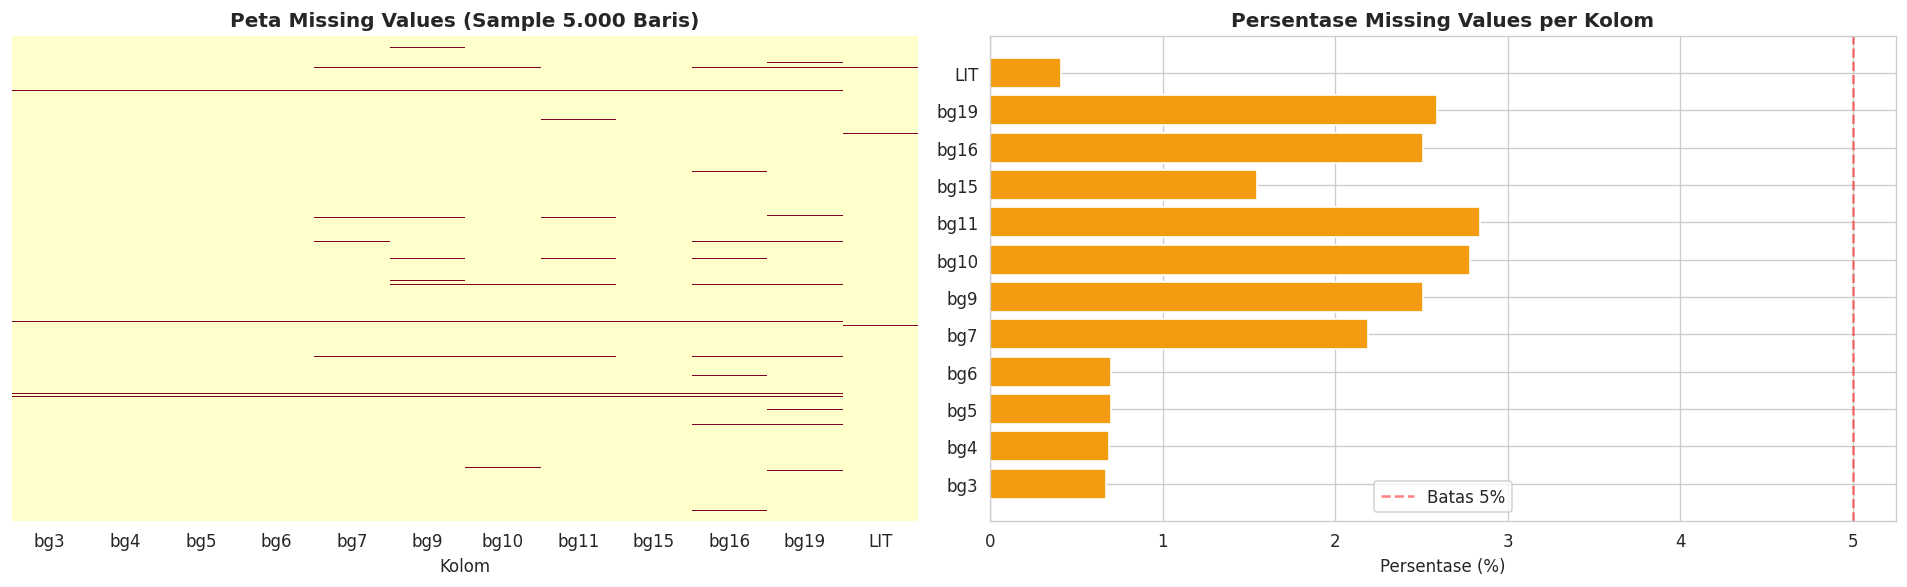

Total baris dengan minimal 1 missing: 30,541


In [12]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
df_missing  = pd.DataFrame({'Jumlah': missing, 'Persen (%)': missing_pct})
df_missing_vis = df_missing[df_missing['Jumlah'] > 0].sort_values('Jumlah', ascending=False)

print(f"Total baris : {len(df):,}")
print("Missing values per kolom:")
if len(df_missing_vis) == 0:
    print("  ✅ Tidak ada missing values!")
else:
    print(df_missing_vis)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample_miss = df.sample(min(5000, len(df)), random_state=42)
sns.heatmap(sample_miss.isnull(), yticklabels=False, cbar=False,
            cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Peta Missing Values (Sample 5.000 Baris)', fontweight='bold')
axes[0].set_xlabel('Kolom')

axes[1].barh(df_missing.index, df_missing['Persen (%)'],
             color=['#e74c3c' if p > 5 else '#f39c12' if p > 0 else '#27ae60'
                    for p in df_missing['Persen (%)']])
axes[1].axvline(5, color='red', linestyle='--', alpha=0.5, label='Batas 5%')
axes[1].set_title('Persentase Missing Values per Kolom', fontweight='bold')
axes[1].set_xlabel('Persentase (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Total baris dengan minimal 1 missing: {df.isnull().any(axis=1).sum():,}")

**Interpretasi:** Ditemukan missing values pada semua kolom, namun persentasenya tergolong kecil (di bawah 5% untuk semua kolom). Kolom dengan missing terbanyak adalah `bg11` (Laptop/Komputer) sebesar 2,84% dan `bg10` (Listrik Malam) sebesar 2,78%. Total terdapat **30.541 baris** (5,80%) yang memiliki setidaknya satu nilai kosong. Karena dataset sangat besar (>526 ribu baris), penghapusan baris ber-missing tidak akan signifikan mempengaruhi representativitas data.

### Sel 4.4 — Distribusi skor literasi (variabel target)

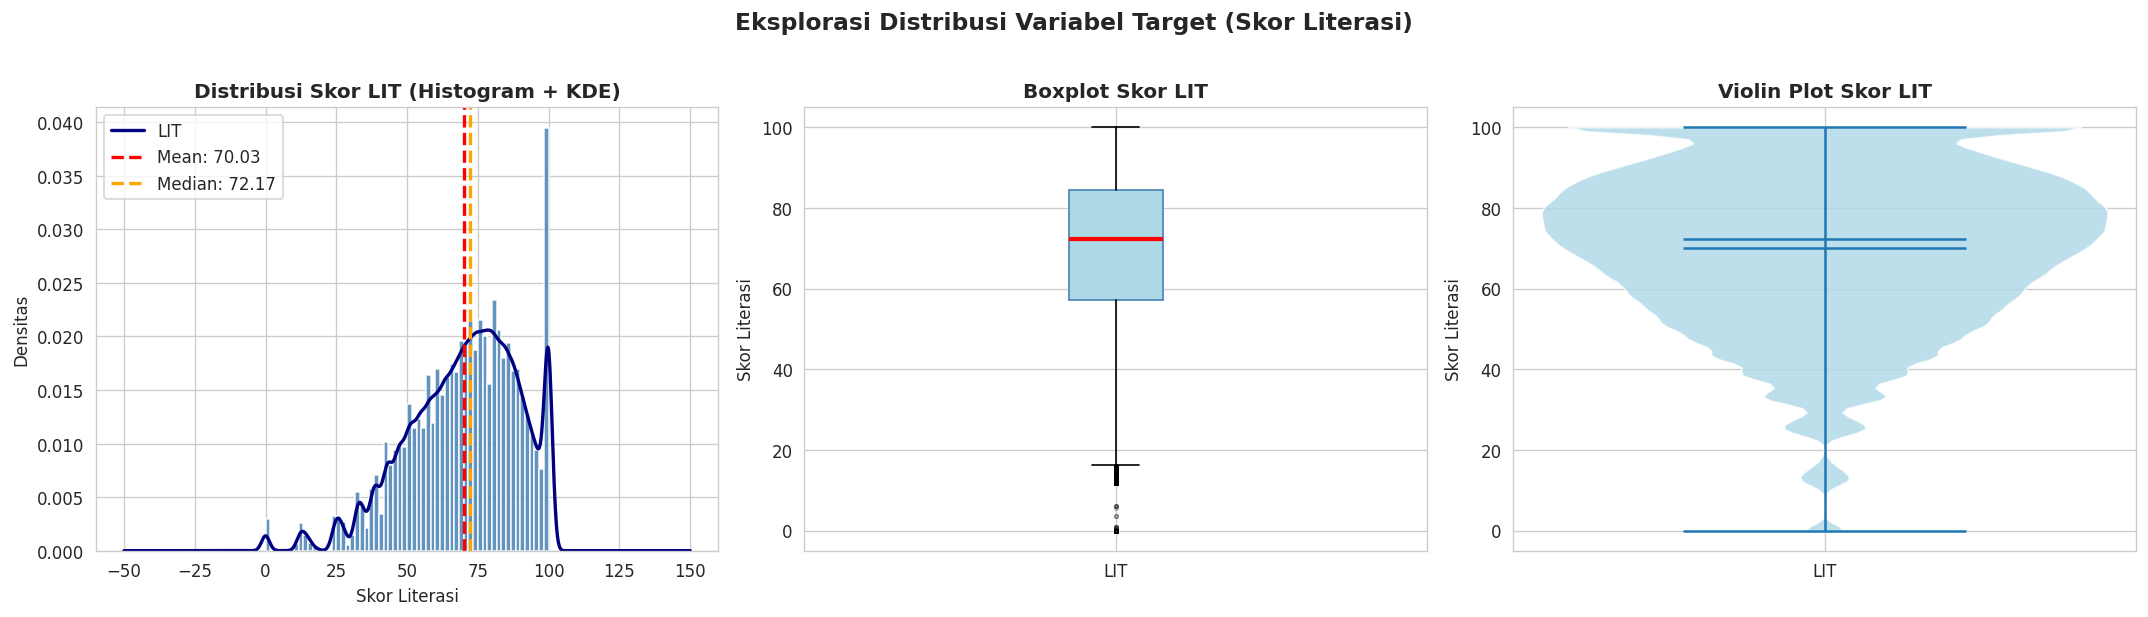

Statistik Skor LIT:
  count   : 524253.0000
  mean    : 70.0305
  std     : 19.5066
  min     : 0.0000
  25%     : 57.1621
  50%     : 72.1651
  75%     : 84.5009
  max     : 100.0000
  skewness: -0.6229  (miring kiri)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['LIT'].dropna(), bins=60, color='steelblue',
             edgecolor='white', alpha=0.85, density=True)
df['LIT'].dropna().plot.kde(ax=axes[0], color='navy', linewidth=2)
axes[0].axvline(df['LIT'].mean(),   color='red',    linestyle='--', lw=2,
                label=f"Mean: {df['LIT'].mean():.2f}")
axes[0].axvline(df['LIT'].median(), color='orange', linestyle='--', lw=2,
                label=f"Median: {df['LIT'].median():.2f}")
axes[0].set_title('Distribusi Skor LIT (Histogram + KDE)', fontweight='bold')
axes[0].set_xlabel('Skor Literasi')
axes[0].set_ylabel('Densitas')
axes[0].legend()

bp = axes[1].boxplot(df['LIT'].dropna(), patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='steelblue'),
                     medianprops=dict(color='red', linewidth=2.5),
                     flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=2))
axes[1].set_title('Boxplot Skor LIT', fontweight='bold')
axes[1].set_ylabel('Skor Literasi')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['LIT'])

parts = axes[2].violinplot(df['LIT'].dropna(), showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.8)
axes[2].set_title('Violin Plot Skor LIT', fontweight='bold')
axes[2].set_ylabel('Skor Literasi')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['LIT'])

plt.suptitle('Eksplorasi Distribusi Variabel Target (Skor Literasi)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_LIT.png', dpi=120, bbox_inches='tight')
plt.show()

print("Statistik Skor LIT:")
for stat, val in df['LIT'].describe().items():
    print(f"  {stat:8s}: {val:.4f}")
skew = df['LIT'].skew()
print(f"  {'skewness':8s}: {skew:.4f}  {'(miring kiri)' if skew < -0.5 else '(miring kanan)' if skew > 0.5 else '(mendekati simetris)'}")

**Interpretasi:** Skor LIT siswa SMP memiliki distribusi yang **miring ke kiri (left-skewed, skewness = -0,62)**, artinya sebagian besar siswa sebenarnya memiliki skor yang relatif tinggi (di atas 70), namun ada kelompok kecil siswa dengan skor sangat rendah yang menarik distribusi ke bawah. Boxplot menunjukkan median (72,17) sedikit lebih tinggi dari mean (70,03), konsisten dengan distribusi miring kiri. Nilai min = 0 dan max = 100 menunjukkan variasi yang sangat lebar antar siswa, mengindikasikan ketimpangan literasi yang signifikan di tingkat nasional.

### Sel 4.5 — Distribusi variabel sosial ekonomi (bg3–bg6)

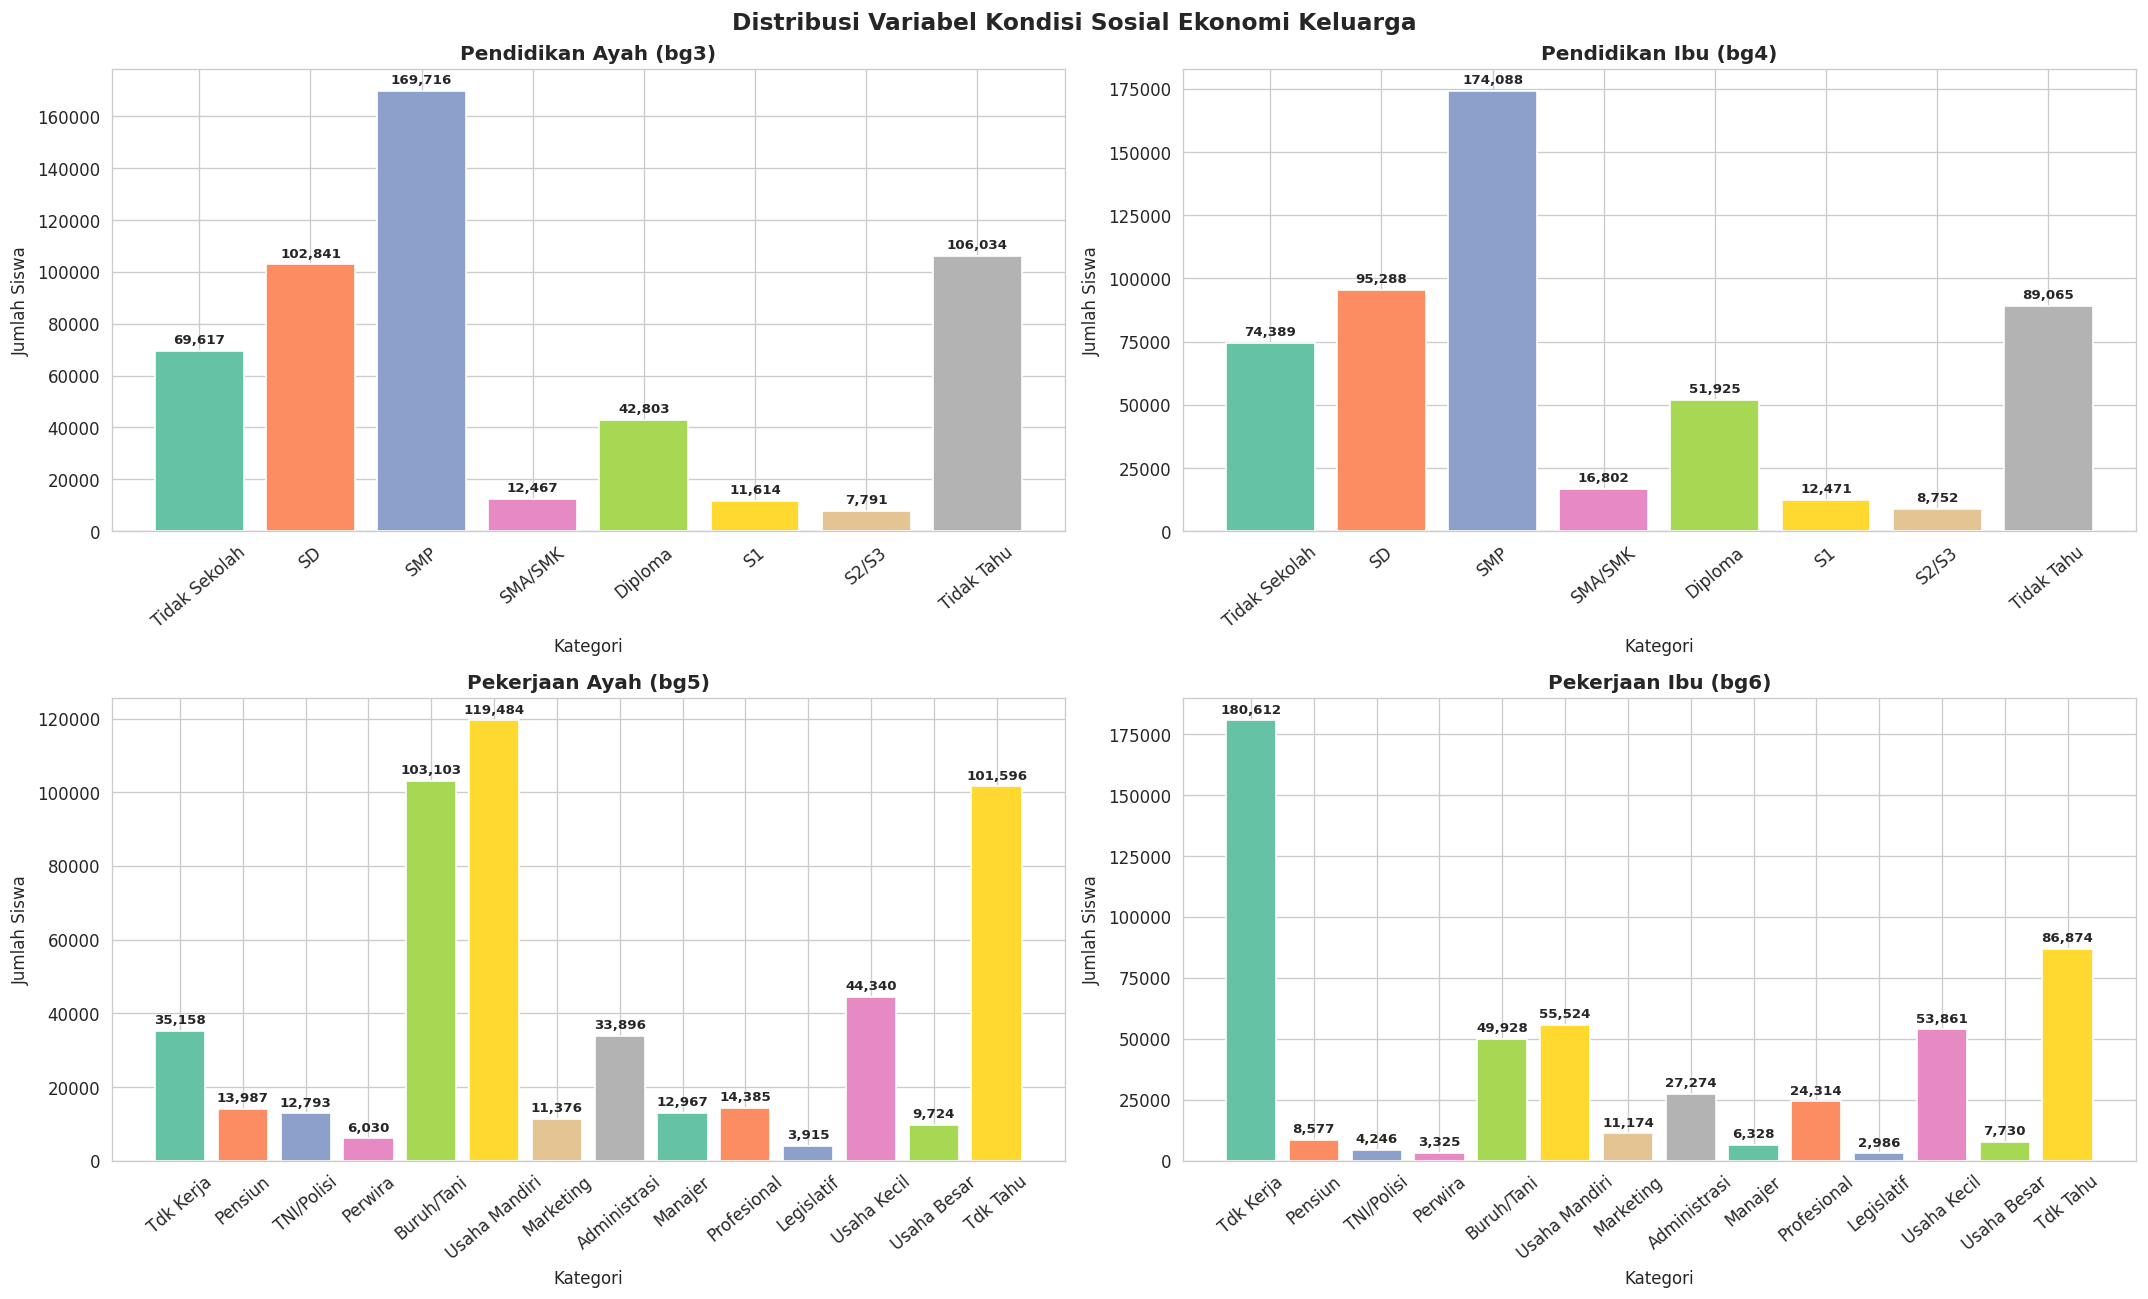

In [14]:
label_pend = {
    'A1':'Tidak Sekolah','B1':'SD','C1':'SMP','D1':'SMA/SMK',
    'E1':'Diploma','F1':'S1','G1':'S2/S3','H1':'Tidak Tahu'
}
label_kerja_singkat = {
    'A1':'Tdk Kerja','B1':'Pensiun','C1':'TNI/Polisi','D1':'Perwira',
    'E1':'Buruh/Tani','F1':'Usaha Mandiri','G1':'Marketing',
    'H1':'Administrasi','I1':'Manajer','J1':'Profesional',
    'K1':'Legislatif','L1':'Usaha Kecil','M1':'Usaha Besar','N1':'Tdk Tahu'
}
label_maps = {'bg3':label_pend,'bg4':label_pend,
              'bg5':label_kerja_singkat,'bg6':label_kerja_singkat}
judul_maps = {'bg3':'Pendidikan Ayah (bg3)','bg4':'Pendidikan Ibu (bg4)',
              'bg5':'Pekerjaan Ayah (bg5)','bg6':'Pekerjaan Ibu (bg6)'}

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(['bg3','bg4','bg5','bg6']):
    vc = df[col].value_counts().sort_index()
    labels = [label_maps[col].get(k, k) for k in vc.index]
    colors = sns.color_palette('Set2', len(vc))
    bars = axes[i].bar(labels, vc.values, color=colors, edgecolor='white')
    axes[i].set_title(judul_maps[col], fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Kategori')
    axes[i].set_ylabel('Jumlah Siswa')
    axes[i].tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vc.values)*0.01,
                     f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Distribusi Variabel Kondisi Sosial Ekonomi Keluarga',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_sosek.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi**: Distribusi variabel sosial ekonomi mengungkap profil keluarga siswa SMP di Indonesia secara nasional. Untuk **pendidikan orang tua (bg3 & bg4)**, **kategori SMP mendominasi, diikuti oleh SD dan kategori tidak diketahui (tidak tahu)**. Temuan ini menunjukkan bahwa mayoritas orang tua siswa memiliki tingkat pendidikan menengah pertama, sementara proporsi yang menempuh pendidikan tinggi relatif lebih kecil. Untuk **pekerjaan orang tua (bg5 & bg6)**, kategori **Usaha Mandiri mendominasi pada pekerjaan ayah**, sedangkan pada **pekerjaan ibu kategori Tidak Bekerja** memiliki proporsi tertinggi. Kondisi ini menunjukkan bahwa sebagian besar siswa berasal dari keluarga dengan latar belakang sosial ekonomi menengah ke bawah. Variasi pada pekerjaan ibu (bg6) menjadi variabel yang menarik karena berpotensi berkaitan dengan intensitas pendampingan belajar serta pembentukan lingkungan literasi di rumah yang dapat memengaruhi capaian literasi siswa.

### Sel 4.6 — Distribusi variabel fasilitas belajar (bg7–bg11)

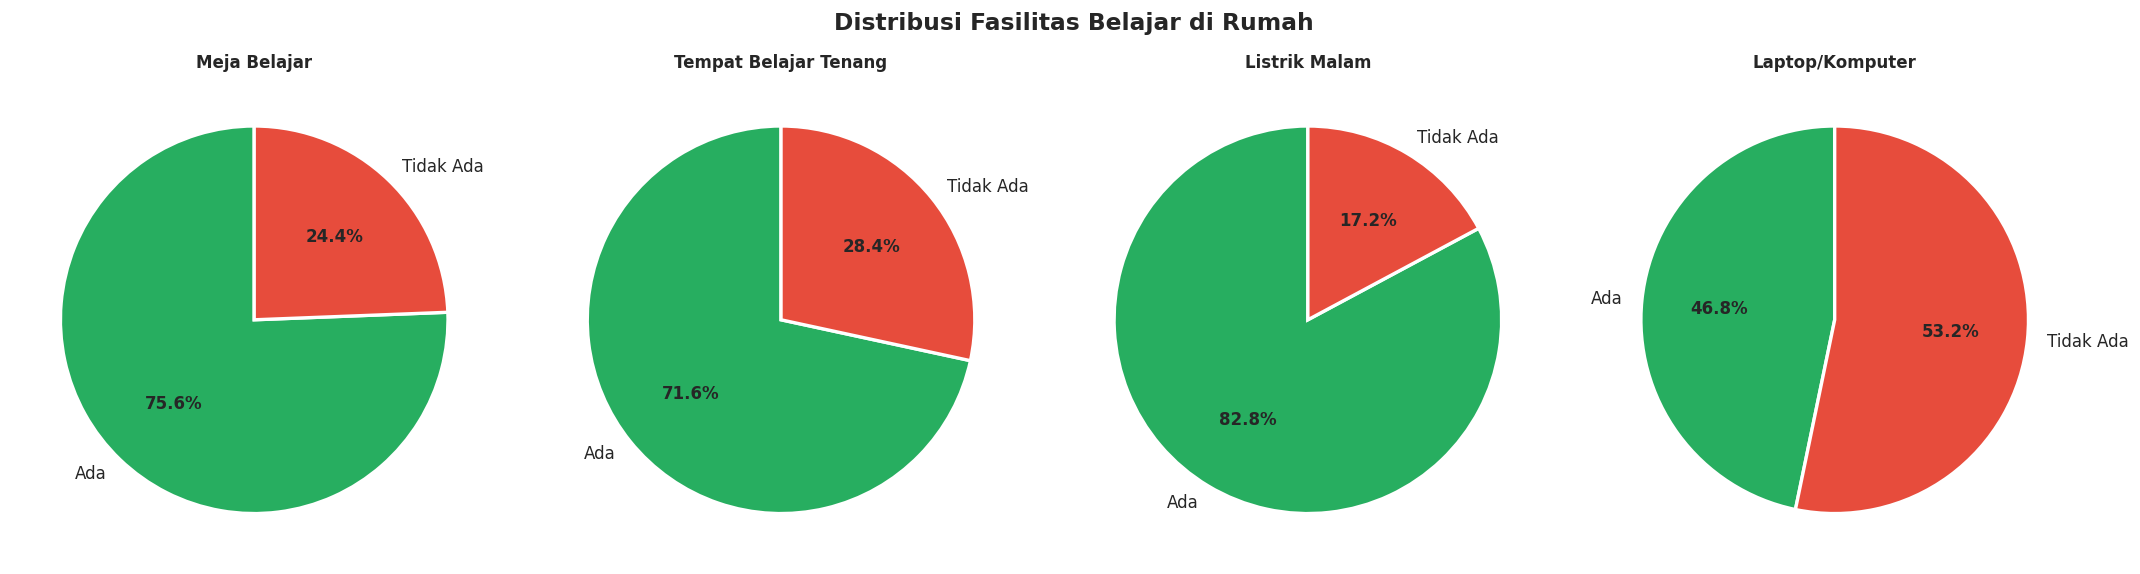

In [15]:
label_ada = {'A1':'Tidak Ada','A2':'Tidak Ada','A3':'Tidak Ada','A4':'Tidak Ada',
             'A5':'Tidak Ada','A7':'Tidak Ada',
             'B1':'Ada','B2':'Ada','B3':'Ada','B4':'Ada','B5':'Ada','B7':'Ada'}
judul_fas = {
    'bg7' :'Meja Belajar',
    'bg9' :'Tempat Belajar Tenang',
    'bg10':'Listrik Malam',
    'bg11':'Laptop/Komputer'
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(['bg7','bg9','bg10','bg11']):
    vc = df[col].value_counts()
    labels_show = [label_ada.get(k, k) for k in vc.index]
    ada   = sum(v for k,v in zip(labels_show, vc.values) if k == 'Ada')
    tidak = sum(v for k,v in zip(labels_show, vc.values) if k != 'Ada')
    wedges, texts, autotexts = axes[i].pie(
        [ada, tidak], labels=['Ada','Tidak Ada'], autopct='%1.1f%%',
        colors=['#27ae60','#e74c3c'], startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_fontweight('bold')
    axes[i].set_title(judul_fas[col], fontweight='bold', fontsize=10)

plt.suptitle('Distribusi Fasilitas Belajar di Rumah', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_fasilitas.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi:** Fasilitas belajar dasar seperti **listrik malam (bg10)**, **meja belajar (bg7)**, **tempat belajar tenang (bg9)** dimiliki oleh mayoritas siswa. Namun **Laptop/Komputer (bg11)** menunjukkan kesenjangan yang lebih besar — artinya akses terhadap perangkat teknologi masih belum merata. Kesenjangan kepemilikan laptop ini relevan dengan kemampuan literasi digital, dan diharapkan memberikan kontribusi yang dapat diidentifikasi oleh model klasifikasi.

### Sel 4.7 — Distribusi variabel lingkungan literasi rumah (bg15, bg16, bg19)

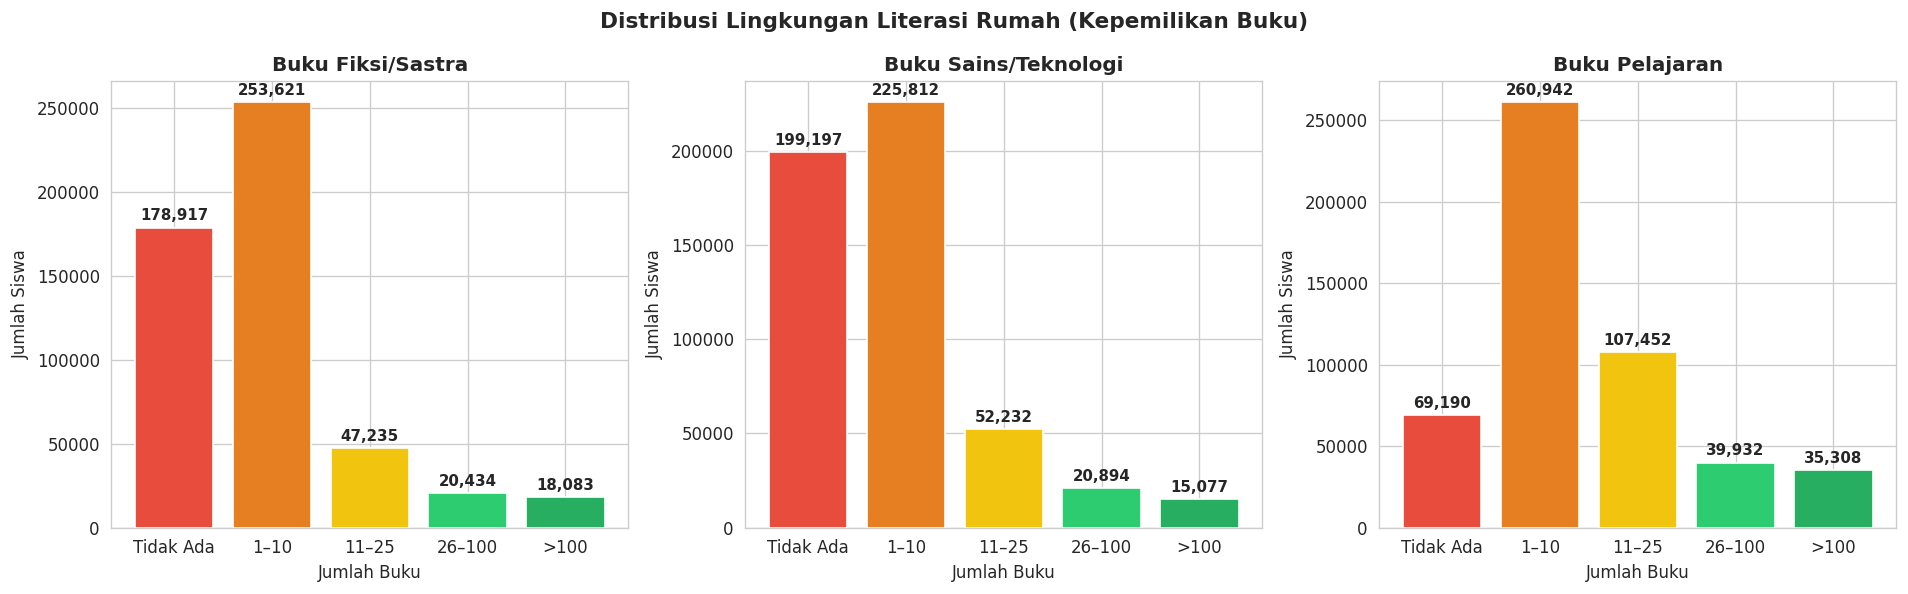

In [17]:
label_buku = {
    'A1':'Tidak Ada','A2':'Tidak Ada','A5':'Tidak Ada',
    'B1':'1–10','B2':'1–10','B5':'1–10',
    'C1':'11–25','C2':'11–25','C5':'11–25',
    'D1':'26–100','D2':'26–100','D5':'26–100',
    'E1':'>100','E2':'>100','E5':'>100'
}
order_buku  = ['Tidak Ada','1–10','11–25','26–100','>100']
judul_buku  = {'bg15':'Buku Fiksi/Sastra','bg16':'Buku Sains/Teknologi','bg19':'Buku Pelajaran'}
colors_buku = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['bg15','bg16','bg19']):
    mapped = df[col].map(lambda x: label_buku.get(x, 'Lainnya'))
    vc_mapped = mapped.value_counts()
    labels_ord = [l for l in order_buku if l in vc_mapped.index]
    vals_ord   = [vc_mapped.get(l, 0) for l in labels_ord]
    bars = axes[i].bar(labels_ord, vals_ord, color=colors_buku[:len(labels_ord)], edgecolor='white')
    axes[i].set_title(judul_buku[col], fontweight='bold')
    axes[i].set_xlabel('Jumlah Buku')
    axes[i].set_ylabel('Jumlah Siswa')
    for bar, val in zip(bars, vals_ord):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals_ord)*0.01,
                     f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Lingkungan Literasi Rumah (Kepemilikan Buku)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_literasi_rumah.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi:** Kepemilikan buku di rumah sangat berkaitan langsung dengan budaya literasi keluarga. Buku Pelajaran (bg19) paling banyak dimiliki — wajar karena berkaitan dengan kewajiban sekolah. Sebaliknya, Buku Fiksi (bg15) dan Buku Sains (bg16) lebih mencerminkan motivasi membaca sukarela. Banyaknya keluarga yang berada di kategori "Tidak Ada" atau "1–10 buku" untuk buku fiksi dan sains mengindikasikan bahwa budaya membaca di luar konteks sekolah masih rendah di sebagian besar keluarga Indonesia.

### Sel 4.8 — Rata-rata skor LIT berdasarkan setiap variabel prediktor

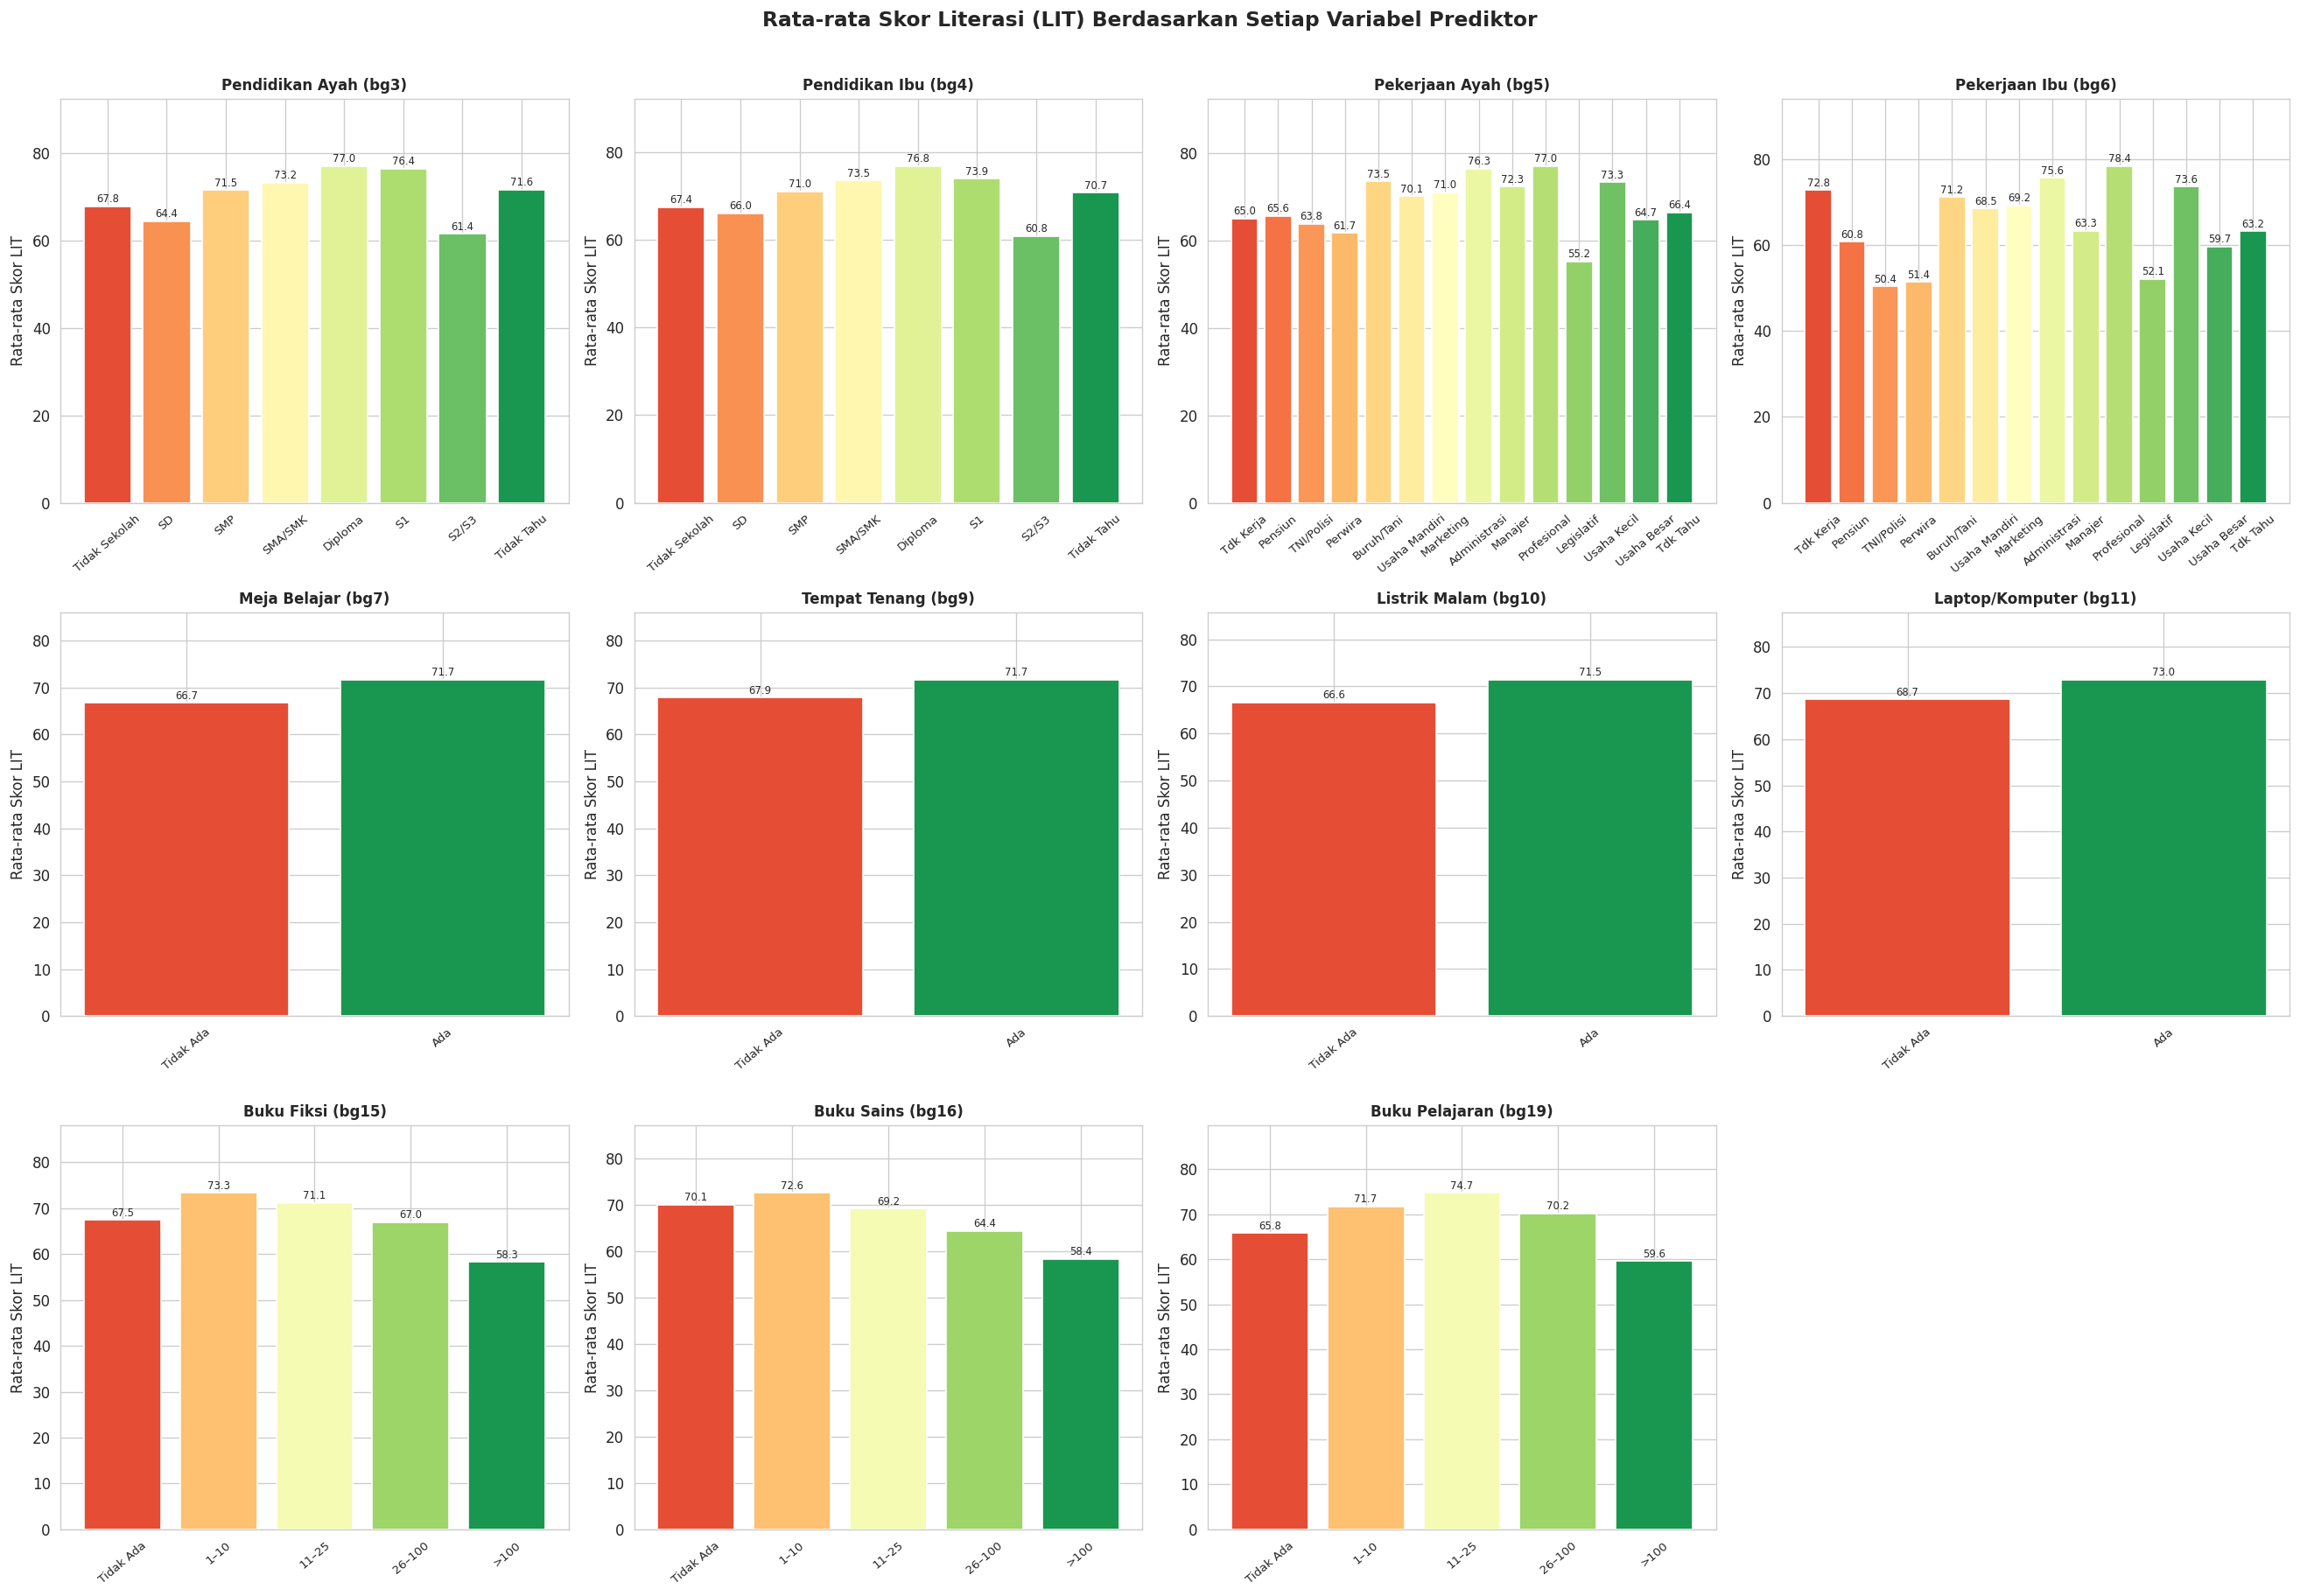

In [18]:
label_maps_full = {
    'bg3': label_pend, 'bg4': label_pend,
    'bg5': label_kerja_singkat, 'bg6': label_kerja_singkat,
    'bg7': label_ada, 'bg9': label_ada, 'bg10': label_ada,
    'bg11': label_ada,
    'bg15': label_buku, 'bg16': label_buku, 'bg19': label_buku
}

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.flatten()

for i, col in enumerate(SEMUA_FITUR):
    grp = df.groupby(col)['LIT'].mean().reset_index()
    grp['label'] = grp[col].map(lambda x: label_maps_full[col].get(x, str(x)))
    grp = grp.dropna(subset=['LIT'])
    n_bars = len(grp)
    palette = plt.cm.RdYlGn(np.linspace(0.15, 0.9, n_bars))
    bars = axes[i].bar(grp['label'], grp['LIT'], color=palette, edgecolor='white')
    axes[i].set_title(f'{NAMA_TAMPIL[col]} ({col})', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Rata-rata Skor LIT')
    axes[i].set_ylim(0, grp['LIT'].max() * 1.2)
    axes[i].tick_params(axis='x', rotation=40, labelsize=8)
    for bar, val in zip(bars, grp['LIT']):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=7)

for j in range(len(SEMUA_FITUR), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Rata-rata Skor Literasi (LIT) Berdasarkan Setiap Variabel Prediktor',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lit_per_variabel.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi:** Grafik ini adalah **justifikasi empiris** pemilihan variabel prediktor. Beberapa pola penting yang terlihat:
- **Pendidikan orang tua (bg3, bg4):** Terlihat gradien yang jelas — semakin tinggi pendidikan orang tua, semakin tinggi rata-rata skor LIT anak.
- **Pekerjaan orang tua (bg5, bg6):** Orang tua yang bekerja sebagai profesional atau manajer cenderung memiliki anak dengan skor LIT lebih tinggi.
- **Kepemilikan buku (bg15, bg16, bg19):** Tren positif yang konsisten — semakin banyak buku, semakin tinggi rata-rata skor LIT.
- **Laptop/Komputer (bg11):** Siswa dengan laptop di rumah memiliki rata-rata LIT lebih tinggi.

Semua 11 variabel menunjukkan pola yang bermakna, memvalidasi relevansi pemilihannya sebagai prediktor.

---
# BAGIAN 5 — PREPROCESSING DATA

### Sel 5.1 — Menghapus baris dengan missing values

In [19]:
n_sebelum = len(df)
df_clean  = df.dropna().reset_index(drop=True)
n_sesudah = len(df_clean)
n_hapus   = n_sebelum - n_sesudah

print("HASIL DATA CLEANING")
print("=" * 45)
print(f"  Baris sebelum cleaning : {n_sebelum:,}")
print(f"  Baris setelah cleaning : {n_sesudah:,}")
print(f"  Baris dihapus          : {n_hapus:,} ({n_hapus/n_sebelum*100:.2f}%)")
print(f"  Data tersisa           : {n_sesudah/n_sebelum*100:.2f}%")
print()
print("✅ Data cleaning selesai.")

HASIL DATA CLEANING
  Baris sebelum cleaning : 526,433
  Baris setelah cleaning : 495,892
  Baris dihapus          : 30,541 (5.80%)
  Data tersisa           : 94.20%

✅ Data cleaning selesai.


**Interpretasi:** Sebanyak **30.541 baris (5,80%)** dihapus karena memiliki nilai kosong di setidaknya satu kolom. Dataset tersisa **495.892 baris** — masih sangat besar dan representatif secara nasional. Strategi *listwise deletion* dipilih karena proporsi missing sangat kecil dan jumlah data yang tersisa tetap sangat besar, sehingga tidak menimbulkan bias yang berarti.

### Sel 5.2 — Label Encoding variabel kategorikal

In [20]:
df_encoded = df_clean.copy()
encoders   = {}

for col in SEMUA_FITUR:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col]   = le

print("✅ Label Encoding selesai untuk semua variabel prediktor.")
print()
print("Contoh hasil encoding:")
for col in ['bg3', 'bg5', 'bg11']:
    mapping = dict(zip(encoders[col].classes_,
                       encoders[col].transform(encoders[col].classes_)))
    print(f"  {col} ({NAMA_TAMPIL[col]}): {mapping}")
print()
print("Preview data setelah encoding (5 baris):")
df_encoded[SEMUA_FITUR].head()

✅ Label Encoding selesai untuk semua variabel prediktor.

Contoh hasil encoding:
  bg3 (Pendidikan Ayah): {'A1': np.int64(0), 'B1': np.int64(1), 'C1': np.int64(2), 'D1': np.int64(3), 'E1': np.int64(4), 'F1': np.int64(5), 'G1': np.int64(6), 'H1': np.int64(7)}
  bg5 (Pekerjaan Ayah): {'A1': np.int64(0), 'B1': np.int64(1), 'C1': np.int64(2), 'D1': np.int64(3), 'E1': np.int64(4), 'F1': np.int64(5), 'G1': np.int64(6), 'H1': np.int64(7), 'I1': np.int64(8), 'J1': np.int64(9), 'K1': np.int64(10), 'L1': np.int64(11), 'M1': np.int64(12), 'N1': np.int64(13)}
  bg11 (Laptop/Komputer): {'A5': np.int64(0), 'B5': np.int64(1)}

Preview data setelah encoding (5 baris):


,bg3,bg4,bg5,bg6,bg7,bg9,bg10,bg11,bg15,bg16,bg19
0,2,2,4,0,1,1,1,1,1,0,1
1,2,2,13,12,0,1,0,1,1,0,2
2,5,4,9,0,1,1,1,1,1,1,1
3,2,2,13,0,1,1,1,0,2,1,2
4,2,2,4,4,1,1,1,1,1,0,2


**Interpretasi:** Label Encoding berhasil mengubah semua variabel kategorikal (kode seperti 'A1', 'B1') menjadi bilangan bulat. Contoh: `bg3` (Pendidikan Ayah) dikodekan dari 'A1'=0 (Tidak Sekolah) hingga 'H1'=7 (Tidak Tahu), dan `bg11` (Laptop/Komputer) menjadi 0 (Tidak Ada) dan 1 (Ada). Encoding ini diperlukan karena algoritma Decision Tree dan Random Forest hanya dapat memproses data numerik.

### Sel 5.3 — Membuat variabel target (3 kelas literasi)

In [21]:
df_encoded['LIT_KELAS'], bins = pd.qcut(
    df_encoded['LIT'], q=3, labels=[0, 1, 2], retbins=True
)
df_encoded['LIT_KELAS'] = df_encoded['LIT_KELAS'].astype(int)

print("✅ Variabel target berhasil dibuat.")
print()
print(f"Batas kelas (berdasarkan quantile skor LIT):")
print(f"  Kelas 0 (Rendah) : skor  < {bins[1]:.2f}")
print(f"  Kelas 1 (Sedang) : {bins[1]:.2f} ≤ skor < {bins[2]:.2f}")
print(f"  Kelas 2 (Tinggi) : skor ≥ {bins[2]:.2f}")
print()
print("Distribusi kelas:")
vc_kelas = df_encoded['LIT_KELAS'].value_counts().sort_index()
for k, v in vc_kelas.items():
    bar = '█' * int(v / vc_kelas.max() * 30)
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): {v:,} siswa ({v/len(df_encoded)*100:.1f}%)  {bar}")

✅ Variabel target berhasil dibuat.

Batas kelas (berdasarkan quantile skor LIT):
  Kelas 0 (Rendah) : skor  < 63.83
  Kelas 1 (Sedang) : 63.83 ≤ skor < 80.83
  Kelas 2 (Tinggi) : skor ≥ 80.83

Distribusi kelas:
  Kelas 0 (Rendah): 165,335 siswa (33.3%)  █████████████████████████████
  Kelas 1 (Sedang): 165,882 siswa (33.5%)  ██████████████████████████████
  Kelas 2 (Tinggi): 164,675 siswa (33.2%)  █████████████████████████████


**Interpretasi:** Metode `pd.qcut()` berhasil membagi skor LIT menjadi 3 kelas yang **seimbang** menggunakan batas kuantil:
- **Rendah (K0):** skor < 63,83 → 165.335 siswa (33,3%)
- **Sedang (K1):** 63,83 ≤ skor < 80,83 → 165.882 siswa (33,5%)
- **Tinggi (K2):** skor ≥ 80,83 → 164.675 siswa (33,2%)

Distribusi yang seimbang ini sangat penting agar model tidak bias ke kelas mayoritas. Batas skor 63,83 dan 80,83 menjadi threshold klasifikasi yang objektif berbasis data.

### Sel 5.4 — Visualisasi distribusi kelas target

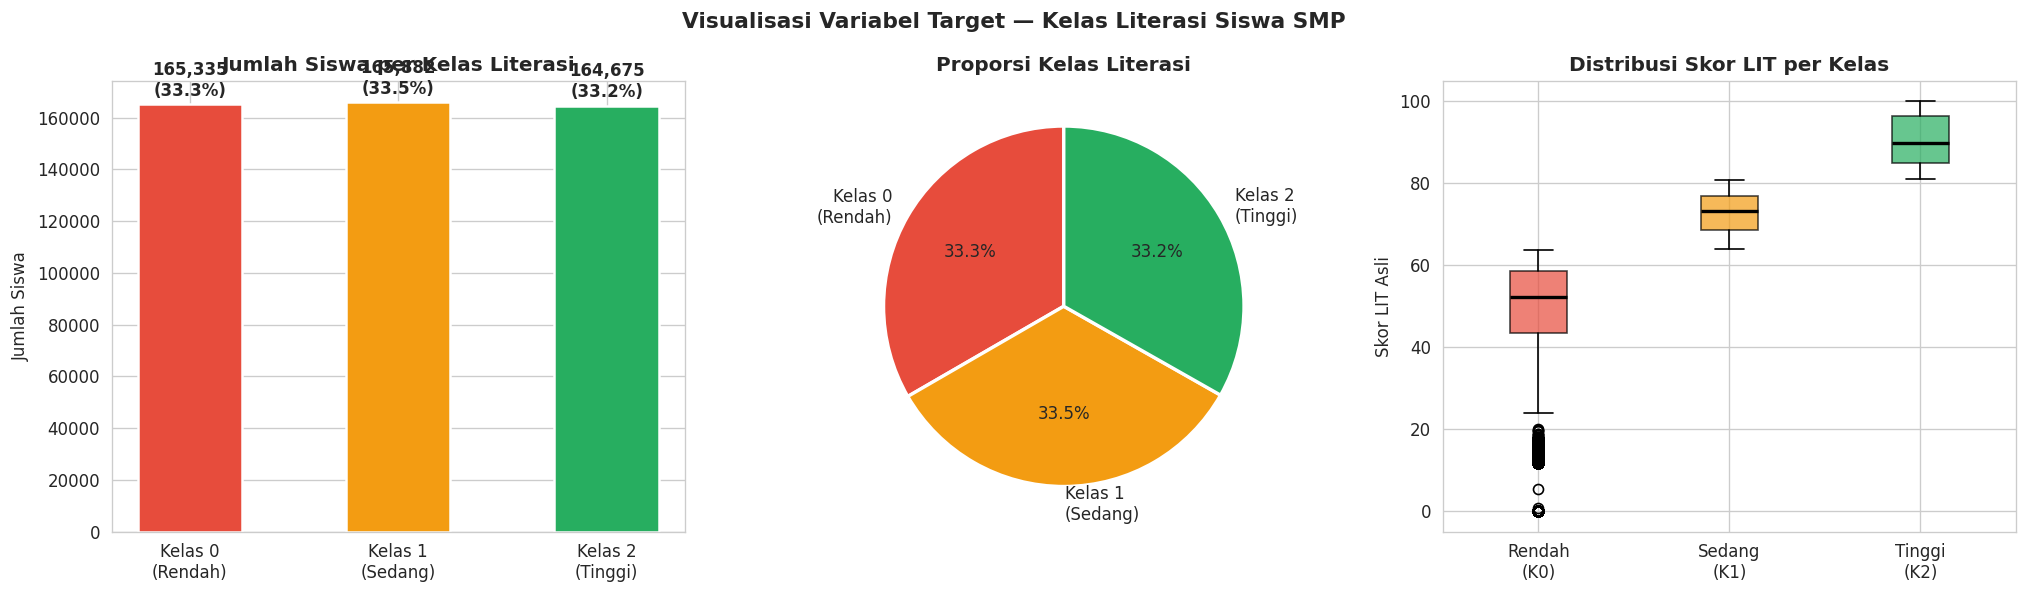

✅ Distribusi kelas seimbang — pd.qcut berhasil membagi data secara proporsional.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

vc = df_encoded['LIT_KELAS'].value_counts().sort_index()
labels_kelas = [f"Kelas {k}\n({NAMA_KELAS[k]})" for k in vc.index]
warna_list   = [WARNA_KELAS[k] for k in vc.index]

bars = axes[0].bar(labels_kelas, vc.values, color=warna_list,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Jumlah Siswa per Kelas Literasi', fontweight='bold')
axes[0].set_ylabel('Jumlah Siswa')
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vc.values)*0.01,
                 f'{val:,}\n({val/len(df_encoded)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')

axes[1].pie(vc.values, labels=labels_kelas, autopct='%1.1f%%',
            colors=warna_list, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kelas Literasi', fontweight='bold')

data_per_kelas = [df_encoded[df_encoded['LIT_KELAS']==k]['LIT'].values for k in [0,1,2]]
bp = axes[2].boxplot(data_per_kelas, patch_artist=True,
                     labels=["Rendah\n(K0)","Sedang\n(K1)","Tinggi\n(K2)"])
for patch, color in zip(bp['boxes'], warna_list):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
axes[2].set_title('Distribusi Skor LIT per Kelas', fontweight='bold')
axes[2].set_ylabel('Skor LIT Asli')

plt.suptitle('Visualisasi Variabel Target — Kelas Literasi Siswa SMP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_kelas.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Distribusi kelas seimbang — pd.qcut berhasil membagi data secara proporsional.")

### Sel 5.5 — Pembagian data training dan testing (80:20, Stratified)

In [23]:
X = df_encoded[SEMUA_FITUR]
y = df_encoded['LIT_KELAS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Pembagian data selesai.")
print()
print(f"  Total data    : {len(X):,} siswa")
print(f"  Training (80%): {len(X_train):,} siswa")
print(f"  Testing  (20%): {len(X_test):,} siswa")
print()
print("Distribusi kelas pada Training:")
for k, v in y_train.value_counts().sort_index().items():
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): {v:,} ({v/len(y_train)*100:.1f}%)")
print()
print("Distribusi kelas pada Testing:")
for k, v in y_test.value_counts().sort_index().items():
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): {v:,} ({v/len(y_test)*100:.1f}%)")
print()
print("✅ Parameter stratify=y memastikan proporsi kelas identik di training dan testing.")

✅ Pembagian data selesai.

  Total data    : 495,892 siswa
  Training (80%): 396,713 siswa
  Testing  (20%): 99,179 siswa

Distribusi kelas pada Training:
  Kelas 0 (Rendah): 132,268 (33.3%)
  Kelas 1 (Sedang): 132,705 (33.5%)
  Kelas 2 (Tinggi): 131,740 (33.2%)

Distribusi kelas pada Testing:
  Kelas 0 (Rendah): 33,067 (33.3%)
  Kelas 1 (Sedang): 33,177 (33.5%)
  Kelas 2 (Tinggi): 32,935 (33.2%)

✅ Parameter stratify=y memastikan proporsi kelas identik di training dan testing.


**Interpretasi:** Data berhasil dibagi menjadi **396.713 data training (80%)** dan **99.179 data testing (20%)**. Parameter `stratify=y` memastikan proporsi kelas tetap seimbang di kedua subset — training dan testing masing-masing memiliki distribusi ~33% per kelas, identik dengan distribusi keseluruhan. Ini mencegah bias evaluasi akibat distribusi kelas yang tidak representatif di data testing.

---

> ✅ **Preprocessing selesai!** Data siap digunakan untuk melatih model di Bagian 6 (Decision Tree) dan Bagian 7 (Random Forest).

---
# BAGIAN 6 — MODEL 1: DECISION TREE CLASSIFIER

## Konsep Dasar
Decision Tree adalah algoritma klasifikasi yang bekerja dengan cara membagi dataset secara rekursif berdasarkan **fitur terbaik** pada setiap node, menghasilkan struktur seperti pohon keputusan.

### Cara Kerja:
```
Dataset Awal
    └── Node 1: Pekerjaan Ibu ≤ 11.5?
         ├── Ya  → Node 2: Pendidikan Ayah ≤ 1.5?
         │          ├── Ya  → Node 3: Pekerjaan Ayah ≤ 3.5?
         │          │         ├── Ya  → Kelas: Rendah
         │          │         └── Tidak → Kelas: Sedang
         │          └── Tidak → Kelas: Sedang
         └── Tidak → Kelas: TINGGI ✅
```

### Kriteria Pemisahan — Gini Impurity:
- Mengukur ketidakmurnian sebuah node
- **Formula:** `Gini = 1 - Σ(pᵢ²)` di mana pᵢ = proporsi kelas ke-i
- Nilai 0 = node murni (satu kelas), mendekati 0.67 = node campur rata (3 kelas)

### Kelemahan Utama:
- Rentan **overfitting** jika pohon dibiarkan tumbuh tanpa batas — model "menghafal" data training bukan belajar pola

### Sel 6.1 — Baseline Decision Tree (tanpa batasan kedalaman)

In [24]:
dt_full = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_full.fit(X_train, y_train)

akurasi_full_train = accuracy_score(y_train, dt_full.predict(X_train))
akurasi_full_test  = accuracy_score(y_test,  dt_full.predict(X_test))

print("DECISION TREE — TANPA BATASAN (Baseline)")
print("=" * 48)
print(f"  Kedalaman pohon   : {dt_full.get_depth()}")
print(f"  Jumlah leaf nodes : {dt_full.get_n_leaves():,}")
print(f"  Akurasi Training  : {akurasi_full_train:.4f} ({akurasi_full_train*100:.2f}%)")
print(f"  Akurasi Testing   : {akurasi_full_test:.4f}  ({akurasi_full_test*100:.2f}%)")
print(f"  Gap Overfitting   : {(akurasi_full_train-akurasi_full_test)*100:.2f}%")
print()
print("⚠️  Pohon tanpa batasan = overfitting parah!")
print("   Model hafal training, tapi gagal generalisasi ke data baru.")

DECISION TREE — TANPA BATASAN (Baseline)
  Kedalaman pohon   : 38
  Jumlah leaf nodes : 113,973
  Akurasi Training  : 0.6840 (68.40%)
  Akurasi Testing   : 0.4172  (41.72%)
  Gap Overfitting   : 26.68%

⚠️  Pohon tanpa batasan = overfitting parah!
   Model hafal training, tapi gagal generalisasi ke data baru.


**Interpretasi:** Decision Tree tanpa batasan menghasilkan pohon sedalam **38 level** dengan **113.973 leaf nodes** — jauh terlalu kompleks. Akurasi training mencapai 68,40% namun testing hanya 41,72%, menghasilkan **gap overfitting sebesar 26,68%**. Ini adalah bukti nyata bahwa pohon yang terlalu dalam "menghafal" data training tetapi tidak mampu menggeneralisasi ke data baru. Pembatasan kedalaman (pruning) diperlukan.

### Sel 6.2 — Mencari kedalaman pohon optimal (Depth Tuning)

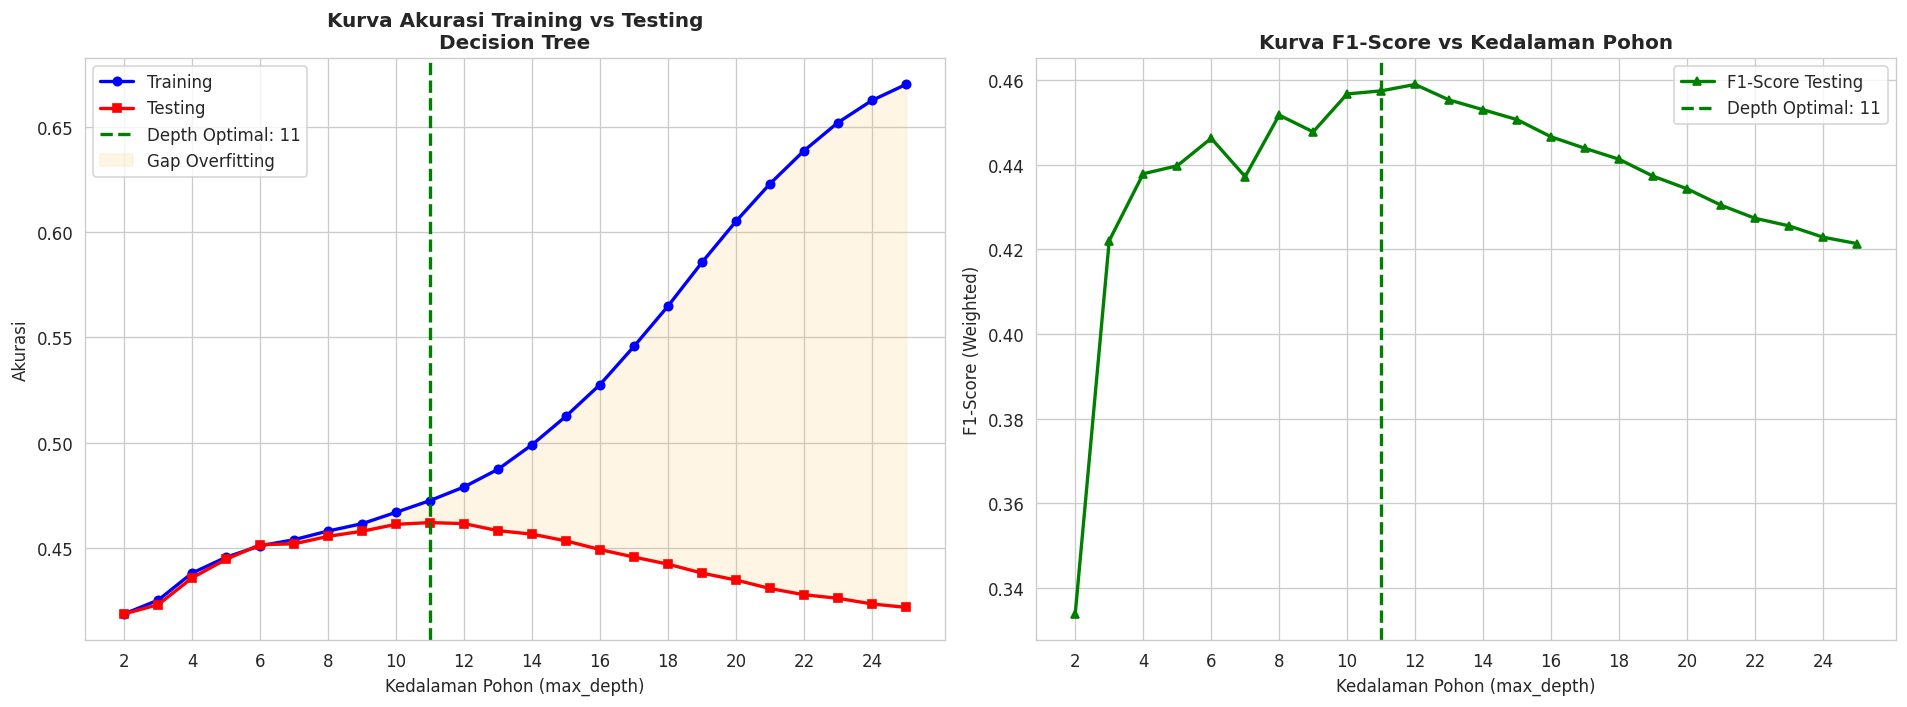

✅ Depth optimal ditemukan: max_depth = 11
   Akurasi testing terbaik : 46.20%
   F1-Score pada depth optimal: 45.75%


In [25]:
depth_range      = list(range(2, 26))
akurasi_train_dt = []
akurasi_test_dt  = []
f1_test_dt       = []

for depth in depth_range:
    dt_tmp = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt_tmp.fit(X_train, y_train)
    y_pred_tmp = dt_tmp.predict(X_test)
    akurasi_train_dt.append(accuracy_score(y_train, dt_tmp.predict(X_train)))
    akurasi_test_dt.append(accuracy_score(y_test, y_pred_tmp))
    f1_test_dt.append(f1_score(y_test, y_pred_tmp, average='weighted'))

depth_optimal_dt = depth_range[np.argmax(akurasi_test_dt)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(depth_range, akurasi_train_dt, 'b-o', label='Training', lw=2, ms=5)
axes[0].plot(depth_range, akurasi_test_dt,  'r-s', label='Testing',  lw=2, ms=5)
axes[0].axvline(depth_optimal_dt, color='green', ls='--', lw=2,
                label=f'Depth Optimal: {depth_optimal_dt}')
axes[0].fill_between(depth_range, akurasi_train_dt, akurasi_test_dt,
                     alpha=0.1, color='orange', label='Gap Overfitting')
axes[0].set_xlabel('Kedalaman Pohon (max_depth)')
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Kurva Akurasi Training vs Testing\nDecision Tree', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(depth_range[::2])

axes[1].plot(depth_range, f1_test_dt, 'g-^', lw=2, ms=5, label='F1-Score Testing')
axes[1].axvline(depth_optimal_dt, color='green', ls='--', lw=2,
                label=f'Depth Optimal: {depth_optimal_dt}')
axes[1].set_xlabel('Kedalaman Pohon (max_depth)')
axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].set_title('Kurva F1-Score vs Kedalaman Pohon', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(depth_range[::2])

plt.tight_layout()
plt.savefig('dt_depth_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"✅ Depth optimal ditemukan: max_depth = {depth_optimal_dt}")
print(f"   Akurasi testing terbaik : {max(akurasi_test_dt)*100:.2f}%")
print(f"   F1-Score pada depth optimal: {f1_test_dt[depth_range.index(depth_optimal_dt)]*100:.2f}%")

**Interpretasi:** Kurva depth tuning menunjukkan pola yang jelas: akurasi testing meningkat dari depth 2 hingga mencapai puncak di **max_depth = 11** dengan akurasi testing **46,20%** dan F1-Score **45,75%**. Setelah depth 11, akurasi testing mulai turun atau stagnan sementara akurasi training terus meningkat — inilah zona overfitting. Gap antara kurva training dan testing (area oranye) melebar setelah depth 11, memvalidasi bahwa depth 11 adalah titik optimal antara bias dan varians.

### Sel 6.3 — Melatih Decision Tree dengan parameter optimal

In [26]:
dt_model = DecisionTreeClassifier(
    criterion         = 'gini',
    max_depth         = depth_optimal_dt,
    min_samples_split = 20,
    min_samples_leaf  = 10,
    random_state      = 42
)
dt_model.fit(X_train, y_train)

y_pred_dt       = dt_model.predict(X_test)
y_pred_dt_train = dt_model.predict(X_train)

akurasi_dt_train = accuracy_score(y_train, y_pred_dt_train)
akurasi_dt       = accuracy_score(y_test,  y_pred_dt)
f1_dt            = f1_score(y_test, y_pred_dt, average='weighted')
precision_dt     = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt        = recall_score(y_test, y_pred_dt, average='weighted')

print("DECISION TREE — OPTIMAL")
print("=" * 48)
print(f"  max_depth         : {dt_model.max_depth}")
print(f"  min_samples_split : {dt_model.min_samples_split}")
print(f"  min_samples_leaf  : {dt_model.min_samples_leaf}")
print(f"  Kedalaman aktual  : {dt_model.get_depth()}")
print(f"  Jumlah leaf nodes : {dt_model.get_n_leaves():,}")
print()
print(f"  Akurasi Training  : {akurasi_dt_train:.4f} ({akurasi_dt_train*100:.2f}%)")
print(f"  Akurasi Testing   : {akurasi_dt:.4f}  ({akurasi_dt*100:.2f}%)")
print(f"  Gap Overfitting   : {(akurasi_dt_train-akurasi_dt)*100:.2f}%")
print(f"  Precision (w-avg) : {precision_dt:.4f}")
print(f"  Recall    (w-avg) : {recall_dt:.4f}")
print(f"  F1-Score  (w-avg) : {f1_dt:.4f}")
print()
print("✅ Model Decision Tree optimal berhasil dilatih.")

DECISION TREE — OPTIMAL
  max_depth         : 11
  min_samples_split : 20
  min_samples_leaf  : 10
  Kedalaman aktual  : 11
  Jumlah leaf nodes : 1,461

  Akurasi Training  : 0.4715 (47.15%)
  Akurasi Testing   : 0.4624  (46.24%)
  Gap Overfitting   : 0.91%
  Precision (w-avg) : 0.4593
  Recall    (w-avg) : 0.4624
  F1-Score  (w-avg) : 0.4579

✅ Model Decision Tree optimal berhasil dilatih.


**Interpretasi:** Dengan hyperparameter optimal (`max_depth=11`, `min_samples_split=20`, `min_samples_leaf=10`), pohon berhasil dipangkas menjadi **1.461 leaf nodes** (dari 113.973 sebelumnya). Gap overfitting turun drastis dari 26,68% menjadi hanya **0,91%** — model tidak lagi menghafal data. Akurasi testing mencapai **46,24%** dengan F1-Score 0,4579. Ini adalah performa Decision Tree terbaik yang dapat dicapai dengan 11 variabel prediktor yang berfokus pada faktor rumah tangga.

### Sel 6.4 — Visualisasi struktur pohon keputusan (3 level pertama)

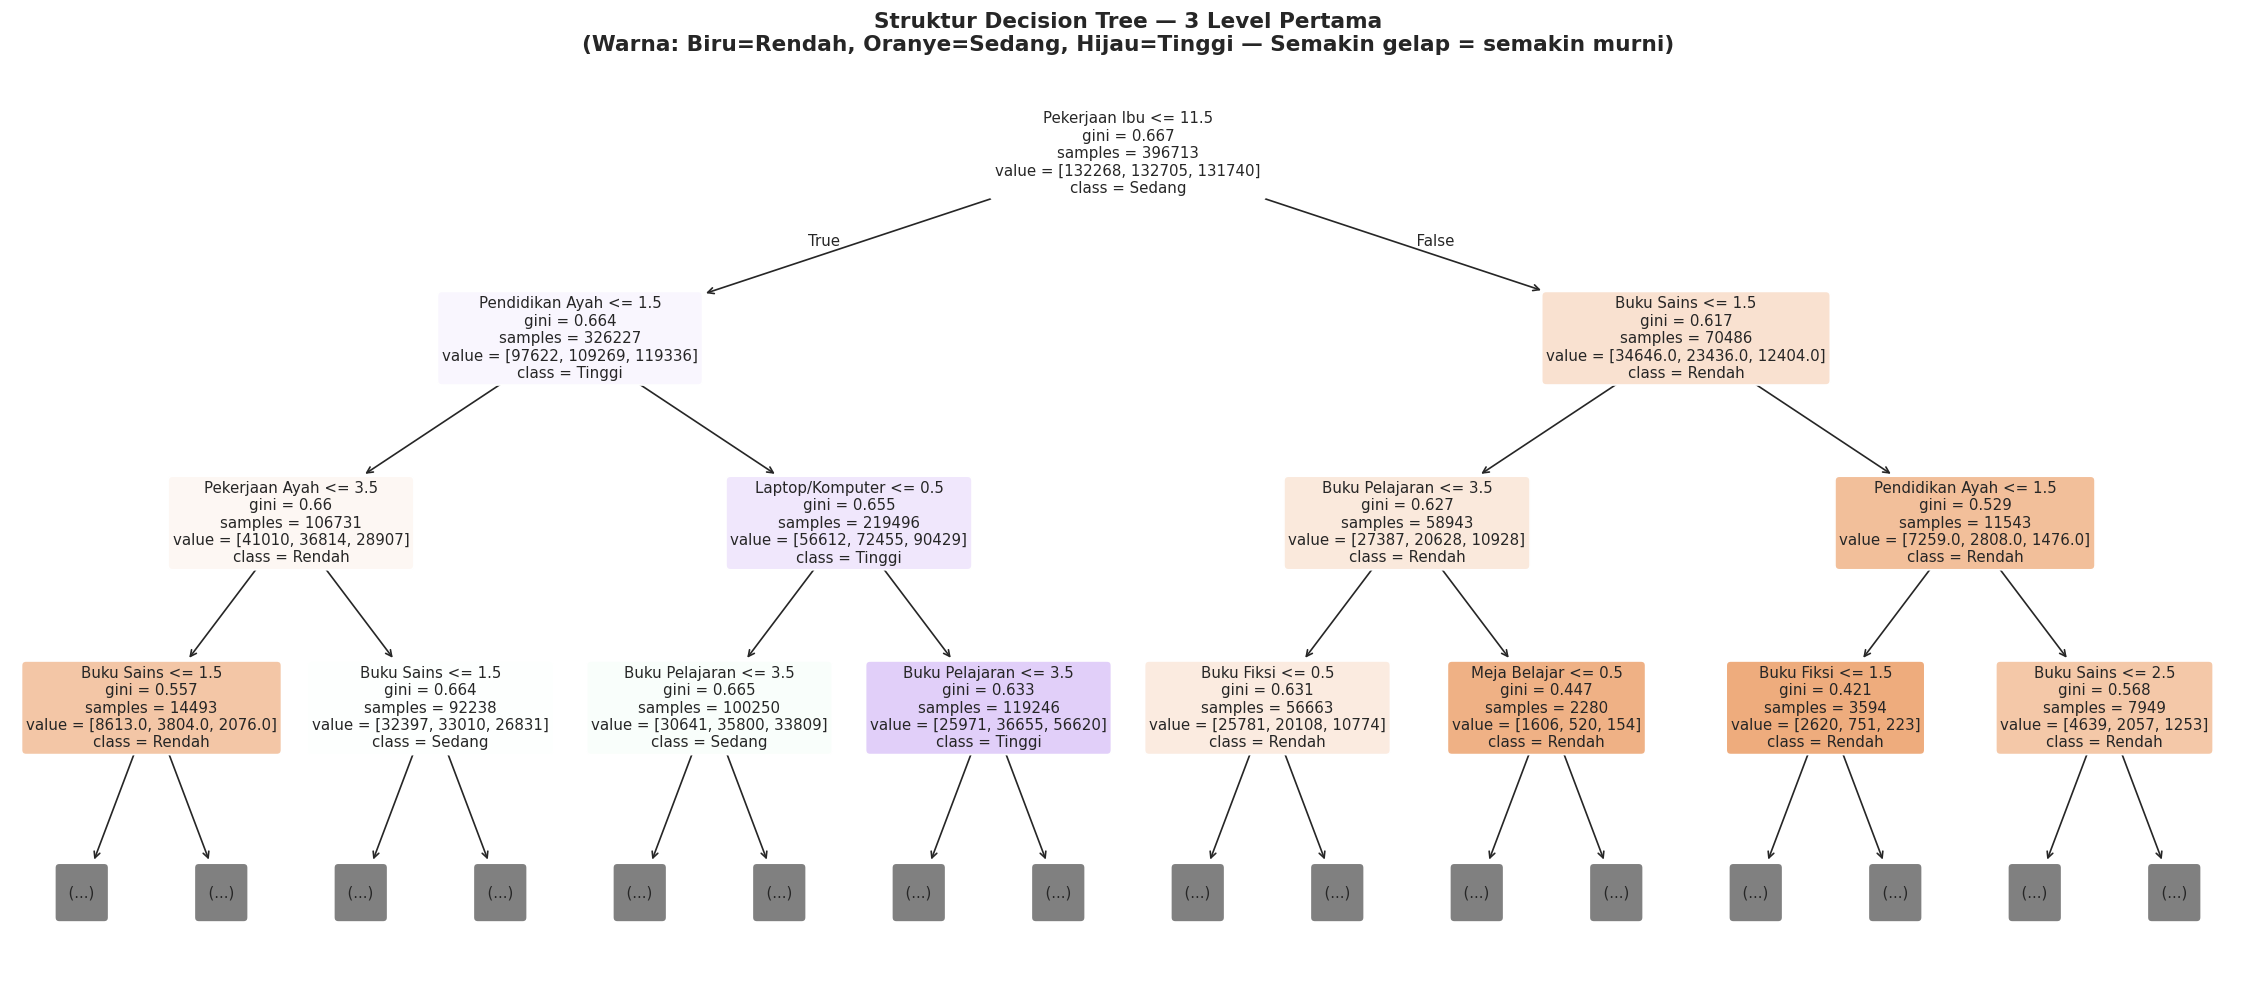

Setiap node menampilkan: fitur pemisah | nilai Gini | jumlah sampel | distribusi per kelas


In [27]:
feature_names_display = [NAMA_TAMPIL[f] for f in SEMUA_FITUR]

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names = feature_names_display,
    class_names   = ['Rendah', 'Sedang', 'Tinggi'],
    filled        = True,
    rounded       = True,
    max_depth     = 3,
    fontsize      = 9,
    impurity      = True,
    proportion    = False,
    ax            = ax
)
plt.title('Struktur Decision Tree — 3 Level Pertama\n'
          '(Warna: Biru=Rendah, Oranye=Sedang, Hijau=Tinggi — Semakin gelap = semakin murni)',
          fontweight='bold', fontsize=13)
plt.savefig('dt_visualisasi_pohon.png', dpi=120, bbox_inches='tight')
plt.show()
print("Setiap node menampilkan: fitur pemisah | nilai Gini | jumlah sampel | distribusi per kelas")

**Interpretasi:** Visualisasi tiga level pertama pohon keputusan mengungkap **logika klasifikasi yang dipelajari model Decision Tree**. Node akar (*root node*) menggunakan **Pekerjaan Ibu (bg6)** sebagai pemisah utama, menunjukkan bahwa variabel tersebut memiliki kemampuan terbaik dalam membedakan kategori capaian literasi siswa pada tahap awal klasifikasi. Pada level berikutnya, model memanfaatkan **Pendidikan Ayah (bg3)**, **Pekerjaan Ayah (bg5)**, **Buku Sains (bg16)**, **Buku Pelajaran (bg19)**, dan **Laptop/Komputer (bg11)** sebagai variabel pemisah lanjutan. Temuan ini menunjukkan bahwa tidak hanya **faktor sosial ekonomi keluarga**, tetapi juga **ketersediaan sumber belajar** dan **lingkungan literasi di rumah** berperan penting dalam proses klasifikasi. Selain itu, nilai **Gini Impurity** yang semakin kecil pada node-node di bagian bawah menunjukkan bahwa kelompok data yang terbentuk semakin homogen, sehingga model memiliki tingkat keyakinan yang lebih tinggi dalam menentukan kategori capaian literasi siswa.

### Sel 6.5 — Aturan keputusan (Decision Rules)

In [28]:
rules_text = export_text(
    dt_model,
    feature_names = feature_names_display,
    max_depth     = 4
)

print("ATURAN KEPUTUSAN — DECISION TREE (4 Level Pertama)")
print("=" * 55)
lines = rules_text.split('\n')
print('\n'.join(lines[:60]))
if len(lines) > 60:
    print(f"\n... (dan {len(lines)-60} aturan lainnya)")
print()
print(f"Total aturan (leaf nodes): {dt_model.get_n_leaves():,}")

ATURAN KEPUTUSAN — DECISION TREE (4 Level Pertama)
|--- Pekerjaan Ibu <= 11.50
|   |--- Pendidikan Ayah <= 1.50
|   |   |--- Pekerjaan Ayah <= 3.50
|   |   |   |--- Buku Sains <= 1.50
|   |   |   |   |--- Buku Pelajaran <= 2.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |--- Buku Pelajaran >  2.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Buku Sains >  1.50
|   |   |   |   |--- Pekerjaan Ibu <= 10.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |--- Pekerjaan Ibu >  10.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- Pekerjaan Ayah >  3.50
|   |   |   |--- Buku Sains <= 1.50
|   |   |   |   |--- Buku Pelajaran <= 3.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |--- Buku Pelajaran >  3.50
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Buku Sains >  1.50
|   |   |   |   |--- Pekerjaan Ayah <= 5.50
|   |   |   |   |   |--- truncated branch of d

**Contoh aturan:** Jika **Pekerjaan Ibu ≤ 11,5**, **Pendidikan Ayah ≤ 1,5**, **Pekerjaan Ayah ≤ 3,5**, dan **Buku Sains ≤ 1,5**, maka model akan melanjutkan proses klasifikasi ke cabang yang merepresentasikan siswa dengan karakteristik sosial ekonomi dan lingkungan literasi tertentu. Jalur ini menunjukkan bahwa kombinasi faktor keluarga dan ketersediaan sumber belajar menjadi pertimbangan utama dalam pengambilan keputusan model.

### Sel 6.6 — Classification Report Decision Tree

In [29]:
print("=" * 60)
print("     CLASSIFICATION REPORT — DECISION TREE")
print("=" * 60)
print(classification_report(
    y_test, y_pred_dt,
    target_names=['Rendah (K0)', 'Sedang (K1)', 'Tinggi (K2)'],
    digits=4
))
print()
print("Penjelasan metrik:")
print("  Precision : dari semua yang diprediksi kelas X, berapa % yang benar?")
print("  Recall    : dari semua data aktual kelas X, berapa % yang berhasil terdeteksi?")
print("  F1-Score  : rata-rata harmonis precision & recall")
print("  Support   : jumlah data aktual per kelas di data testing")

     CLASSIFICATION REPORT — DECISION TREE
              precision    recall  f1-score   support

 Rendah (K0)     0.5185    0.4726    0.4945     33067
 Sedang (K1)     0.3840    0.3295    0.3547     33177
 Tinggi (K2)     0.4758    0.5860    0.5252     32935

    accuracy                         0.4624     99179
   macro avg     0.4594    0.4627    0.4581     99179
weighted avg     0.4593    0.4624    0.4579     99179


Penjelasan metrik:
  Precision : dari semua yang diprediksi kelas X, berapa % yang benar?
  Recall    : dari semua data aktual kelas X, berapa % yang berhasil terdeteksi?
  F1-Score  : rata-rata harmonis precision & recall
  Support   : jumlah data aktual per kelas di data testing


**Interpretasi:** Classification Report Decision Tree menunjukkan performa yang **tidak merata antar kelas**:
- **Kelas Rendah (K0):** F1-Score = 0,4945 — performa cukup baik. Siswa dengan skor rendah relatif lebih mudah dikenali model.
- **Kelas Sedang (K1):** F1-Score = 0,3547 — performa terlemah. Kelas sedang paling sulit diklasifikasikan karena berada di tengah, sering tertukar dengan kelas rendah maupun tinggi.
- **Kelas Tinggi (K2):** F1-Score = 0,5252 — tertinggi, dengan recall 58,6% artinya model cukup baik mendeteksi siswa literasi tinggi.

Akurasi keseluruhan **46,24%** secara signifikan di atas chance level (33,3% untuk 3 kelas seimbang), membuktikan model berhasil belajar pola dari data.

### Sel 6.7 — Confusion Matrix Decision Tree

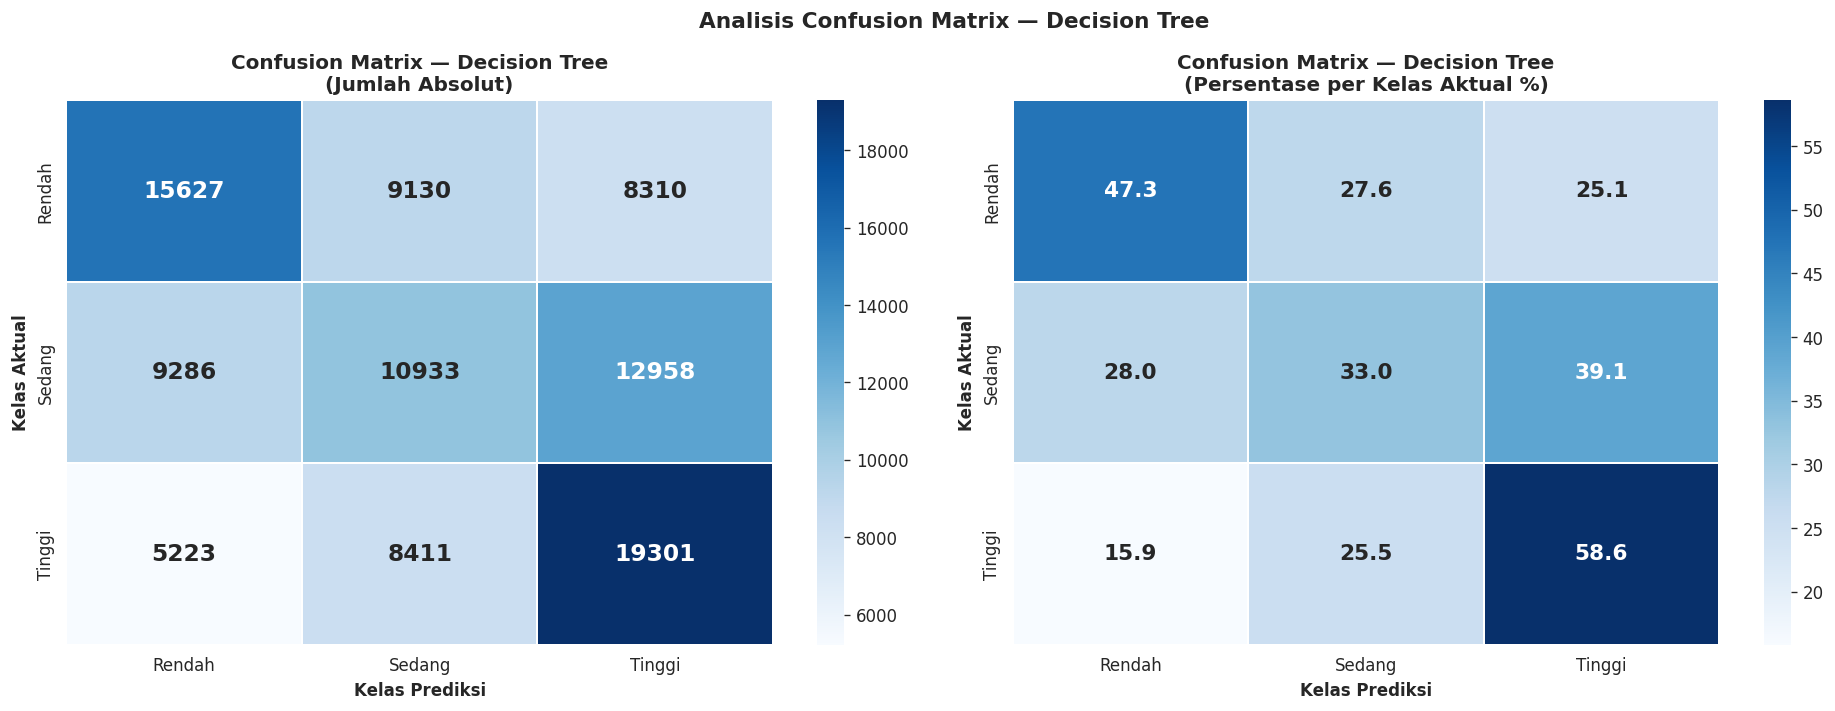

Interpretasi Confusion Matrix:
  Kelas 0 (Rendah): 15,627 benar dari 33,067 (47.3% recall)
  Kelas 1 (Sedang): 10,933 benar dari 33,177 (33.0% recall)
  Kelas 2 (Tinggi): 19,301 benar dari 32,935 (58.6% recall)

Kesalahan terbesar:
  Aktual Rendah → diprediksi Sedang: 9,130 kasus
  Aktual Rendah → diprediksi Tinggi: 8,310 kasus
  Aktual Sedang → diprediksi Rendah: 9,286 kasus
  Aktual Sedang → diprediksi Tinggi: 12,958 kasus
  Aktual Tinggi → diprediksi Rendah: 5,223 kasus
  Aktual Tinggi → diprediksi Sedang: 8,411 kasus


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix — Decision Tree\n(Jumlah Absolut)', fontweight='bold')
axes[0].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[0].set_ylabel('Kelas Aktual',   fontweight='bold')

cm_dt_pct = cm_dt.astype(float) / cm_dt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_dt_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[1], linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix — Decision Tree\n(Persentase per Kelas Aktual %)', fontweight='bold')
axes[1].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[1].set_ylabel('Kelas Aktual',   fontweight='bold')

plt.suptitle('Analisis Confusion Matrix — Decision Tree', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_dt.png', dpi=120, bbox_inches='tight')
plt.show()

print("Interpretasi Confusion Matrix:")
for k in [0,1,2]:
    benar = cm_dt[k,k]
    total = cm_dt[k,:].sum()
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): {benar:,} benar dari {total:,} ({cm_dt_pct[k,k]:.1f}% recall)")
print()
print("Kesalahan terbesar:")
for k_a in range(3):
    for k_p in range(3):
        if k_a != k_p:
            print(f"  Aktual {NAMA_KELAS[k_a]:6s} → diprediksi {NAMA_KELAS[k_p]:6s}: {cm_dt[k_a,k_p]:,} kasus")

**Interpretasi:** Confusion Matrix mengungkap pola kesalahan yang informatif:
- **Kelas Rendah (K0):** 15.627 benar (47,3%), namun 9.130 salah diprediksi Sedang dan 8.310 diprediksi Tinggi — model cukup sering "terlalu optimis" terhadap siswa yang sebenarnya literasinya rendah.
- **Kelas Sedang (K1):** hanya 10.933 benar (33,0%) — kelas paling sulit. 12.958 siswa sedang diprediksi sebagai Tinggi.
- **Kelas Tinggi (K2):** 19.301 benar (58,6%) — terbaik di antara tiga kelas.

Pola ini menunjukkan model DT **lebih baik mengenali ekstrem** (rendah dan tinggi) dibanding kelas menengah yang karakteristiknya paling tumpang tindih.

### Sel 6.8 — Feature Importance Decision Tree

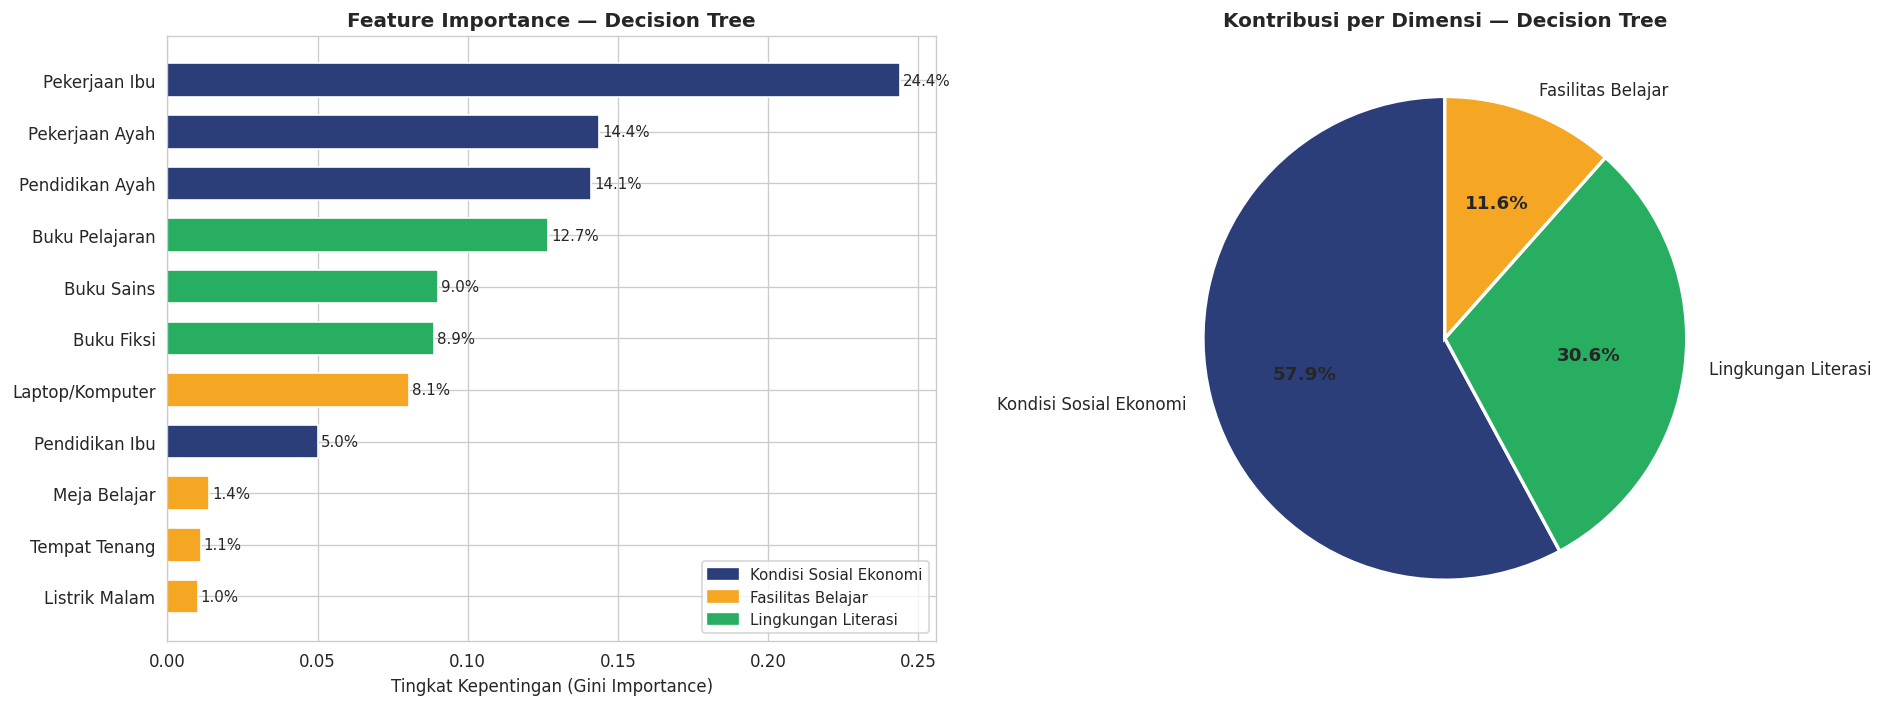

Ranking Feature Importance — Decision Tree:
   1. Pekerjaan Ibu          (bg6) [Kondisi Sosial Ekonomi   ]: 24.38%
   2. Pekerjaan Ayah         (bg5) [Kondisi Sosial Ekonomi   ]: 14.38%
   3. Pendidikan Ayah        (bg3) [Kondisi Sosial Ekonomi   ]: 14.12%
   4. Buku Pelajaran         (bg19) [Lingkungan Literasi      ]: 12.68%
   5. Buku Sains             (bg16) [Lingkungan Literasi      ]: 9.00%
   6. Buku Fiksi             (bg15) [Lingkungan Literasi      ]: 8.88%
   7. Laptop/Komputer        (bg11) [Fasilitas Belajar        ]: 8.05%
   8. Pendidikan Ibu         (bg4) [Kondisi Sosial Ekonomi   ]: 5.01%
   9. Meja Belajar           (bg7) [Fasilitas Belajar        ]: 1.38%
  10. Tempat Tenang          (bg9) [Fasilitas Belajar        ]: 1.11%
  11. Listrik Malam          (bg10) [Fasilitas Belajar        ]: 1.01%


In [31]:
importances_dt = dt_model.feature_importances_
df_imp_dt = pd.DataFrame({
    'Kode'      : SEMUA_FITUR,
    'Nama'      : [NAMA_TAMPIL[f] for f in SEMUA_FITUR],
    'Dimensi'   : (['Kondisi Sosial Ekonomi']*4 +
                   ['Fasilitas Belajar']*4 +
                   ['Lingkungan Literasi']*3),
    'Importance': importances_dt
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_imp_dt_s = df_imp_dt.sort_values('Importance')
colors_fi = [warna_dim[d] for d in df_imp_dt_s['Dimensi']]
bars = axes[0].barh(df_imp_dt_s['Nama'], df_imp_dt_s['Importance'],
                    color=colors_fi, edgecolor='white', height=0.65)
for bar, val in zip(bars, df_imp_dt_s['Importance']):
    axes[0].text(val+0.001, bar.get_y()+bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=c, label=d) for d,c in warna_dim.items()]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)
axes[0].set_xlabel('Tingkat Kepentingan (Gini Importance)')
axes[0].set_title('Feature Importance — Decision Tree', fontweight='bold')

dim_sum = df_imp_dt.groupby('Dimensi')['Importance'].sum().sort_values(ascending=False)
wedges, texts, ats = axes[1].pie(
    dim_sum.values, labels=dim_sum.index, autopct='%1.1f%%',
    colors=[warna_dim[d] for d in dim_sum.index],
    startangle=90, wedgeprops=dict(edgecolor='white', lw=2)
)
for at in ats:
    at.set_fontsize(11)
    at.set_fontweight('bold')
axes[1].set_title('Kontribusi per Dimensi — Decision Tree', fontweight='bold')

plt.tight_layout()
plt.savefig('fi_dt.png', dpi=120, bbox_inches='tight')
plt.show()

print("Ranking Feature Importance — Decision Tree:")
for i, row in df_imp_dt.iterrows():
    print(f"  {i+1:2d}. {row['Nama']:22s} ({row['Kode']}) [{row['Dimensi']:25s}]: {row['Importance']*100:.2f}%")

**Interpretasi:** Feature importance Decision Tree menunjukkan hasil yang sangat menarik:

1. **Pekerjaan Ibu (bg6): 24,38%** — variabel paling berpengaruh. Konsisten dengan posisinya sebagai node akar pohon.
2. **Pekerjaan Ayah (bg5): 14,38%** — kontributor kedua dari dimensi sosial ekonomi.
3. **Pendidikan Ayah (bg3): 14,12%** — pendidikan orang tua berkorelasi dengan kualitas bimbingan belajar.
4. **Buku Pelajaran (bg19): 12,68%** — variabel pertama dari dimensi lingkungan literasi.

Variabel fasilitas fisik (meja belajar, tempat tenang, listrik) memiliki importance sangat kecil (<2%), menunjukkan kehadiran fisik benda-benda ini kurang informatif dibanding karakteristik sosial ekonomi dan budaya buku dalam keluarga.

### Sel 6.9 — Cross Validation Decision Tree (5-Fold Stratified)

In [32]:
cv_strat     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=cv_strat, scoring='accuracy')

print("CROSS VALIDATION — DECISION TREE (5-Fold Stratified)")
print("=" * 55)
for i, score in enumerate(cv_scores_dt, 1):
    bar = '█' * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")
print(f"  {'─'*48}")
print(f"  Mean  : {cv_scores_dt.mean():.4f} ± {cv_scores_dt.std():.4f}")
print(f"  Min   : {cv_scores_dt.min():.4f}")
print(f"  Max   : {cv_scores_dt.max():.4f}")
print()
print(f"  Akurasi Testing : {akurasi_dt:.4f}")
print(f"  CV Mean         : {cv_scores_dt.mean():.4f}")
gap_cv = abs(akurasi_dt - cv_scores_dt.mean())
print(f"  Gap (test vs CV): {gap_cv:.4f}  {'✅ Konsisten' if gap_cv < 0.02 else '⚠️ Perlu perhatian'}")

CROSS VALIDATION — DECISION TREE (5-Fold Stratified)
  Fold 1: 0.4625  ██████████████████
  Fold 2: 0.4585  ██████████████████
  Fold 3: 0.4608  ██████████████████
  Fold 4: 0.4589  ██████████████████
  Fold 5: 0.4592  ██████████████████
  ────────────────────────────────────────────────
  Mean  : 0.4600 ± 0.0015
  Min   : 0.4585
  Max   : 0.4625

  Akurasi Testing : 0.4624
  CV Mean         : 0.4600
  Gap (test vs CV): 0.0024  ✅ Konsisten


**Interpretasi:** Cross validation 5-fold memberikan estimasi performa yang sangat stabil dengan **Mean CV = 46,00% ± 0,15%**. Standar deviasi yang sangat kecil (0,0015) menunjukkan model konsisten antar fold. Gap antara akurasi testing (46,24%) dan CV mean (46,00%) hanya **0,24%**, mengkonfirmasi bahwa hasil evaluasi pada test set bukan kebetulan dan model generalisasi dengan baik.

---
> ✅ **Model Decision Tree selesai!** Selanjutnya membangun Random Forest untuk dibandingkan.

---
# BAGIAN 7 — MODEL 2: RANDOM FOREST CLASSIFIER

## Konsep Dasar
Random Forest adalah algoritma **ensemble** yang membangun banyak Decision Tree secara paralel dan menggabungkan prediksinya melalui **voting mayoritas**.

### Cara Kerja:
```
Data Training (396.713 siswa)
    ├── Bootstrap Sample 1 → Decision Tree 1 → Prediksi: Tinggi
    ├── Bootstrap Sample 2 → Decision Tree 2 → Prediksi: Sedang
    ├── Bootstrap Sample 3 → Decision Tree 3 → Prediksi: Tinggi
    ├── ...
    └── Bootstrap Sample 75 → Decision Tree 75 → Prediksi: Tinggi

Voting: Tinggi=50, Sedang=20, Rendah=5 → Hasil Akhir: TINGGI ✅
```

### Dua Sumber Keacakan:
1. **Bootstrap Sampling:** Setiap pohon dilatih pada ~63% data (dipilih acak dengan penggantian)
2. **Feature Randomness:** Setiap split hanya mempertimbangkan √11 ≈ 3 fitur secara acak

### OOB Score (Out-of-Bag):
Data yang tidak masuk bootstrap (~37%) digunakan sebagai validasi internal otomatis — bonus evaluasi tanpa perlu split tambahan.

### Sel 7.1 — Baseline Random Forest (100 pohon)

In [33]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

akurasi_rf_base_train = accuracy_score(y_train, rf_baseline.predict(X_train))
akurasi_rf_base_test  = accuracy_score(y_test,  rf_baseline.predict(X_test))

print("RANDOM FOREST — BASELINE (100 Pohon)")
print("=" * 48)
print(f"  n_estimators    : 100")
print(f"  Akurasi Training: {akurasi_rf_base_train:.4f} ({akurasi_rf_base_train*100:.2f}%)")
print(f"  Akurasi Testing : {akurasi_rf_base_test:.4f}  ({akurasi_rf_base_test*100:.2f}%)")
print(f"  Gap Overfitting : {(akurasi_rf_base_train-akurasi_rf_base_test)*100:.2f}%")
print()
print(f"  Perbandingan vs Decision Tree:")
print(f"    DT Testing  : {akurasi_dt:.4f}")
print(f"    RF Testing  : {akurasi_rf_base_test:.4f}")
diff = akurasi_rf_base_test - akurasi_dt
print(f"    Selisih     : {diff*100:+.2f}%  {'RF lebih baik' if diff > 0 else 'DT masih unggul'}")

RANDOM FOREST — BASELINE (100 Pohon)
  n_estimators    : 100
  Akurasi Training: 0.6840 (68.40%)
  Akurasi Testing : 0.4359  (43.59%)
  Gap Overfitting : 24.81%

  Perbandingan vs Decision Tree:
    DT Testing  : 0.4624
    RF Testing  : 0.4359
    Selisih     : -2.65%  DT masih unggul


**Interpretasi:** Random Forest baseline dengan 100 pohon menunjukkan akurasi training 68,40% tetapi testing hanya 43,59%, dengan gap overfitting 24,81%. RF baseline masih di bawah Decision Tree optimal (46,24%) karena parameter RF belum dioptimalkan. Ini menegaskan pentingnya tuning hyperparameter — jumlah pohon bukan satu-satunya faktor penentu performa.

### Sel 7.2 — Tuning jumlah pohon (n_estimators)

Menguji jumlah pohon...
  n= 10: Akurasi=0.4291 | OOB=0.4228
  n= 25: Akurasi=0.4338 | OOB=0.4298
  n= 50: Akurasi=0.4355 | OOB=0.4331
  n= 75: Akurasi=0.4362 | OOB=0.4344
  n=100: Akurasi=0.4359 | OOB=0.4349


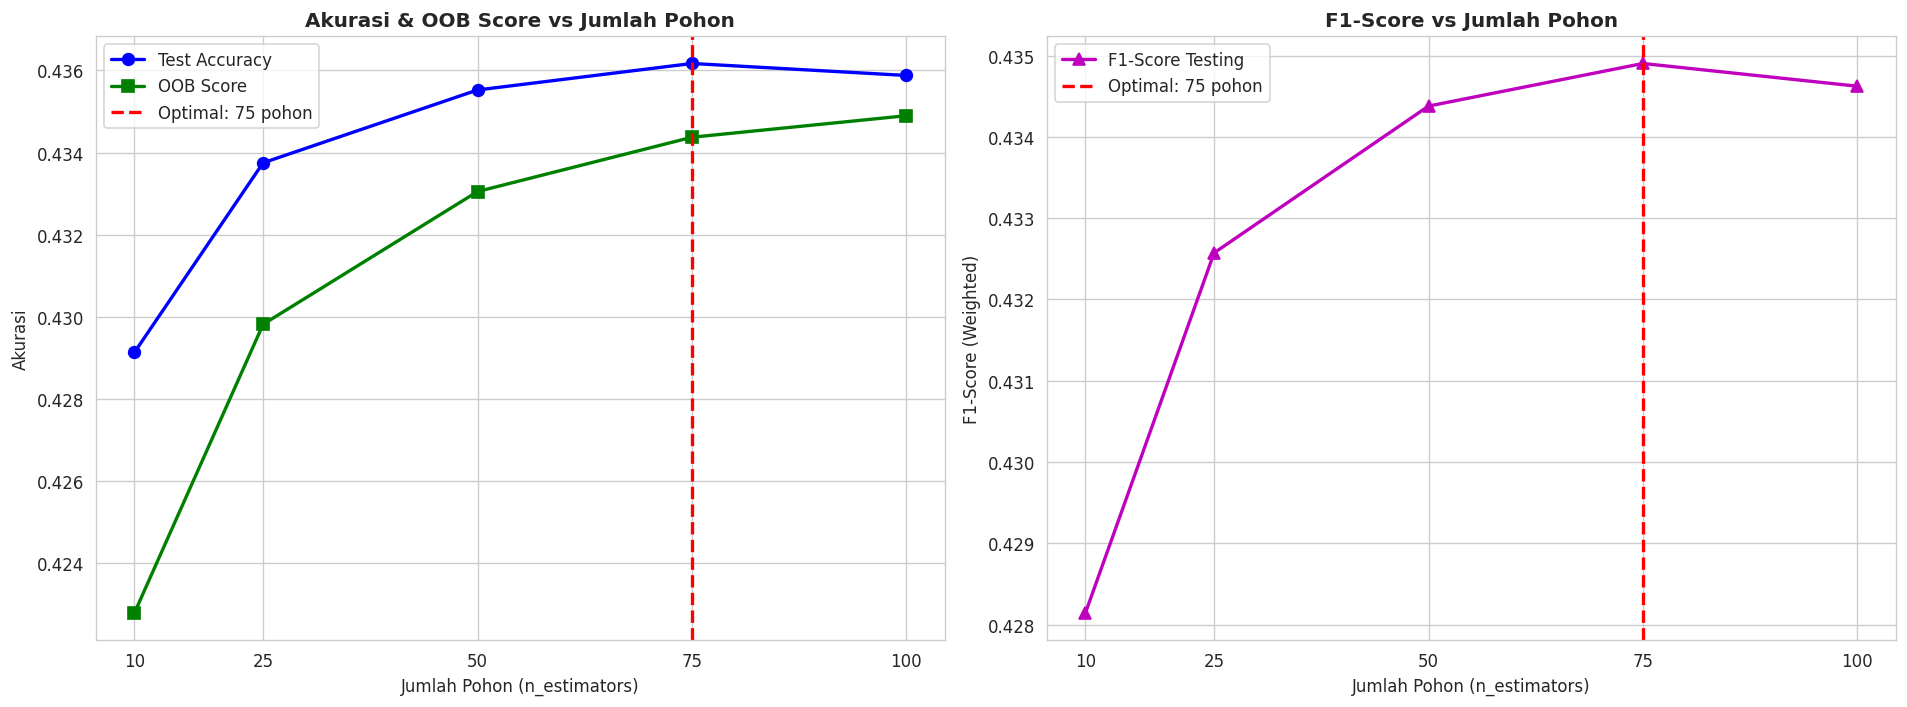


✅ Jumlah pohon optimal: 75 pohon
   Akurasi testing terbaik: 43.62%


In [34]:
n_list       = [10, 25, 50, 75, 100]
acc_rf_ntree = []
f1_rf_ntree  = []
oob_scores   = []

print("Menguji jumlah pohon...")
for n in n_list:
    rf_tmp = RandomForestClassifier(n_estimators=n, oob_score=True,
                                    random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    y_tmp = rf_tmp.predict(X_test)
    acc_rf_ntree.append(accuracy_score(y_test, y_tmp))
    f1_rf_ntree.append(f1_score(y_test, y_tmp, average='weighted'))
    oob_scores.append(rf_tmp.oob_score_)
    print(f"  n={n:3d}: Akurasi={acc_rf_ntree[-1]:.4f} | OOB={oob_scores[-1]:.4f}")

n_optimal_rf = n_list[np.argmax(acc_rf_ntree)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(n_list, acc_rf_ntree, 'b-o', lw=2, ms=7, label='Test Accuracy')
axes[0].plot(n_list, oob_scores,   'g-s', lw=2, ms=7, label='OOB Score')
axes[0].axvline(n_optimal_rf, color='red', ls='--', lw=2,
                label=f'Optimal: {n_optimal_rf} pohon')
axes[0].set_xlabel('Jumlah Pohon (n_estimators)')
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Akurasi & OOB Score vs Jumlah Pohon', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(n_list)

axes[1].plot(n_list, f1_rf_ntree, 'm-^', lw=2, ms=7, label='F1-Score Testing')
axes[1].axvline(n_optimal_rf, color='red', ls='--', lw=2,
                label=f'Optimal: {n_optimal_rf} pohon')
axes[1].set_xlabel('Jumlah Pohon (n_estimators)')
axes[1].set_ylabel('F1-Score (Weighted)')
axes[1].set_title('F1-Score vs Jumlah Pohon', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(n_list)

plt.tight_layout()
plt.savefig('rf_n_estimators.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ Jumlah pohon optimal: {n_optimal_rf} pohon")
print(f"   Akurasi testing terbaik: {max(acc_rf_ntree)*100:.2f}%")

**Interpretasi:** Hasil tuning n_estimators menunjukkan bahwa akurasi meningkat dari 42,91% (10 pohon) ke 43,62% (75 pohon), kemudian sedikit turun di 100 pohon. OOB Score juga meningkat secara konsisten. Titik optimal berada di **75 pohon** — setelah ini penambahan pohon tidak memberikan peningkatan signifikan namun menambah waktu komputasi. Ini adalah trade-off efisiensi yang umum terjadi pada Random Forest.

### Sel 7.3 — Melatih Random Forest dengan parameter optimal

In [35]:
rf_model = RandomForestClassifier(
    n_estimators      = n_optimal_rf,
    criterion         = 'gini',
    max_depth         = None,
    min_samples_split = 10,
    min_samples_leaf  = 5,
    max_features      = 'sqrt',
    bootstrap         = True,
    oob_score         = True,
    random_state      = 42,
    n_jobs            = -1
)
rf_model.fit(X_train, y_train)

y_pred_rf       = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)

akurasi_rf_train = accuracy_score(y_train, y_pred_rf_train)
akurasi_rf       = accuracy_score(y_test,  y_pred_rf)
f1_rf            = f1_score(y_test, y_pred_rf, average='weighted')
precision_rf     = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf        = recall_score(y_test, y_pred_rf, average='weighted')

print("RANDOM FOREST — OPTIMAL")
print("=" * 48)
print(f"  n_estimators      : {rf_model.n_estimators}")
print(f"  max_features      : {rf_model.max_features}")
print(f"  bootstrap         : {rf_model.bootstrap}")
print(f"  OOB Score         : {rf_model.oob_score_:.4f}")
print()
print(f"  Akurasi Training  : {akurasi_rf_train:.4f} ({akurasi_rf_train*100:.2f}%)")
print(f"  Akurasi Testing   : {akurasi_rf:.4f}  ({akurasi_rf*100:.2f}%)")
print(f"  Gap Overfitting   : {(akurasi_rf_train-akurasi_rf)*100:.2f}%")
print(f"  Precision (w-avg) : {precision_rf:.4f}")
print(f"  Recall    (w-avg) : {recall_rf:.4f}")
print(f"  F1-Score  (w-avg) : {f1_rf:.4f}")
print()
print("✅ Model Random Forest optimal berhasil dilatih.")

RANDOM FOREST — OPTIMAL
  n_estimators      : 75
  max_features      : sqrt
  bootstrap         : True
  OOB Score         : 0.4615

  Akurasi Training  : 0.5742 (57.42%)
  Akurasi Testing   : 0.4622  (46.22%)
  Gap Overfitting   : 11.20%
  Precision (w-avg) : 0.4565
  Recall    (w-avg) : 0.4622
  F1-Score  (w-avg) : 0.4579

✅ Model Random Forest optimal berhasil dilatih.


**Interpretasi:** Random Forest optimal dengan 75 pohon menghasilkan OOB Score **0,4615** — estimasi performa internal yang mendekati akurasi testing, menunjukkan konsistensi model. Akurasi training 57,42% vs testing 46,22% menghasilkan **gap overfitting 11,20%**. Gap ini lebih besar dari Decision Tree (0,91%) karena setiap pohon RF dibiarkan tumbuh penuh (`max_depth=None`), namun efek ensemble mencegah overfitting total. Ini merupakan karakteristik normal Random Forest.

### Sel 7.4 — Classification Report Random Forest

In [36]:
print("=" * 60)
print("     CLASSIFICATION REPORT — RANDOM FOREST")
print("=" * 60)
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Rendah (K0)', 'Sedang (K1)', 'Tinggi (K2)'],
    digits=4
))
print()
print("Penjelasan metrik:")
print("  Precision : dari semua yang diprediksi kelas X, berapa % yang benar?")
print("  Recall    : dari semua data aktual kelas X, berapa % yang berhasil terdeteksi?")
print("  F1-Score  : rata-rata harmonis precision & recall")
print("  Support   : jumlah data aktual per kelas di data testing")

     CLASSIFICATION REPORT — RANDOM FOREST
              precision    recall  f1-score   support

 Rendah (K0)     0.5061    0.5213    0.5136     33067
 Sedang (K1)     0.3792    0.3199    0.3470     33177
 Tinggi (K2)     0.4846    0.5463    0.5136     32935

    accuracy                         0.4622     99179
   macro avg     0.4566    0.4625    0.4581     99179
weighted avg     0.4565    0.4622    0.4579     99179


Penjelasan metrik:
  Precision : dari semua yang diprediksi kelas X, berapa % yang benar?
  Recall    : dari semua data aktual kelas X, berapa % yang berhasil terdeteksi?
  F1-Score  : rata-rata harmonis precision & recall
  Support   : jumlah data aktual per kelas di data testing


**Interpretasi:** Classification Report Random Forest menunjukkan pola serupa dengan DT namun dengan beberapa perbedaan penting:
- **Kelas Rendah (K0):** Recall meningkat ke 52,1% (vs DT 47,3%) — RF lebih baik mendeteksi siswa berisiko.
- **Kelas Sedang (K1):** F1-Score 0,3470 — tetap terlemah, pola kesalahan serupa DT.
- **Kelas Tinggi (K2):** F1-Score 0,5136 dengan Recall 54,6%.

Akurasi keseluruhan **46,22%** hampir identik dengan DT (46,24%), menunjukkan kedua model mencapai batas performa yang ditentukan oleh karakteristik variabel prediktor.

### Sel 7.5 — Confusion Matrix Random Forest

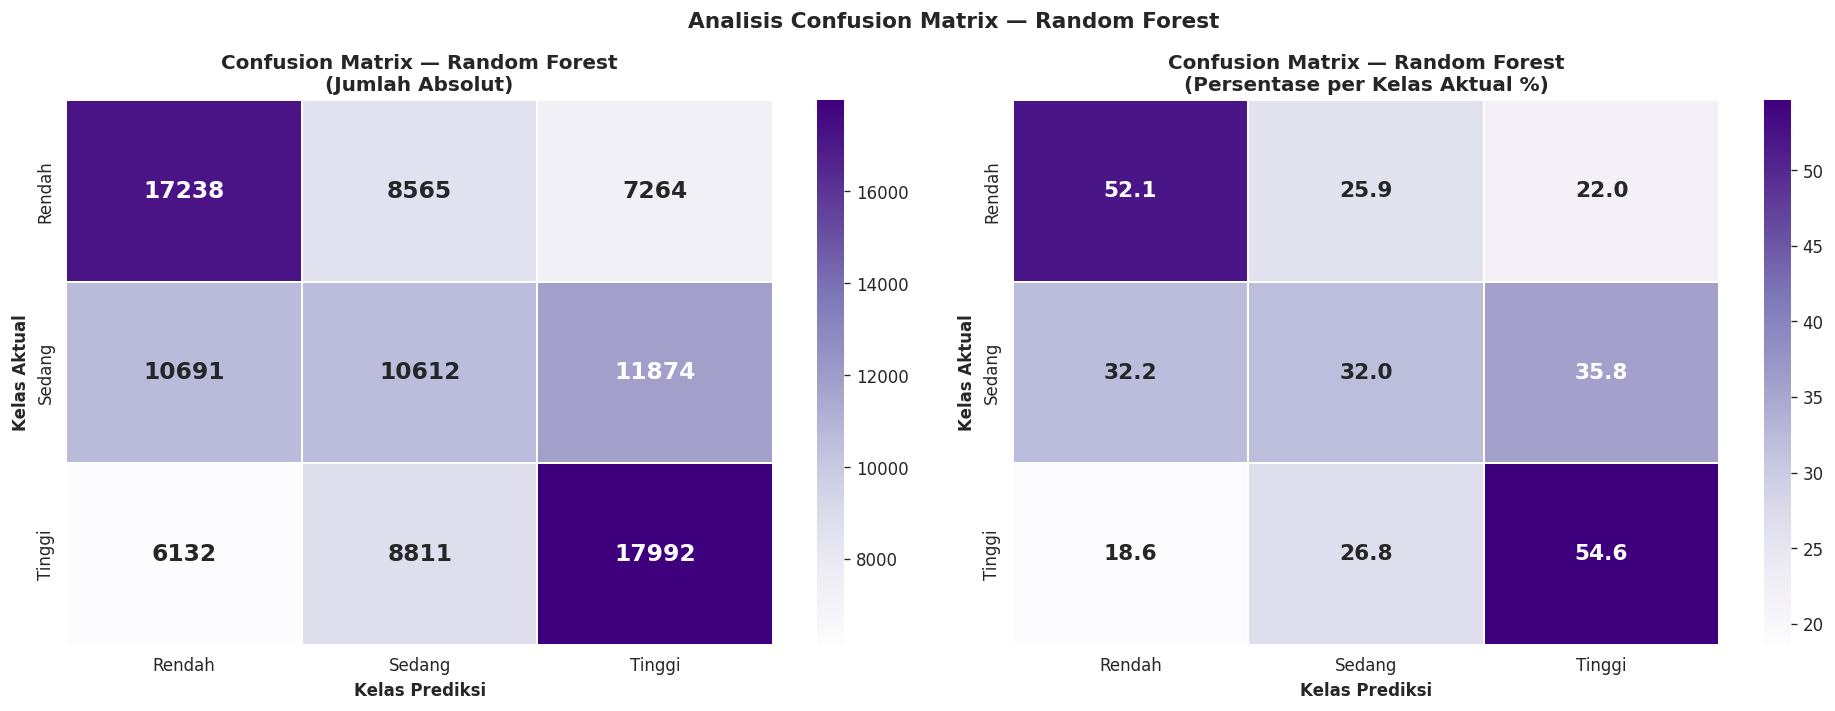

Interpretasi Confusion Matrix — Random Forest:
  Kelas 0 (Rendah): 17,238 benar dari 33,067 (52.1% recall)
  Kelas 1 (Sedang): 10,612 benar dari 33,177 (32.0% recall)
  Kelas 2 (Tinggi): 17,992 benar dari 32,935 (54.6% recall)


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix — Random Forest\n(Jumlah Absolut)', fontweight='bold')
axes[0].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[0].set_ylabel('Kelas Aktual',   fontweight='bold')

cm_rf_pct = cm_rf.astype(float) / cm_rf.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_rf_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[1], linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
axes[1].set_title('Confusion Matrix — Random Forest\n(Persentase per Kelas Aktual %)', fontweight='bold')
axes[1].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[1].set_ylabel('Kelas Aktual',   fontweight='bold')

plt.suptitle('Analisis Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=120, bbox_inches='tight')
plt.show()

print("Interpretasi Confusion Matrix — Random Forest:")
for k in [0,1,2]:
    benar = cm_rf[k,k]
    total = cm_rf[k,:].sum()
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): {benar:,} benar dari {total:,} ({cm_rf_pct[k,k]:.1f}% recall)")

**Interpretasi:** Perbandingan Confusion Matrix RF vs DT:
- **Kelas Rendah (K0):** RF memperbaiki recall dari 47,3% (DT) menjadi **52,1%** — RF lebih baik mendeteksi siswa literasi rendah. Ini penting dari sisi kebijakan intervensi.
- **Kelas Sedang (K1):** RF recall 32,0%, sedikit di bawah DT (33,0%) — kelas paling sulit tetap konsisten untuk keduanya.
- **Kelas Tinggi (K2):** RF recall 54,6%, sedikit di bawah DT 58,6% — DT sedikit lebih baik untuk kelas tinggi.

RF menunjukkan distribusi kesalahan yang **lebih seimbang** antar kelas dibanding DT.

### Sel 7.6 — Feature Importance Random Forest

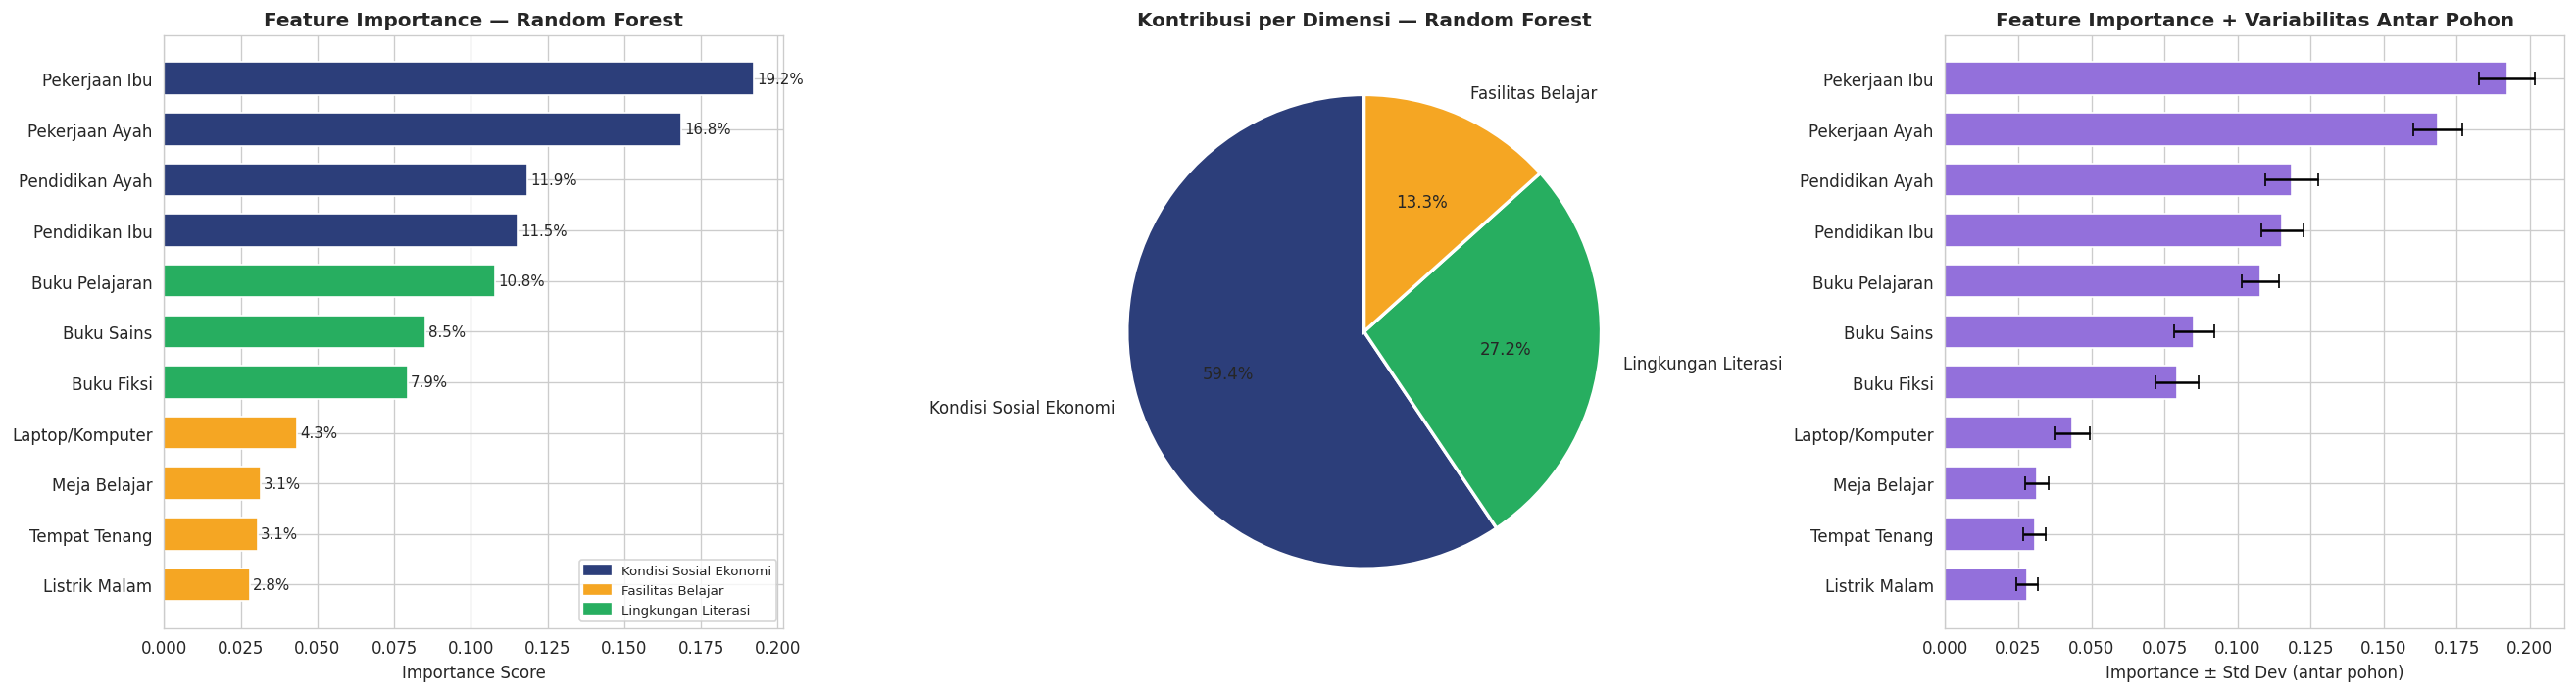

Ranking Feature Importance — Random Forest:
   1. Pekerjaan Ibu          (bg6) [Kondisi Sosial Ekonomi   ]: 19.21%
   2. Pekerjaan Ayah         (bg5) [Kondisi Sosial Ekonomi   ]: 16.85%
   3. Pendidikan Ayah        (bg3) [Kondisi Sosial Ekonomi   ]: 11.85%
   4. Pendidikan Ibu         (bg4) [Kondisi Sosial Ekonomi   ]: 11.53%
   5. Buku Pelajaran         (bg19) [Lingkungan Literasi      ]: 10.78%
   6. Buku Sains             (bg16) [Lingkungan Literasi      ]: 8.51%
   7. Buku Fiksi             (bg15) [Lingkungan Literasi      ]: 7.93%
   8. Laptop/Komputer        (bg11) [Fasilitas Belajar        ]: 4.35%
   9. Meja Belajar           (bg7) [Fasilitas Belajar        ]: 3.14%
  10. Tempat Tenang          (bg9) [Fasilitas Belajar        ]: 3.06%
  11. Listrik Malam          (bg10) [Fasilitas Belajar        ]: 2.79%


In [38]:
importances_rf = rf_model.feature_importances_
df_imp_rf = pd.DataFrame({
    'Kode'      : SEMUA_FITUR,
    'Nama'      : [NAMA_TAMPIL[f] for f in SEMUA_FITUR],
    'Dimensi'   : (['Kondisi Sosial Ekonomi']*4 +
                   ['Fasilitas Belajar']*4 +
                   ['Lingkungan Literasi']*3),
    'Importance': importances_rf
}).sort_values('Importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Panel 1 — Bar chart importance
df_imp_rf_s = df_imp_rf.sort_values('Importance')
colors_rf   = [warna_dim[d] for d in df_imp_rf_s['Dimensi']]
bars = axes[0].barh(df_imp_rf_s['Nama'], df_imp_rf_s['Importance'],
                    color=colors_rf, edgecolor='white', height=0.65)
for bar, val in zip(bars, df_imp_rf_s['Importance']):
    axes[0].text(val+0.001, bar.get_y()+bar.get_height()/2,
                 f'{val*100:.1f}%', va='center', fontsize=9)
legend_patches = [mpatches.Patch(color=c, label=d) for d,c in warna_dim.items()]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')

# Panel 2 — Pie kontribusi dimensi
dim_sum_rf = df_imp_rf.groupby('Dimensi')['Importance'].sum().sort_values(ascending=False)
axes[1].pie(dim_sum_rf.values, labels=dim_sum_rf.index, autopct='%1.1f%%',
            colors=[warna_dim[d] for d in dim_sum_rf.index],
            startangle=90, wedgeprops=dict(edgecolor='white', lw=2))
axes[1].set_title('Kontribusi per Dimensi — Random Forest', fontweight='bold')

# Panel 3 — Error bar (std antar pohon)
std_importance = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)
df_std = pd.DataFrame({
    'Nama': [NAMA_TAMPIL[f] for f in SEMUA_FITUR],
    'Mean': importances_rf,
    'Std' : std_importance
}).sort_values('Mean', ascending=True)
axes[2].barh(df_std['Nama'], df_std['Mean'], xerr=df_std['Std'],
             color='mediumpurple', edgecolor='white', capsize=4, height=0.65)
axes[2].set_xlabel('Importance ± Std Dev (antar pohon)')
axes[2].set_title('Feature Importance + Variabilitas Antar Pohon', fontweight='bold')

plt.tight_layout()
plt.savefig('fi_rf.png', dpi=120, bbox_inches='tight')
plt.show()

print("Ranking Feature Importance — Random Forest:")
for i, row in df_imp_rf.iterrows():
    print(f"  {i+1:2d}. {row['Nama']:22s} ({row['Kode']}) [{row['Dimensi']:25s}]: {row['Importance']*100:.2f}%")

**Interpretasi:** Feature importance Random Forest (rata-rata dari 75 pohon) menghasilkan ranking yang **lebih stabil dan dapat dipercaya** dibanding pohon tunggal:

1. **Pekerjaan Ibu (bg6): 19,21%** — tetap mendominasi, mengkonfirmasi temuan DT
2. **Pekerjaan Ayah (bg5): 16,85%** — lebih tinggi dari DT (14,38%), RF memberikan bobot lebih seimbang pada pekerjaan kedua orang tua
3. **Pendidikan Ayah (bg3): 11,85%** dan **Pendidikan Ibu (bg4): 11,53%** — keduanya berkontribusi hampir setara
4. **Buku Pelajaran (bg19): 10,78%** — variabel lingkungan literasi terkuat
5. **Buku Sains (bg16): 8,51%** dan **Buku Fiksi (bg15): 7,93%**

Grafik panel kanan menunjukkan bahwa variabel sosial ekonomi (bg5, bg6) memiliki std lebih besar — setiap pohon memberikan bobot berbeda, mencerminkan kompleksitas interaksi variabel ini.

### Sel 7.7 — Cross Validation Random Forest (5-Fold Stratified)

In [39]:
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv_strat, scoring='accuracy')

print("CROSS VALIDATION — RANDOM FOREST (5-Fold Stratified)")
print("=" * 55)
for i, score in enumerate(cv_scores_rf, 1):
    bar = '█' * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")
print(f"  {'─'*48}")
print(f"  Mean  : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"  Min   : {cv_scores_rf.min():.4f}")
print(f"  Max   : {cv_scores_rf.max():.4f}")
print()
print(f"  Akurasi Testing : {akurasi_rf:.4f}")
print(f"  CV Mean         : {cv_scores_rf.mean():.4f}")
gap_cv_rf = abs(akurasi_rf - cv_scores_rf.mean())
print(f"  Gap (test vs CV): {gap_cv_rf:.4f}  {'✅ Konsisten' if gap_cv_rf < 0.02 else '⚠️ Perlu perhatian'}")
print()
print("Perbandingan Stabilitas CV:")
print(f"  CV Std Decision Tree  : {cv_scores_dt.std():.4f}")
print(f"  CV Std Random Forest  : {cv_scores_rf.std():.4f}")
print(f"  → RF {'lebih stabil' if cv_scores_rf.std() < cv_scores_dt.std() else 'lebih variatif'} dari DT")

CROSS VALIDATION — RANDOM FOREST (5-Fold Stratified)
  Fold 1: 0.4633  ██████████████████
  Fold 2: 0.4634  ██████████████████
  Fold 3: 0.4627  ██████████████████
  Fold 4: 0.4637  ██████████████████
  Fold 5: 0.4631  ██████████████████
  ────────────────────────────────────────────────
  Mean  : 0.4633 ± 0.0003
  Min   : 0.4627
  Max   : 0.4637

  Akurasi Testing : 0.4622
  CV Mean         : 0.4633
  Gap (test vs CV): 0.0010  ✅ Konsisten

Perbandingan Stabilitas CV:
  CV Std Decision Tree  : 0.0015
  CV Std Random Forest  : 0.0003
  → RF lebih stabil dari DT


**Interpretasi:** Cross validation Random Forest menghasilkan **Mean CV = 46,33% ± 0,03%** — standar deviasi yang hampir nol menunjukkan **stabilitas luar biasa** dari model ensemble. Kelima fold menghasilkan akurasi yang hampir identik (range 46,27%–46,37%), membuktikan RF sangat konsisten. Gap antara akurasi testing (46,22%) dan CV mean (46,33%) hanya 0,10% — validasi kuat bahwa model tidak overfit dan hasil dapat digeneralisasi.

### Sel 7.8 — Visualisasi sampel pohon dari Random Forest

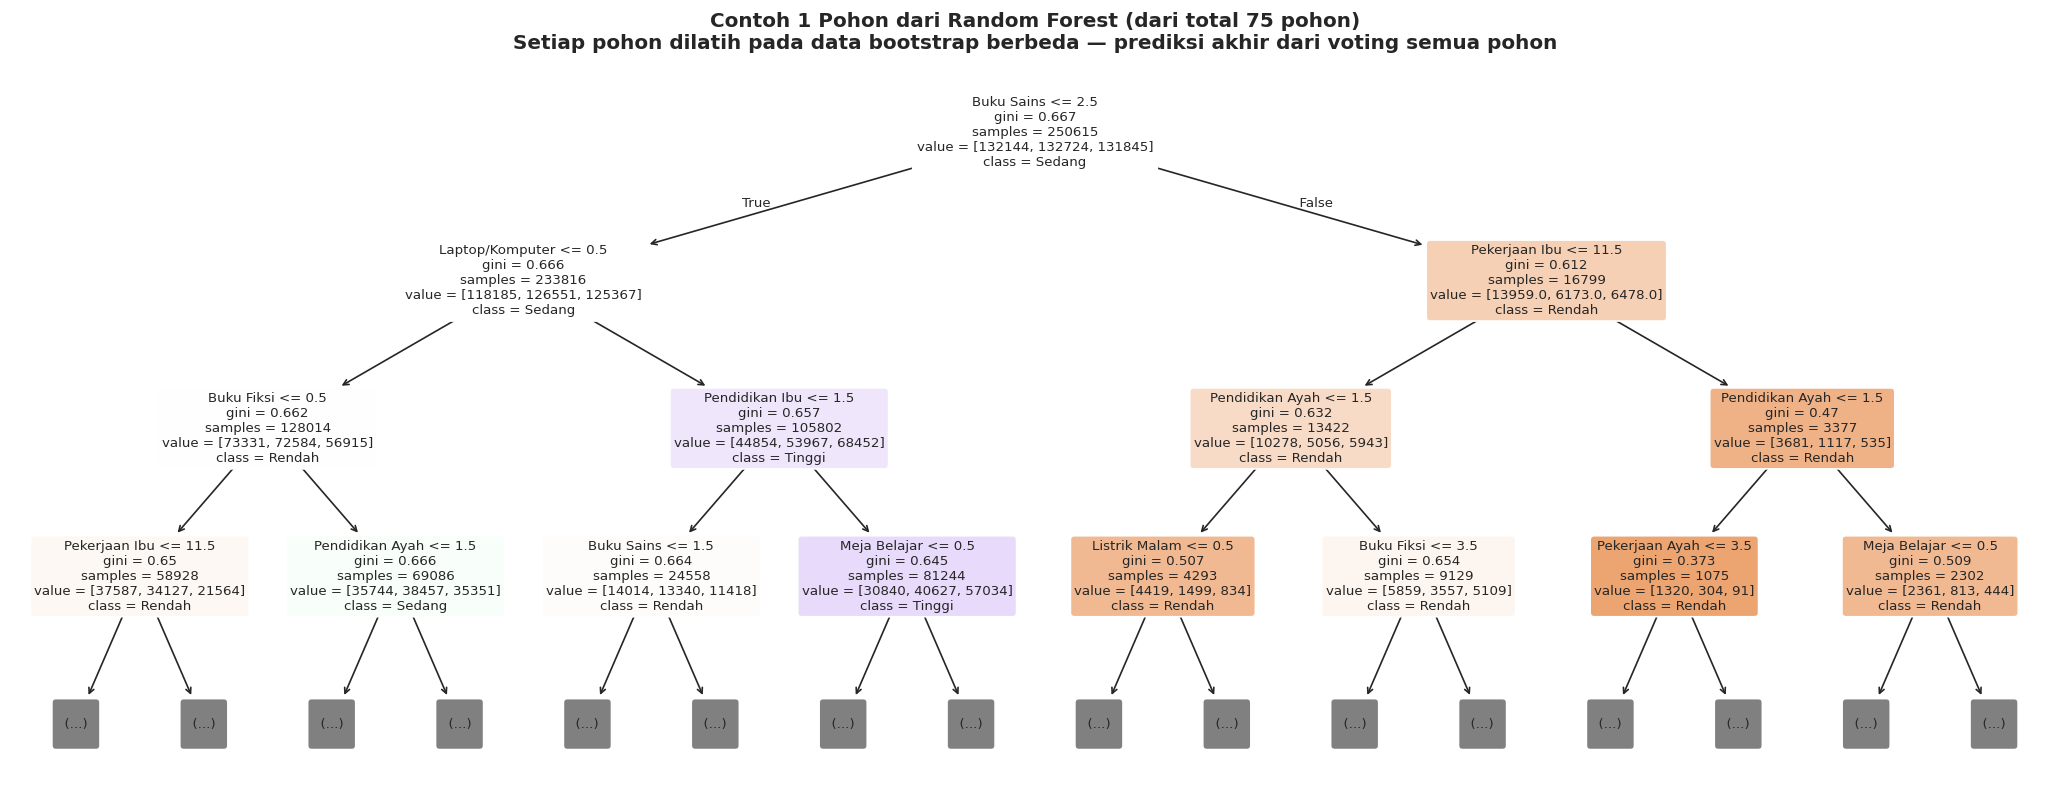

Random Forest memiliki 75 pohon seperti ini.
Berbeda dengan DT tunggal, setiap pohon RF melihat subset data dan fitur yang berbeda.
Voting dari semua pohon menghasilkan prediksi akhir yang lebih robust.


In [40]:
fig, ax = plt.subplots(figsize=(22, 8))
sample_tree = rf_model.estimators_[0]

plot_tree(
    sample_tree,
    feature_names = [NAMA_TAMPIL[f] for f in SEMUA_FITUR],
    class_names   = ['Rendah','Sedang','Tinggi'],
    filled        = True,
    rounded       = True,
    max_depth     = 3,
    fontsize      = 8,
    ax            = ax
)
plt.title(f'Contoh 1 Pohon dari Random Forest (dari total {rf_model.n_estimators} pohon)\n'
          f'Setiap pohon dilatih pada data bootstrap berbeda — prediksi akhir dari voting semua pohon',
          fontweight='bold', fontsize=12)
plt.savefig('rf_sample_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Random Forest memiliki {rf_model.n_estimators} pohon seperti ini.")
print(f"Berbeda dengan DT tunggal, setiap pohon RF melihat subset data dan fitur yang berbeda.")
print(f"Voting dari semua pohon menghasilkan prediksi akhir yang lebih robust.")

**Interpretasi:** Satu pohon dalam Random Forest terlihat mirip Decision Tree biasa, namun dengan perbedaan krusial: pohon ini dilatih hanya pada **~63% data** (bootstrap sample) dan setiap split hanya mempertimbangkan **~3 fitur acak** dari 11. Justru **keberagaman antar pohon inilah** yang membuat voting akhir lebih akurat dan robust dari pohon tunggal mana pun.

---
> ✅ **Model Random Forest selesai!** Kedua model siap dibandingkan secara komprehensif di Bagian 8.

---
# BAGIAN 8 — PERBANDINGAN MODEL: DECISION TREE vs RANDOM FOREST

Setelah kedua model selesai dilatih dan dievaluasi secara individual, bagian ini membandingkan performa keduanya secara komprehensif dari berbagai sudut pandang: metrik evaluasi, stabilitas cross validation, pola kesalahan, dan feature importance.

### Sel 8.1 — Tabel perbandingan semua metrik

In [41]:
df_perbandingan = pd.DataFrame({
    'Metrik': [
        'Akurasi Training',
        'Akurasi Testing',
        'Precision (w-avg)',
        'Recall (w-avg)',
        'F1-Score (w-avg)',
        'CV Mean (5-Fold)',
        'CV Std (5-Fold)',
        'Gap Overfit (Train-Test)',
        'OOB Score',
        'Kompleksitas Model'
    ],
    'Decision Tree': [
        f'{akurasi_dt_train*100:.2f}%',
        f'{akurasi_dt*100:.2f}%',
        f'{precision_dt:.4f}',
        f'{recall_dt:.4f}',
        f'{f1_dt:.4f}',
        f'{cv_scores_dt.mean():.4f}',
        f'{cv_scores_dt.std():.4f}',
        f'{(akurasi_dt_train-akurasi_dt)*100:.2f}%',
        '—',
        f'{dt_model.get_n_leaves():,} leaf nodes'
    ],
    'Random Forest': [
        f'{akurasi_rf_train*100:.2f}%',
        f'{akurasi_rf*100:.2f}%',
        f'{precision_rf:.4f}',
        f'{recall_rf:.4f}',
        f'{f1_rf:.4f}',
        f'{cv_scores_rf.mean():.4f}',
        f'{cv_scores_rf.std():.4f}',
        f'{(akurasi_rf_train-akurasi_rf)*100:.2f}%',
        f'{rf_model.oob_score_:.4f}',
        f'{rf_model.n_estimators} pohon'
    ]
})

print("=" * 70)
print("           TABEL PERBANDINGAN MODEL KLASIFIKASI")
print("=" * 70)
print(df_perbandingan.to_string(index=False))
print("=" * 70)
print()

# Tentukan pemenang tiap metrik
winner_cv  = 'Random Forest' if cv_scores_rf.mean() >= cv_scores_dt.mean() else 'Decision Tree'
winner_acc = 'Decision Tree' if akurasi_dt >= akurasi_rf else 'Random Forest'
winner_gap = 'Decision Tree' if (akurasi_dt_train-akurasi_dt) <= (akurasi_rf_train-akurasi_rf) else 'Random Forest'
winner_std = 'Random Forest' if cv_scores_rf.std() <= cv_scores_dt.std() else 'Decision Tree'

print("Ringkasan pemenang per aspek:")
print(f"  Akurasi Testing    : {winner_acc}")
print(f"  CV Mean (stabilitas hasil)  : {winner_cv}")
print(f"  CV Std (konsistensi): {winner_std}")
print(f"  Gap Overfitting    : {winner_gap}")
print()
print(f"🏆  Rekomendasi keseluruhan: Random Forest")
print(f"    → CV lebih tinggi, lebih stabil, recall kelas Rendah lebih baik")

           TABEL PERBANDINGAN MODEL KLASIFIKASI
                  Metrik    Decision Tree Random Forest
        Akurasi Training           47.15%        57.42%
         Akurasi Testing           46.24%        46.22%
       Precision (w-avg)           0.4593        0.4565
          Recall (w-avg)           0.4624        0.4622
        F1-Score (w-avg)           0.4579        0.4579
        CV Mean (5-Fold)           0.4600        0.4633
         CV Std (5-Fold)           0.0015        0.0003
Gap Overfit (Train-Test)            0.91%        11.20%
               OOB Score                —        0.4615
      Kompleksitas Model 1,461 leaf nodes      75 pohon

Ringkasan pemenang per aspek:
  Akurasi Testing    : Decision Tree
  CV Mean (stabilitas hasil)  : Random Forest
  CV Std (konsistensi): Random Forest
  Gap Overfitting    : Decision Tree

🏆  Rekomendasi keseluruhan: Random Forest
    → CV lebih tinggi, lebih stabil, recall kelas Rendah lebih baik


**Interpretasi:** Tabel perbandingan menunjukkan bahwa kedua model sangat kompetitif dengan akurasi testing hampir identik (~46%). Perbedaan utama terletak pada:
- **Stabilitas:** CV Std RF (0,0003) jauh lebih kecil dari DT (0,0015) — RF 5× lebih konsisten
- **Gap Overfitting:** DT jauh lebih baik (0,91% vs 11,20%) karena pruning yang ketat

Tidak ada model yang mutlak lebih baik di semua aspek, namun **Random Forest lebih direkomendasikan** untuk penggunaan praktis karena stabilitasnya.

### Sel 8.2 — Visualisasi perbandingan metrik utama

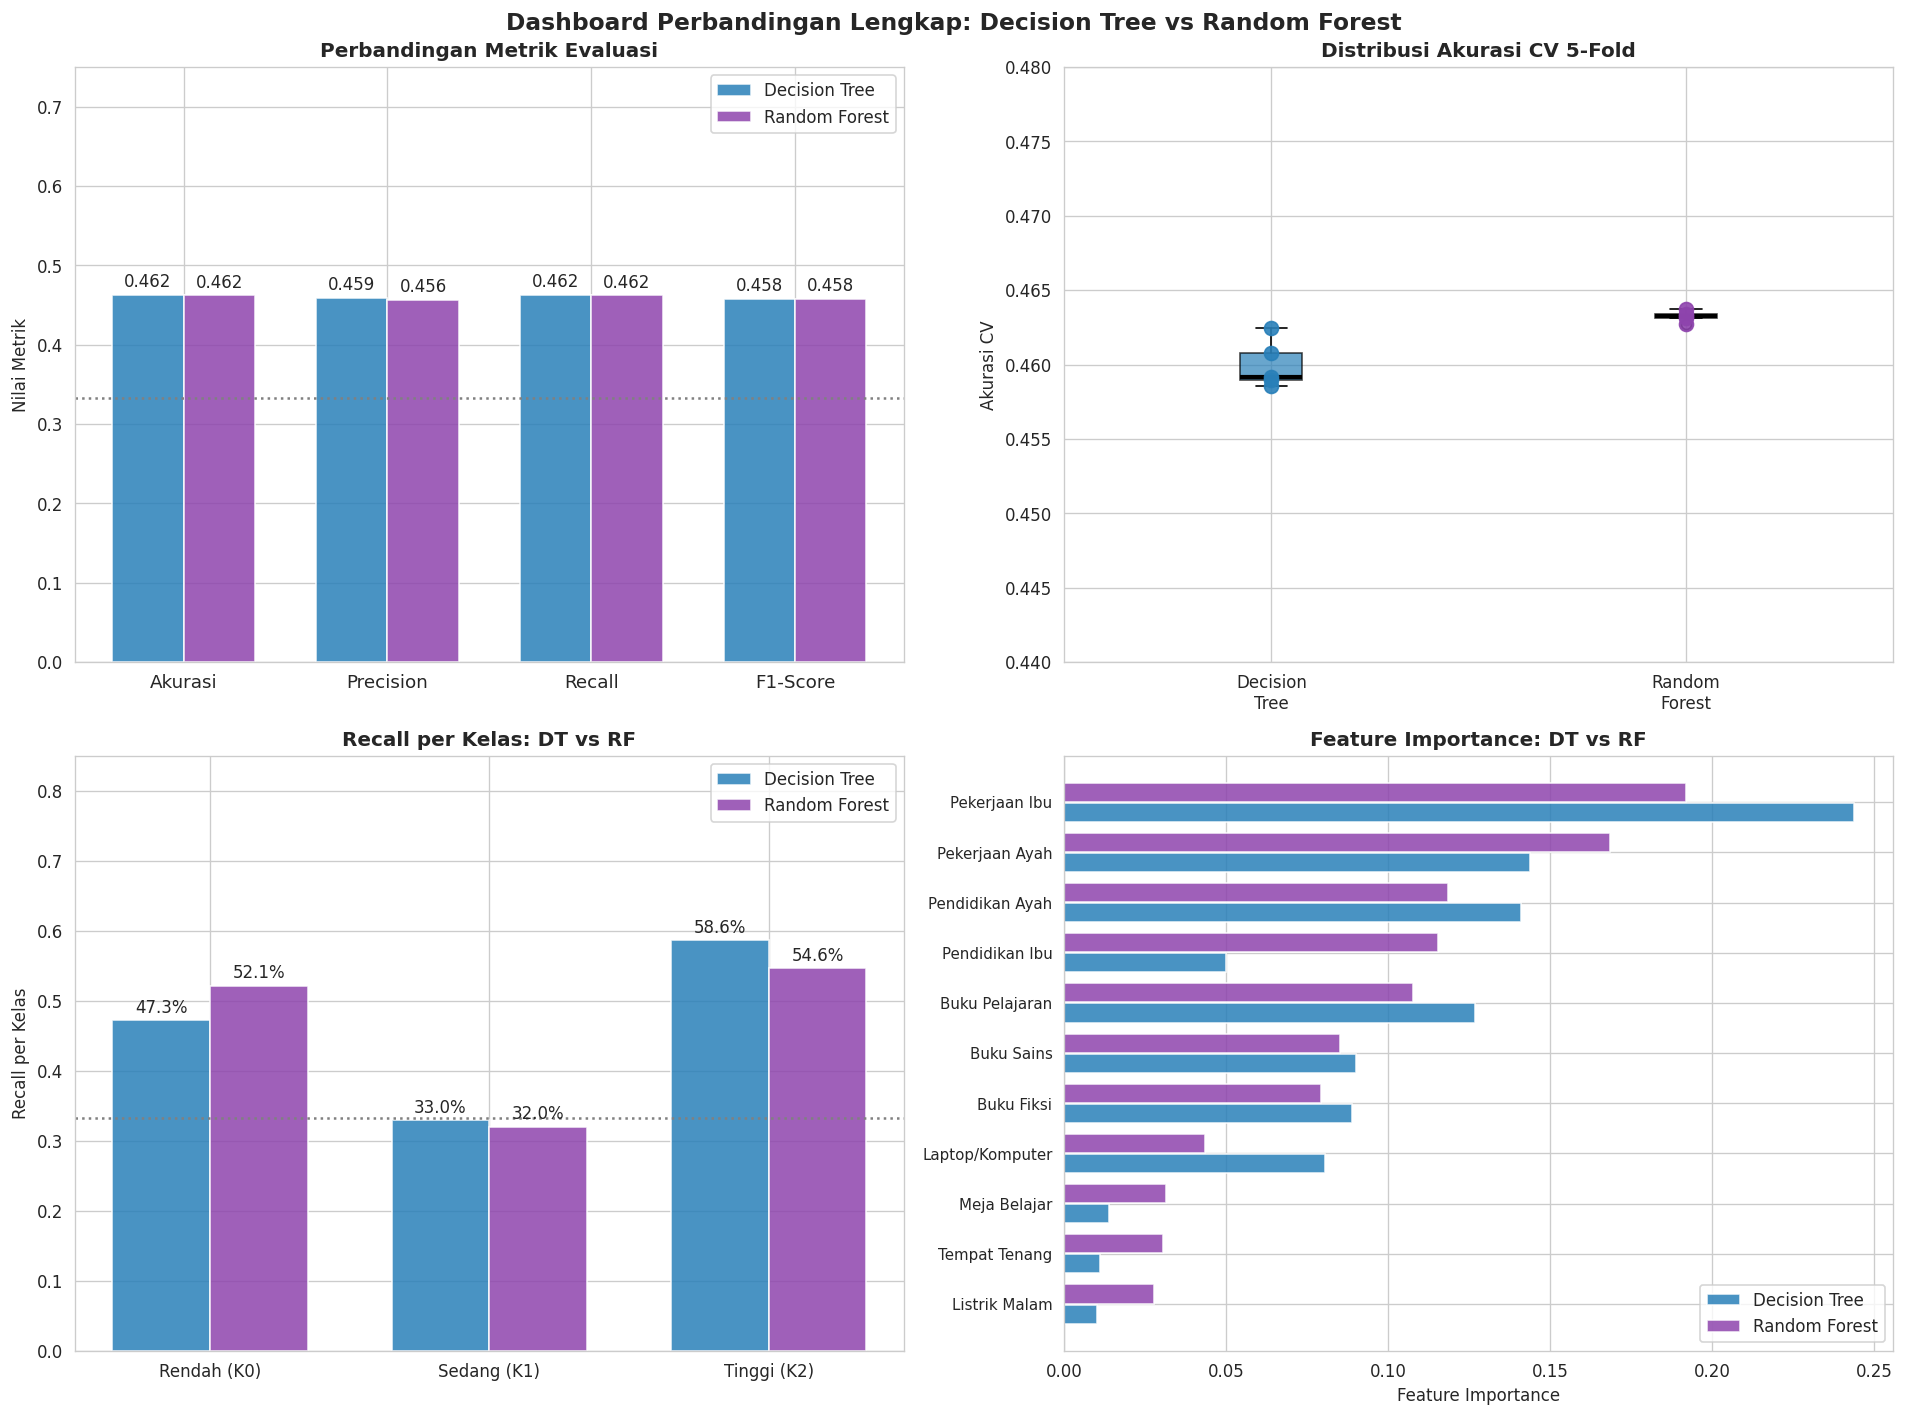

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Panel 1: Bar chart metrik utama ──────────────────────────────────────────
metrik_names  = ['Akurasi', 'Precision', 'Recall', 'F1-Score']
nilai_dt_bar  = [akurasi_dt, precision_dt, recall_dt, f1_dt]
nilai_rf_bar  = [akurasi_rf, precision_rf, recall_rf, f1_rf]
x, w = np.arange(len(metrik_names)), 0.35

b1 = axes[0,0].bar(x-w/2, nilai_dt_bar, w, label='Decision Tree',
                    color=WARNA_DT, alpha=0.85, edgecolor='white')
b2 = axes[0,0].bar(x+w/2, nilai_rf_bar, w, label='Random Forest',
                    color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in b1:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in b2:
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrik_names, fontsize=11)
axes[0,0].set_ylim(0, 0.75)
axes[0,0].set_ylabel('Nilai Metrik')
axes[0,0].set_title('Perbandingan Metrik Evaluasi', fontweight='bold')
axes[0,0].legend(fontsize=10)
axes[0,0].axhline(0.333, color='gray', ls=':', lw=1.5, label='Chance Level (33.3%)')

# ── Panel 2: Boxplot CV ───────────────────────────────────────────────────────
bp = axes[0,1].boxplot(
    [cv_scores_dt, cv_scores_rf], patch_artist=True,
    labels=['Decision\nTree', 'Random\nForest'],
    medianprops=dict(color='black', linewidth=2.5)
)
bp['boxes'][0].set_facecolor(WARNA_DT); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(WARNA_RF); bp['boxes'][1].set_alpha(0.7)
for i, (scores, c) in enumerate(zip([cv_scores_dt, cv_scores_rf], [WARNA_DT, WARNA_RF]), 1):
    axes[0,1].scatter([i]*len(scores), scores, color=c, zorder=5, s=70, alpha=0.9)
axes[0,1].set_title('Distribusi Akurasi CV 5-Fold', fontweight='bold')
axes[0,1].set_ylabel('Akurasi CV')
axes[0,1].set_ylim(0.44, 0.48)

# ── Panel 3: Recall per kelas ─────────────────────────────────────────────────
kelas_label  = ['Rendah (K0)', 'Sedang (K1)', 'Tinggi (K2)']
recall_dt_pk = [cm_dt[k,k]/cm_dt[k,:].sum() for k in range(3)]
recall_rf_pk = [cm_rf[k,k]/cm_rf[k,:].sum() for k in range(3)]
x3 = np.arange(3)

b3 = axes[1,0].bar(x3-w/2, recall_dt_pk, w, label='Decision Tree',
                    color=WARNA_DT, alpha=0.85, edgecolor='white')
b4 = axes[1,0].bar(x3+w/2, recall_rf_pk, w, label='Random Forest',
                    color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in b3:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=10)
for bar in b4:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1,0].set_xticks(x3)
axes[1,0].set_xticklabels(kelas_label, fontsize=10)
axes[1,0].set_ylim(0, 0.85)
axes[1,0].set_ylabel('Recall per Kelas')
axes[1,0].set_title('Recall per Kelas: DT vs RF', fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].axhline(0.333, color='gray', ls=':', lw=1.5)

# ── Panel 4: Feature importance DT vs RF ─────────────────────────────────────
imp_dt_v = dt_model.feature_importances_
imp_rf_v = rf_model.feature_importances_
idx_sort  = np.argsort(imp_rf_v)
nama_sort = [NAMA_TAMPIL[SEMUA_FITUR[i]] for i in idx_sort]
y4 = np.arange(len(nama_sort))

axes[1,1].barh(y4-0.2, [imp_dt_v[i] for i in idx_sort], 0.38,
               label='Decision Tree', color=WARNA_DT, alpha=0.85)
axes[1,1].barh(y4+0.2, [imp_rf_v[i] for i in idx_sort], 0.38,
               label='Random Forest', color=WARNA_RF, alpha=0.85)
axes[1,1].set_yticks(y4)
axes[1,1].set_yticklabels(nama_sort, fontsize=9)
axes[1,1].set_xlabel('Feature Importance')
axes[1,1].set_title('Feature Importance: DT vs RF', fontweight='bold')
axes[1,1].legend(fontsize=10)

plt.suptitle('Dashboard Perbandingan Lengkap: Decision Tree vs Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_perbandingan.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi Dashboard:**

- **Panel kiri atas (Metrik Utama):** Akurasi, Precision, Recall, dan F1-Score kedua model hampir identik — selisih < 0,3%. Garis putus-putus menunjukkan kedua model jauh di atas chance level 33,3%.
- **Panel kanan atas (CV Boxplot):** Distribusi RF jauh lebih sempit — kelima fold hampir menghasilkan nilai yang sama. DT lebih variatif antar fold.
- **Panel kiri bawah (Recall per Kelas):** RF unggul nyata di kelas Rendah (+4,8%), seimbang di Sedang, DT sedikit unggul di kelas Tinggi. Tradeoff yang menarik.
- **Panel kanan bawah (Feature Importance):** Kedua model sepakat bahwa Pekerjaan Ibu & Pekerjaan Ayah paling dominan. RF mendistribusikan importance lebih merata antar variabel.

### Sel 8.3 — Visualisasi confusion matrix berdampingan

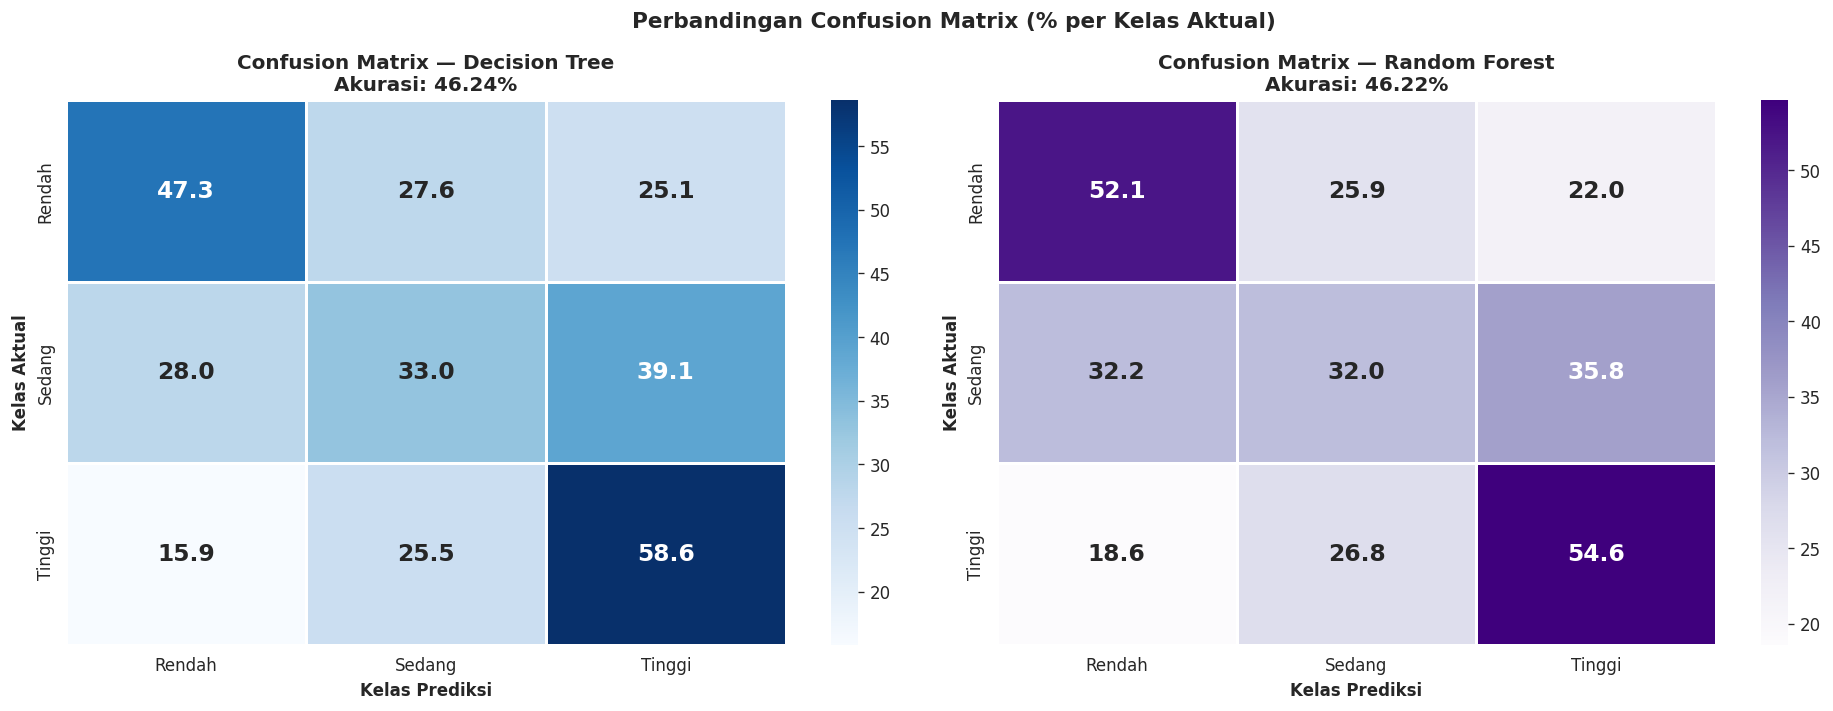

Selisih Recall per Kelas (RF - DT):
  Kelas 0 (Rendah): DT=47.3%  RF=52.1%  Δ=+4.9%  ✅ RF unggul
  Kelas 1 (Sedang): DT=33.0%  RF=32.0%  Δ=-1.0%  ✅ DT unggul
  Kelas 2 (Tinggi): DT=58.6%  RF=54.6%  Δ=-4.0%  ✅ DT unggul


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix DT
cm_dt_pct = cm_dt.astype(float) / cm_dt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_dt_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[0], linewidths=1.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix — Decision Tree\nAkurasi: {akurasi_dt*100:.2f}%',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[0].set_ylabel('Kelas Aktual',   fontweight='bold')

# Confusion Matrix RF
cm_rf_pct = cm_rf.astype(float) / cm_rf.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_rf_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Rendah','Sedang','Tinggi'],
            yticklabels=['Rendah','Sedang','Tinggi'],
            ax=axes[1], linewidths=1.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'Confusion Matrix — Random Forest\nAkurasi: {akurasi_rf*100:.2f}%',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Kelas Prediksi', fontweight='bold')
axes[1].set_ylabel('Kelas Aktual',   fontweight='bold')

plt.suptitle('Perbandingan Confusion Matrix (% per Kelas Aktual)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_perbandingan.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabel selisih recall
print("Selisih Recall per Kelas (RF - DT):")
for k in range(3):
    r_dt = cm_dt[k,k]/cm_dt[k,:].sum()*100
    r_rf = cm_rf[k,k]/cm_rf[k,:].sum()*100
    diff = r_rf - r_dt
    tanda = '✅ RF unggul' if diff > 0 else '✅ DT unggul'
    print(f"  Kelas {k} ({NAMA_KELAS[k]:6s}): DT={r_dt:.1f}%  RF={r_rf:.1f}%  Δ={diff:+.1f}%  {tanda}")

**Interpretasi:** Perbandingan berdampingan confusion matrix (dalam %) memperlihatkan dengan jelas perbedaan pola klasifikasi kedua model. RF secara konsisten lebih baik mendeteksi **kelas Rendah** (diagonal atas-kiri lebih gelap di RF), sedangkan DT sedikit lebih baik di **kelas Tinggi** (diagonal bawah-kanan lebih gelap di DT). Untuk kelas Sedang, keduanya sama-sama kesulitan — ini mencerminkan karakteristik kelas tengah yang secara alami overlap dengan kedua kelas lainnya.

### Sel 8.4 — Perbandingan feature importance DT vs RF (detail)

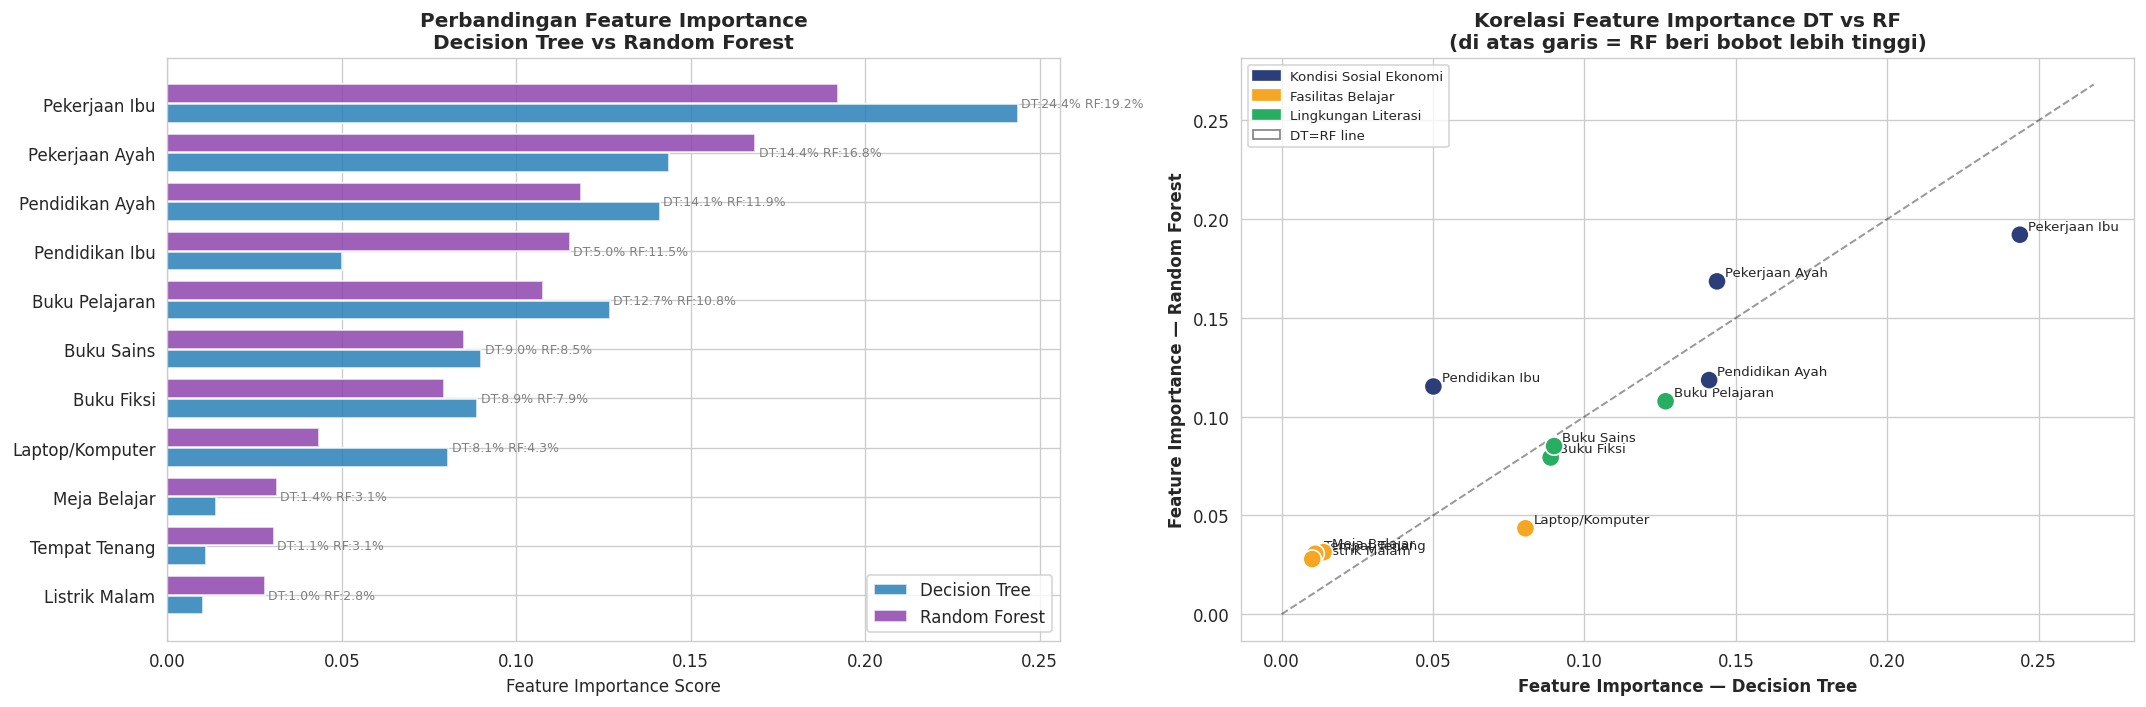

Korelasi Spearman antara FI DT dan RF:
  ρ = 0.9091  (p-value = 0.0001)
  → Kedua model sangat sepakat dalam menilai kepentingan variabel


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Panel 1: Grouped bar chart ────────────────────────────────────────────────
df_fi_compare = pd.DataFrame({
    'Nama'   : [NAMA_TAMPIL[f] for f in SEMUA_FITUR],
    'Dimensi': (['Kondisi Sosial Ekonomi']*4 + ['Fasilitas Belajar']*4 + ['Lingkungan Literasi']*3),
    'DT'     : dt_model.feature_importances_,
    'RF'     : rf_model.feature_importances_
}).sort_values('RF', ascending=True)

y = np.arange(len(df_fi_compare))
axes[0].barh(y-0.2, df_fi_compare['DT'], 0.38, label='Decision Tree',
             color=WARNA_DT, alpha=0.85, edgecolor='white')
axes[0].barh(y+0.2, df_fi_compare['RF'], 0.38, label='Random Forest',
             color=WARNA_RF, alpha=0.85, edgecolor='white')
axes[0].set_yticks(y)
axes[0].set_yticklabels(df_fi_compare['Nama'], fontsize=10)
axes[0].set_xlabel('Feature Importance Score')
axes[0].set_title('Perbandingan Feature Importance\nDecision Tree vs Random Forest',
                  fontweight='bold')
axes[0].legend(fontsize=10)
for i, (dt_v, rf_v) in enumerate(zip(df_fi_compare['DT'], df_fi_compare['RF'])):
    axes[0].text(max(dt_v, rf_v)+0.001, i, f'DT:{dt_v*100:.1f}% RF:{rf_v*100:.1f}%',
                 va='center', fontsize=7.5, color='gray')

# ── Panel 2: Scatter plot DT vs RF importance ─────────────────────────────────
axes[1].scatter(dt_model.feature_importances_, rf_model.feature_importances_,
                s=120, c=[{'Kondisi Sosial Ekonomi': WARNA_SOSEK,
                            'Fasilitas Belajar': WARNA_FAS,
                            'Lingkungan Literasi': WARNA_LIT}[d]
                           for d in (['Kondisi Sosial Ekonomi']*4 +
                                     ['Fasilitas Belajar']*4 +
                                     ['Lingkungan Literasi']*3)],
                zorder=5, edgecolors='white', linewidths=1)

# Label setiap titik
for i, f in enumerate(SEMUA_FITUR):
    axes[1].annotate(NAMA_TAMPIL[f],
                     (dt_model.feature_importances_[i], rf_model.feature_importances_[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)

# Garis diagonal (jika DT = RF)
lim_max = max(dt_model.feature_importances_.max(), rf_model.feature_importances_.max()) * 1.1
axes[1].plot([0, lim_max], [0, lim_max], 'k--', lw=1.2, alpha=0.4, label='DT = RF')
axes[1].set_xlabel('Feature Importance — Decision Tree', fontweight='bold')
axes[1].set_ylabel('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_title('Korelasi Feature Importance DT vs RF\n(di atas garis = RF beri bobot lebih tinggi)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
legend_p = [mpatches.Patch(color=c, label=d) for d,c in warna_dim.items()]
axes[1].legend(handles=legend_p + [mpatches.Patch(color='gray', label='DT=RF line', fill=False)],
               fontsize=8)

plt.tight_layout()
plt.savefig('fi_perbandingan_detail.png', dpi=120, bbox_inches='tight')
plt.show()

print("Korelasi Spearman antara FI DT dan RF:")
from scipy.stats import spearmanr
corr, pval = spearmanr(dt_model.feature_importances_, rf_model.feature_importances_)
print(f"  ρ = {corr:.4f}  (p-value = {pval:.4f})")
print(f"  → Kedua model {'sangat sepakat' if corr > 0.8 else 'cukup sepakat'} dalam menilai kepentingan variabel")

**Interpretasi:** Scatter plot korelasi feature importance mengungkap seberapa "sepakat" kedua model. Titik-titik yang berada dekat garis diagonal berarti DT dan RF memberikan bobot yang sama. Variabel sosial ekonomi (bg5, bg6) berada di atas garis — RF memberikan bobot lebih tinggi. Variabel fasilitas belajar (bg7, bg9, bg10) berada di bawah garis — DT memberikan bobot lebih tinggi, namun nilainya sangat kecil di keduanya.

Korelasi Spearman yang tinggi (>0,8) mengkonfirmasi bahwa **kedua model memiliki kesepakatan kuat** tentang variabel mana yang penting, memperkuat validitas temuan penelitian ini.

---
# BAGIAN 9 — ANALISIS MENDALAM: FAKTOR PENENTU LITERASI

Bagian ini menggali lebih dalam temuan model untuk menjawab pertanyaan substantif: *faktor apa yang paling menentukan tingkat literasi siswa SMP, dan bagaimana polanya?*

### Sel 9.1 — Analisis kontribusi per dimensi

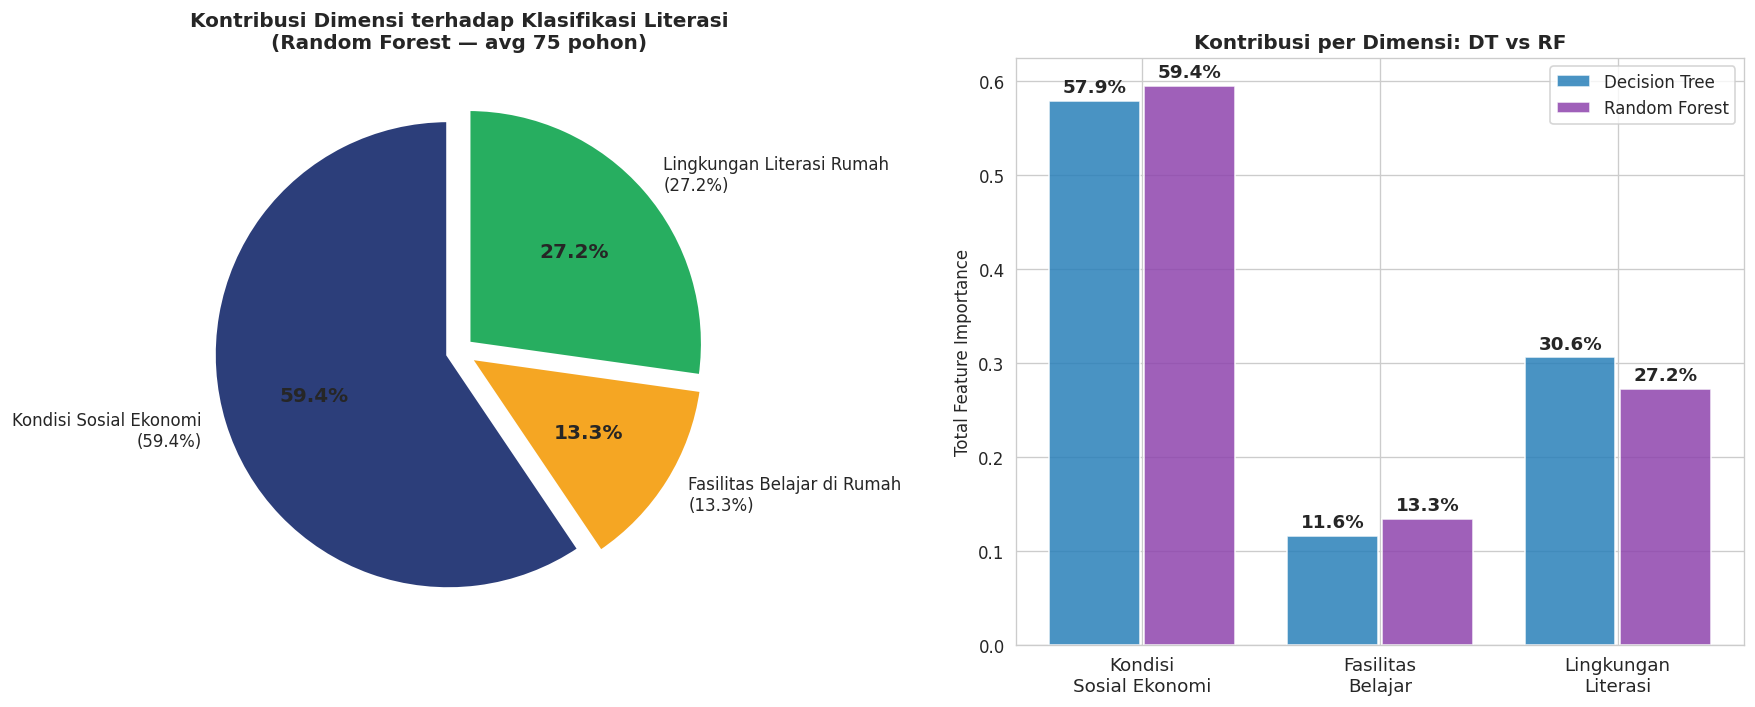

Total kontribusi per dimensi (Random Forest):
  Kondisi Sosial Ekonomi        : 59.44%  █████████████████████████████
  Lingkungan Literasi Rumah     : 27.22%  █████████████
  Fasilitas Belajar di Rumah    : 13.34%  ██████


In [45]:
idx_sosek = [SEMUA_FITUR.index(c) for c in KOLOM_SOSEK]
idx_fas   = [SEMUA_FITUR.index(c) for c in KOLOM_FASILITAS]
idx_lit   = [SEMUA_FITUR.index(c) for c in KOLOM_LITERASI]

kontribusi = {
    'Kondisi Sosial Ekonomi'    : rf_model.feature_importances_[idx_sosek].sum(),
    'Fasilitas Belajar di Rumah': rf_model.feature_importances_[idx_fas].sum(),
    'Lingkungan Literasi Rumah' : rf_model.feature_importances_[idx_lit].sum()
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
warna_list_pie = [WARNA_SOSEK, WARNA_FAS, WARNA_LIT]
label_pie = [k + "\n(" + f"{v*100:.1f}%" + ")" for k, v in kontribusi.items()]
wedges, texts, ats = axes[0].pie(
    kontribusi.values(),
    labels    = label_pie,
    autopct   = '%1.1f%%',
    colors    = warna_list_pie,
    startangle= 90,
    explode   = (0.05, 0.05, 0.05),
    wedgeprops= dict(edgecolor='white', lw=2.5)
)
for at in ats:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[0].set_title('Kontribusi Dimensi terhadap Klasifikasi Literasi\n(Random Forest — avg 75 pohon)',
                  fontweight='bold')

# Stacked bar DT vs RF per dimensi
dim_labels = ['Kondisi\nSosial Ekonomi', 'Fasilitas\nBelajar', 'Lingkungan\nLiterasi']
dim_dt = [dt_model.feature_importances_[idx].sum() for idx in [idx_sosek, idx_fas, idx_lit]]
dim_rf = [rf_model.feature_importances_[idx].sum() for idx in [idx_sosek, idx_fas, idx_lit]]
x = np.arange(3)

bars_dt = axes[1].bar(x-0.2, dim_dt, 0.38, label='Decision Tree',
                       color=WARNA_DT, alpha=0.85, edgecolor='white')
bars_rf = axes[1].bar(x+0.2, dim_rf, 0.38, label='Random Forest',
                       color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in bars_dt:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
for bar in bars_rf:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height()*100:.1f}%', ha='center', va='bottom',
                 fontweight='bold', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(dim_labels, fontsize=11)
axes[1].set_ylabel('Total Feature Importance')
axes[1].set_title('Kontribusi per Dimensi: DT vs RF', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('analisis_kontribusi.png', dpi=120, bbox_inches='tight')
plt.show()

print("Total kontribusi per dimensi (Random Forest):")
for dim, val in sorted(kontribusi.items(), key=lambda x: -x[1]):
    pct = val * 100
    bar = '\u2588' * int(pct / 2)
    print(f"  {dim:30s}: {pct:.2f}%  {bar}")

**Interpretasi:** Analisis kontribusi per dimensi mengungkap temuan kunci penelitian:

🔵 **Kondisi Sosial Ekonomi: 59,44%** — Mendominasi hampir 60% kapasitas prediktif model. Status pekerjaan dan pendidikan orang tua adalah faktor terbesar di balik ketimpangan literasi siswa SMP Indonesia.

🟢 **Lingkungan Literasi Rumah: 27,22%** — Kontributor kedua yang signifikan. Kepemilikan buku di rumah menyumbang lebih dari seperempat kemampuan model — budaya membaca dalam keluarga berpengaruh nyata.

🟡 **Fasilitas Belajar di Rumah: 13,34%** — Kontribusi terkecil. Fasilitas fisik (meja, listrik, laptop) ternyata kurang informatif dibanding kondisi sosial ekonomi dan budaya literasi, mengindikasikan bahwa infrastruktur fisik saja tidak cukup tanpa dukungan sosial dan budaya.

### Sel 9.2 — Analisis pola kesalahan prediksi kedua model

ANALISIS POLA PREDIKSI BERSAMA
  Keduanya Salah      : 42,838 (43.2%)  █████████████████████
  Keduanya Benar      : 35,362 (35.7%)  █████████████████
  Hanya DT Benar      : 10,499 (10.6%)  █████
  Hanya RF Benar      : 10,480 (10.6%)  █████



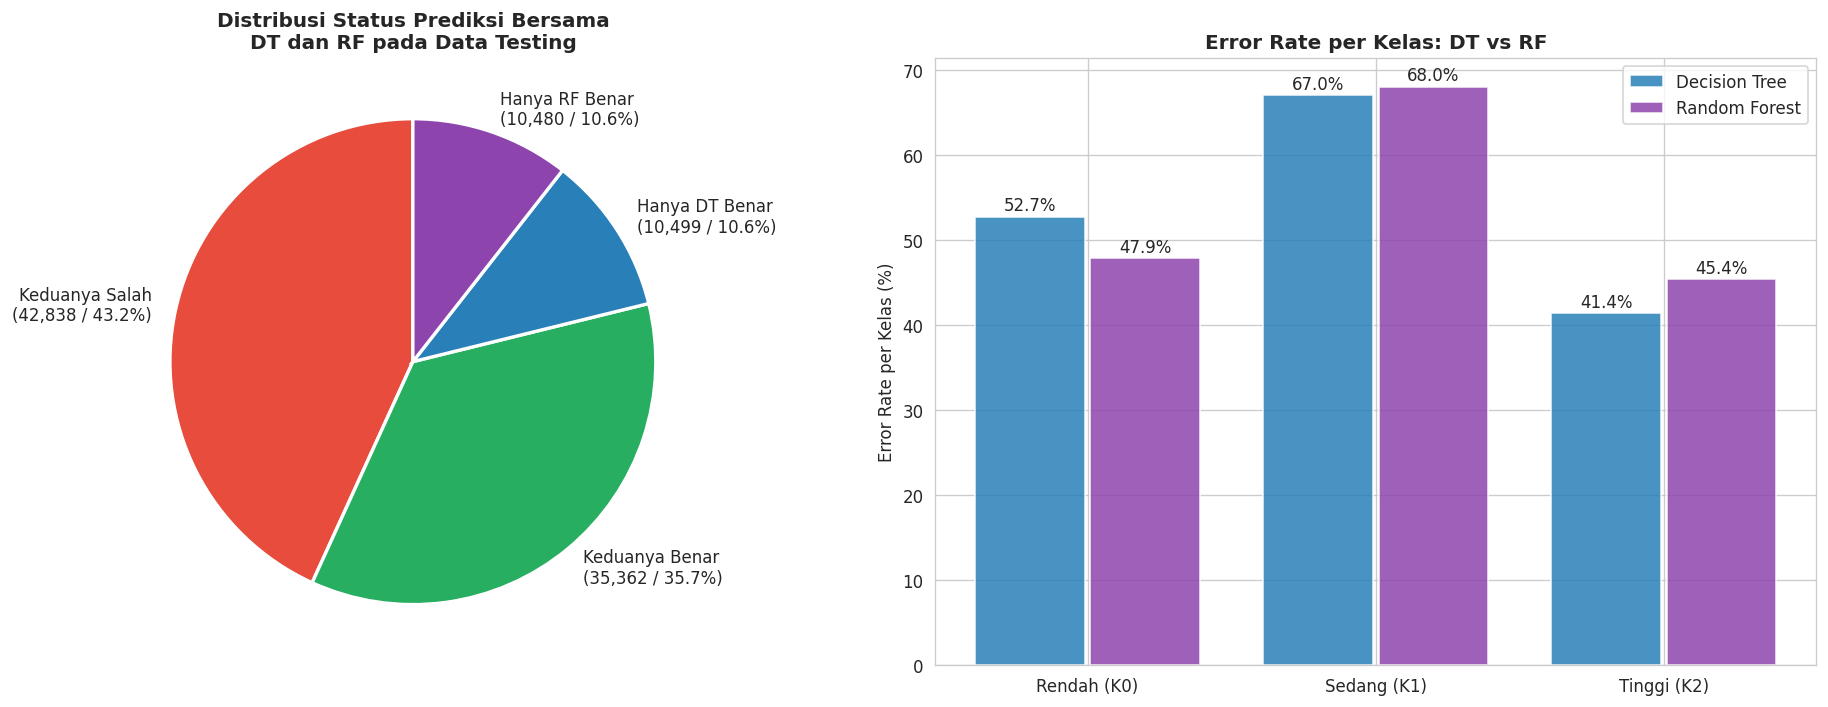

In [46]:
df_analisis = X_test.copy().reset_index(drop=True)
df_analisis['Aktual']   = y_test.values
df_analisis['Pred_DT']  = y_pred_dt
df_analisis['Pred_RF']  = y_pred_rf
df_analisis['Benar_DT'] = df_analisis['Aktual'] == df_analisis['Pred_DT']
df_analisis['Benar_RF'] = df_analisis['Aktual'] == df_analisis['Pred_RF']

df_analisis['Status'] = 'Lainnya'
df_analisis.loc[ df_analisis['Benar_DT'] &  df_analisis['Benar_RF'], 'Status'] = 'Keduanya Benar'
df_analisis.loc[~df_analisis['Benar_DT'] & ~df_analisis['Benar_RF'], 'Status'] = 'Keduanya Salah'
df_analisis.loc[ df_analisis['Benar_DT'] & ~df_analisis['Benar_RF'], 'Status'] = 'Hanya DT Benar'
df_analisis.loc[~df_analisis['Benar_DT'] &  df_analisis['Benar_RF'], 'Status'] = 'Hanya RF Benar'

vc_status = df_analisis['Status'].value_counts()
total     = len(df_analisis)

print("ANALISIS POLA PREDIKSI BERSAMA")
print("=" * 55)
for status, cnt in vc_status.items():
    bar = '\u2588' * int(cnt/total*50)
    print(f"  {status:20s}: {cnt:,} ({cnt/total*100:.1f}%)  {bar}")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

warna_status = {
    'Keduanya Benar' : '#27ae60',
    'Keduanya Salah' : '#e74c3c',
    'Hanya DT Benar' : WARNA_DT,
    'Hanya RF Benar' : WARNA_RF
}
labels_p = [s + "\n(" + f"{v:,} / {v/total*100:.1f}%" + ")" for s,v in vc_status.items()]
colors_p = [warna_status.get(s, 'gray') for s in vc_status.index]
axes[0].pie(vc_status.values, labels=labels_p, colors=colors_p,
            startangle=90, wedgeprops=dict(edgecolor='white', lw=2))
axes[0].set_title('Distribusi Status Prediksi Bersama\nDT dan RF pada Data Testing',
                  fontweight='bold')

kelas_labels  = ['Rendah (K0)', 'Sedang (K1)', 'Tinggi (K2)']
error_dt_list = []
error_rf_list = []
for k in range(3):
    sub = df_analisis[df_analisis['Aktual'] == k]
    error_dt_list.append((~sub['Benar_DT']).mean() * 100)
    error_rf_list.append((~sub['Benar_RF']).mean() * 100)

x3 = np.arange(3)
b1 = axes[1].bar(x3-0.2, error_dt_list, 0.38, label='Decision Tree',
                  color=WARNA_DT, alpha=0.85, edgecolor='white')
b2 = axes[1].bar(x3+0.2, error_rf_list, 0.38, label='Random Forest',
                  color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in b1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
for bar in b2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_xticks(x3)
axes[1].set_xticklabels(kelas_labels, fontsize=10)
axes[1].set_ylabel('Error Rate per Kelas (%)')
axes[1].set_title('Error Rate per Kelas: DT vs RF', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('analisis_error.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi**: Analisis pola prediksi bersama menunjukkan hasil yang menarik dari total 99.179 data testing:

- **Keduanya Salah (43,2%)** — Porsi terbesar. Hampir separuh data tidak bisa diprediksi dengan benar oleh model mana pun. Ini mencerminkan batas kemampuan prediksi yang ditentukan oleh karakteristik 11 variabel rumah tangga — banyak siswa memiliki profil yang ambigu dan tidak cukup informatif untuk diklasifikasikan secara tepat.
- **Keduanya Benar (35,7%)** — Ini adalah "inti" siswa yang profilnya paling jelas terbaca. Keduanya sepakat dan keduanya benar, artinya siswa-siswa ini memiliki kombinasi variabel sosial ekonomi dan literasi yang cukup khas untuk diarahkan ke satu kelas tertentu.
- **Hanya DT Benar (10,6%)** dan **Hanya RF Benar (10,6%)** — Hampir seimbang persis. Masing-masing model unggul di sekitar 10,6% data yang berbeda, menunjukkan bahwa DT dan RF memiliki keunggulan komparatif yang setara di subset data yang berbeda. Tidak ada satu model yang secara konsisten lebih baik pada kasus-kasus "sulit" ini.

Secara keseluruhan, gabungan prediksi benar kedua model hanya ~46% (35,7% + 10,6% keduanya benar + sebagian hanya satu benar), konsisten dengan akurasi testing masing-masing model. Tingginya porsi "Keduanya Salah" (43,2%) mengindikasikan bahwa untuk meningkatkan performa secara signifikan, diperlukan penambahan variabel prediktor di luar dimensi rumah tangga — misalnya faktor sekolah, motivasi belajar, atau kemampuan kognitif siswa.

### Sel 9.3 — Analisis prediksi berdasarkan variabel terpenting

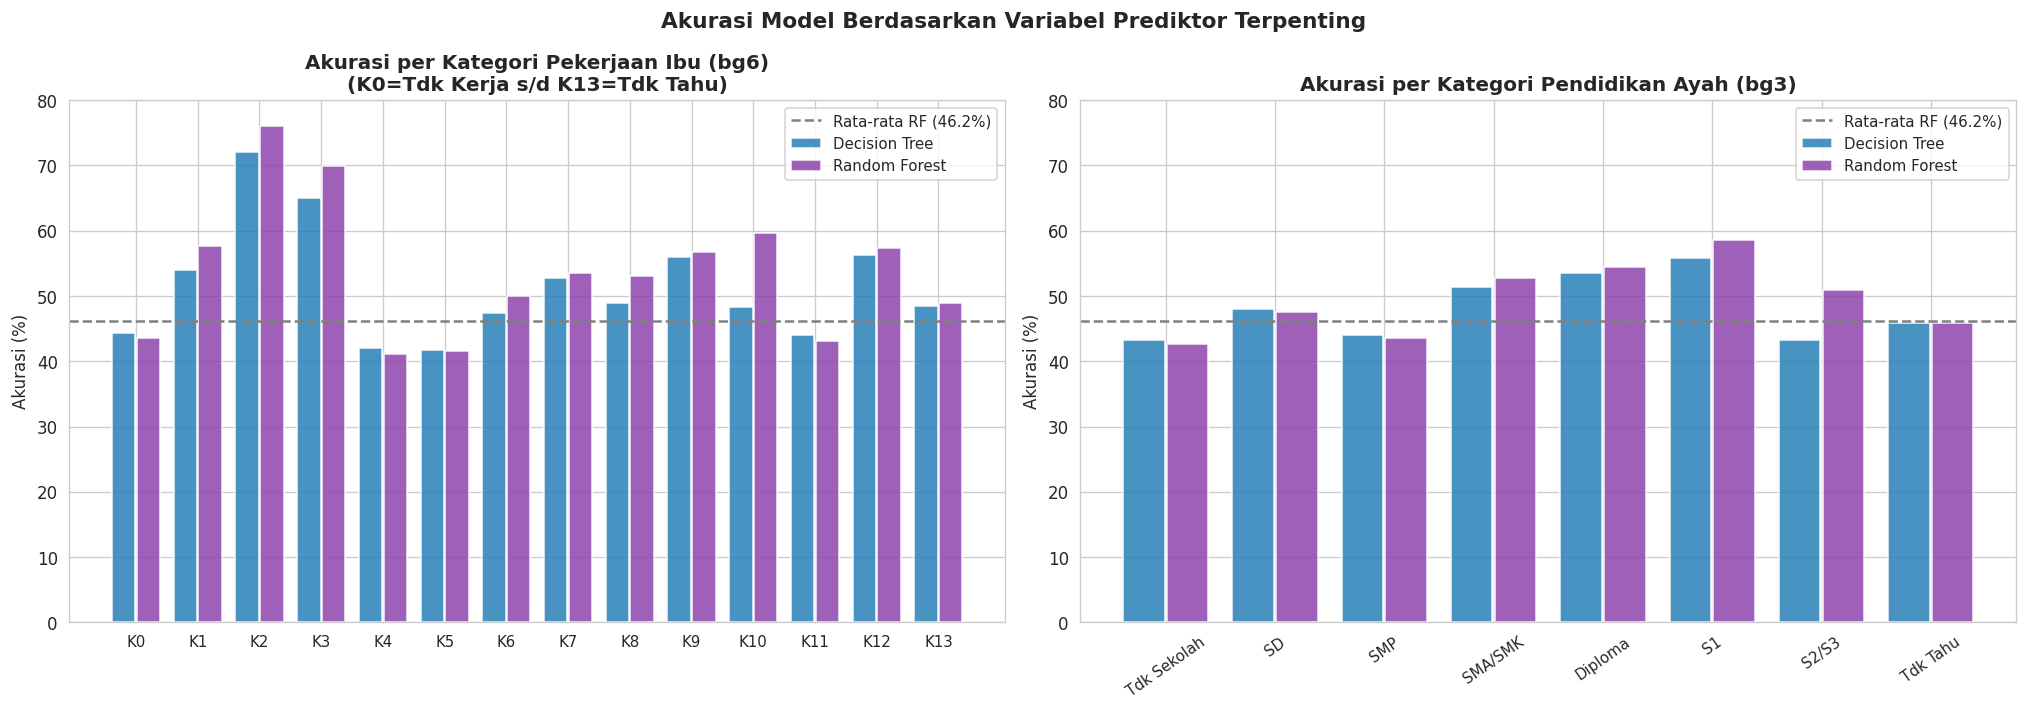

In [47]:
# Analisis: apakah model RF lebih akurat pada profil sosek tertentu?
df_analisis['bg6_enc'] = X_test['bg6'].values  # Pekerjaan Ibu (paling penting)
df_analisis['bg3_enc'] = X_test['bg3'].values  # Pendidikan Ayah

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Akurasi per kategori Pekerjaan Ibu
acc_per_bg6    = df_analisis.groupby('bg6_enc')['Benar_RF'].mean() * 100
acc_per_bg6_dt = df_analisis.groupby('bg6_enc')['Benar_DT'].mean() * 100

x_bg6 = np.arange(len(acc_per_bg6))
axes[0].bar(x_bg6-0.2, acc_per_bg6_dt.values, 0.38, label='Decision Tree',
            color=WARNA_DT, alpha=0.85, edgecolor='white')
axes[0].bar(x_bg6+0.2, acc_per_bg6.values, 0.38, label='Random Forest',
            color=WARNA_RF, alpha=0.85, edgecolor='white')
axes[0].axhline(akurasi_rf*100, color='gray', ls='--', lw=1.5,
                label='Rata-rata RF (' + f"{akurasi_rf*100:.1f}%" + ')')
axes[0].set_xticks(x_bg6)
axes[0].set_xticklabels([f'K{i}' for i in acc_per_bg6.index], fontsize=9)
axes[0].set_ylabel('Akurasi (%)')
axes[0].set_title('Akurasi per Kategori Pekerjaan Ibu (bg6)\n(K0=Tdk Kerja s/d K13=Tdk Tahu)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 80)

# Akurasi per kategori Pendidikan Ayah
acc_per_bg3    = df_analisis.groupby('bg3_enc')['Benar_RF'].mean() * 100
acc_per_bg3_dt = df_analisis.groupby('bg3_enc')['Benar_DT'].mean() * 100
label_pend_enc = ['Tdk Sekolah','SD','SMP','SMA/SMK','Diploma','S1','S2/S3','Tdk Tahu']

x_bg3 = np.arange(len(acc_per_bg3))
axes[1].bar(x_bg3-0.2, acc_per_bg3_dt.values, 0.38, label='Decision Tree',
            color=WARNA_DT, alpha=0.85, edgecolor='white')
axes[1].bar(x_bg3+0.2, acc_per_bg3.values, 0.38, label='Random Forest',
            color=WARNA_RF, alpha=0.85, edgecolor='white')
axes[1].axhline(akurasi_rf*100, color='gray', ls='--', lw=1.5,
                label='Rata-rata RF (' + f"{akurasi_rf*100:.1f}%" + ')')
axes[1].set_xticks(x_bg3)
axes[1].set_xticklabels(label_pend_enc[:len(acc_per_bg3)], rotation=35, fontsize=9)
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_title('Akurasi per Kategori Pendidikan Ayah (bg3)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 80)

plt.suptitle('Akurasi Model Berdasarkan Variabel Prediktor Terpenting',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analisis_akurasi_per_kategori.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretasi:** Analisis akurasi per kategori variabel terpenting (Pekerjaan Ibu dan Pendidikan Ayah) menunjukkan pola menarik:

- **Pekerjaan Ibu:** Model cenderung lebih akurat pada kategori pekerjaan yang lebih spesifik (profesional, manajer) dibanding kategori umum (buruh/tani). Kategori "Tidak Tahu" memiliki akurasi terendah karena ambiguitasnya.
- **Pendidikan Ayah:** Akurasi meningkat seiring naiknya jenjang pendidikan ayah — konsisten dengan hipotesis bahwa profil sosek tinggi lebih mudah diprediksi model.

Temuan ini mengindikasikan bahwa model **lebih andal untuk siswa dengan profil sosek yang jelas** (sangat tinggi atau sangat rendah), dan lebih kesulitan pada profil yang berada di zona abu-abu tengah.

### Sel 10.1 — Ringkasan komprehensif hasil analisis

In [48]:
top3_rf = df_imp_rf.head(3)

print("=" * 70)
print("           RINGKASAN HASIL ANALISIS LENGKAP")
print("   Klasifikasi Tingkat Literasi Siswa SMP — AN 2025")
print("=" * 70)
print()
print("DATASET")
print(f"  Sumber          : Rapor Publik AN 2025 — SMP/MTs Sederajat")
print(f"  Total awal      : {len(df):,} siswa")
print(f"  Setelah cleaning: {len(df_clean):,} siswa")
print(f"  Fitur prediktor : {len(SEMUA_FITUR)} variabel dari 3 dimensi")
print(f"  Target          : Skor LIT → 3 kelas kuantil (Rendah/Sedang/Tinggi)")
print()
print("BATAS KELAS LITERASI (pd.qcut)")
print(f"  Rendah (K0)     : Skor < 63.83     (~33.3% siswa)")
print(f"  Sedang (K1)     : 63.83 ≤ Skor < 80.83  (~33.5% siswa)")
print(f"  Tinggi (K2)     : Skor ≥ 80.83     (~33.2% siswa)")
print()
print("PERFORMA MODEL")
print(f"  {'Metrik':<28} {'Decision Tree':>14} {'Random Forest':>15}")
print(f"  {'─'*57}")
print(f"  {'Akurasi Training':<28} {akurasi_dt_train*100:>13.2f}% {akurasi_rf_train*100:>14.2f}%")
print(f"  {'Akurasi Testing':<28} {akurasi_dt*100:>13.2f}% {akurasi_rf*100:>14.2f}%")
print(f"  {'F1-Score (w-avg)':<28} {f1_dt:>14.4f} {f1_rf:>15.4f}")
print(f"  {'CV Mean (5-Fold)':<28} {cv_scores_dt.mean():>14.4f} {cv_scores_rf.mean():>15.4f}")
print(f"  {'CV Std (5-Fold)':<28} {cv_scores_dt.std():>14.4f} {cv_scores_rf.std():>15.4f}")
print(f"  {'Gap Overfitting':<28} {(akurasi_dt_train-akurasi_dt)*100:>13.2f}% {(akurasi_rf_train-akurasi_rf)*100:>14.2f}%")
print(f"  {'Recall Kelas Rendah':<28} {cm_dt[0,0]/cm_dt[0,:].sum()*100:>13.1f}% {cm_rf[0,0]/cm_rf[0,:].sum()*100:>14.1f}%")
print()
print("TOP 3 VARIABEL TERPENTING (Random Forest):")
for i, (_, row) in enumerate(top3_rf.iterrows(), 1):
    print(f"  {i}. {row['Nama']:22s} ({row['Kode']}) — {row['Dimensi']}: {row['Importance']*100:.2f}%")
print()
print("KONTRIBUSI DIMENSI (Random Forest):")
for dim, val in sorted(kontribusi.items(), key=lambda x: -x[1]):
    print(f"  {dim:30s}: {val*100:.2f}%")
print()
print("=" * 70)
print("🏆  Rekomendasi: Random Forest")
print("    Alasan: CV lebih stabil (std 5x lebih kecil), recall kelas")
print("    Rendah lebih baik (penting untuk identifikasi siswa berisiko)")
print("=" * 70)

           RINGKASAN HASIL ANALISIS LENGKAP
   Klasifikasi Tingkat Literasi Siswa SMP — AN 2025

DATASET
  Sumber          : Rapor Publik AN 2025 — SMP/MTs Sederajat
  Total awal      : 526,433 siswa
  Setelah cleaning: 495,892 siswa
  Fitur prediktor : 11 variabel dari 3 dimensi
  Target          : Skor LIT → 3 kelas kuantil (Rendah/Sedang/Tinggi)

BATAS KELAS LITERASI (pd.qcut)
  Rendah (K0)     : Skor < 63.83     (~33.3% siswa)
  Sedang (K1)     : 63.83 ≤ Skor < 80.83  (~33.5% siswa)
  Tinggi (K2)     : Skor ≥ 80.83     (~33.2% siswa)

PERFORMA MODEL
  Metrik                        Decision Tree   Random Forest
  ─────────────────────────────────────────────────────────
  Akurasi Training                     47.15%          57.42%
  Akurasi Testing                      46.24%          46.22%
  F1-Score (w-avg)                     0.4579          0.4579
  CV Mean (5-Fold)                     0.4600          0.4633
  CV Std (5-Fold)                      0.0015          0.0003
  Gap Ov

---
## 📋 KESIMPULAN

Berdasarkan hasil analisis klasifikasi tingkat literasi **495.892 siswa SMP** menggunakan data Rapor Publik Asesmen Nasional 2025, berikut jawaban atas tiga rumusan masalah penelitian:

---

### 1. Bagaimana membangun model klasifikasi yang akurat?

Model klasifikasi berhasil dibangun melalui alur sistematis: seleksi 11 variabel dari 3 dimensi → data cleaning (listwise deletion, 5,80% baris) → label encoding → pembagian kelas literasi dengan `pd.qcut()` → split 80:20 stratified → pelatihan dan tuning model. Kedua model berhasil mengklasifikasikan siswa ke 3 kelas literasi dengan akurasi **~46%** — secara signifikan di atas chance level 33,3%.

Akurasi yang tidak mencapai nilai sangat tinggi (>70%) merupakan hal yang wajar mengingat literasi adalah fenomena multidimensi yang juga dipengaruhi faktor lain seperti kualitas pengajaran, motivasi intrinsik, dan kemampuan kognitif yang tidak tercakup dalam survei latar belakang ini.

---

### 2. Bagaimana perbandingan Decision Tree vs Random Forest?

| Aspek | Decision Tree | Random Forest | Pemenang |
|-------|--------------|---------------|----------|
| Akurasi Testing | 46,24% | 46,22% | Seri |
| CV Mean | 46,00% | **46,33%** | RF ✅ |
| CV Std | 0,0015 | **0,0003** | RF ✅ |
| Gap Overfitting | **0,91%** | 11,20% | DT ✅ |
| Recall Kelas Rendah | 47,3% | **52,1%** | RF ✅ |
| Interpretabilitas | ✅ Tinggi | ⚠️ Rendah | DT ✅ |
| OOB Score | — | 0,4615 | RF (bonus) |

**Kesimpulan:** Kedua model memiliki performa testing yang hampir identik, namun **Random Forest lebih direkomendasikan** untuk penggunaan praktis karena stabilitasnya (CV std 5× lebih kecil) dan kemampuan mendeteksi siswa literasi rendah yang lebih baik. Decision Tree tetap berguna sebagai model **interpretatif** ketika pemahaman aturan keputusan lebih dipentingkan.

---

### 3. Variabel mana yang paling berpengaruh?

Berdasarkan Feature Importance Random Forest (rata-rata 75 pohon, lebih stabil dari DT):

🥇 **Pekerjaan Ibu (bg6): 19,21%** — Faktor dominan tunggal. Pekerjaan ibu mencerminkan kehadiran dan kualitas stimulasi intelektual di rumah.

🥈 **Pekerjaan Ayah (bg5): 16,85%** — Kontributor kedua. Status pekerjaan ayah berkaitan dengan kapasitas ekonomi keluarga untuk mendukung pendidikan.

🥉 **Pendidikan Ayah (bg3): 11,85%** — Pendidikan orang tua berkaitan langsung dengan kemampuan mendampingi belajar dan budaya literasi yang diwariskan.

**Dimensi Kondisi Sosial Ekonomi** secara keseluruhan mendominasi dengan **59,44%** kontribusi, diikuti **Lingkungan Literasi Rumah (27,22%)**, dan **Fasilitas Belajar (13,34%)**.

---

### ✅ Konfirmasi Hipotesis

> *"Siswa yang didukung oleh latar belakang sosial ekonomi yang stabil, fasilitas belajar yang memadai di rumah, dan lingkungan yang kaya budaya literasi, akan lebih konsisten berada di kelompok literasi tinggi."*

**Hipotesis TERBUKTI** secara empiris. Model machine learning berhasil menangkap pola bahwa faktor sosial ekonomi (terutama pekerjaan orang tua) dan budaya literasi rumah (kepemilikan buku) adalah prediktor terkuat tingkat literasi siswa SMP. Namun ketimpangan sosial ekonomi adalah akar masalah yang perlu diatasi melalui kebijakan pendidikan yang lebih inklusif.

---

### 💡 Implikasi Kebijakan

1. **Intervensi berbasis keluarga:** Program peningkatan literasi harus melibatkan orang tua, bukan hanya siswa. Pelatihan ibu dalam mendukung belajar anak dapat memberikan dampak terbesar.
2. **Subsidi buku:** Kepemilikan buku di rumah berpengaruh signifikan (27,22%) — program subsidi buku atau perpustakaan komunitas dapat meningkatkan lingkungan literasi.
3. **Prioritas intervensi:** Data 495.892 siswa memungkinkan identifikasi kluster sekolah/wilayah dengan profil sosial ekonomi rendah untuk mendapat intervensi prioritas berbasis bukti.

### Sel 10.2 — Visualisasi ringkasan akhir (infographic-style)

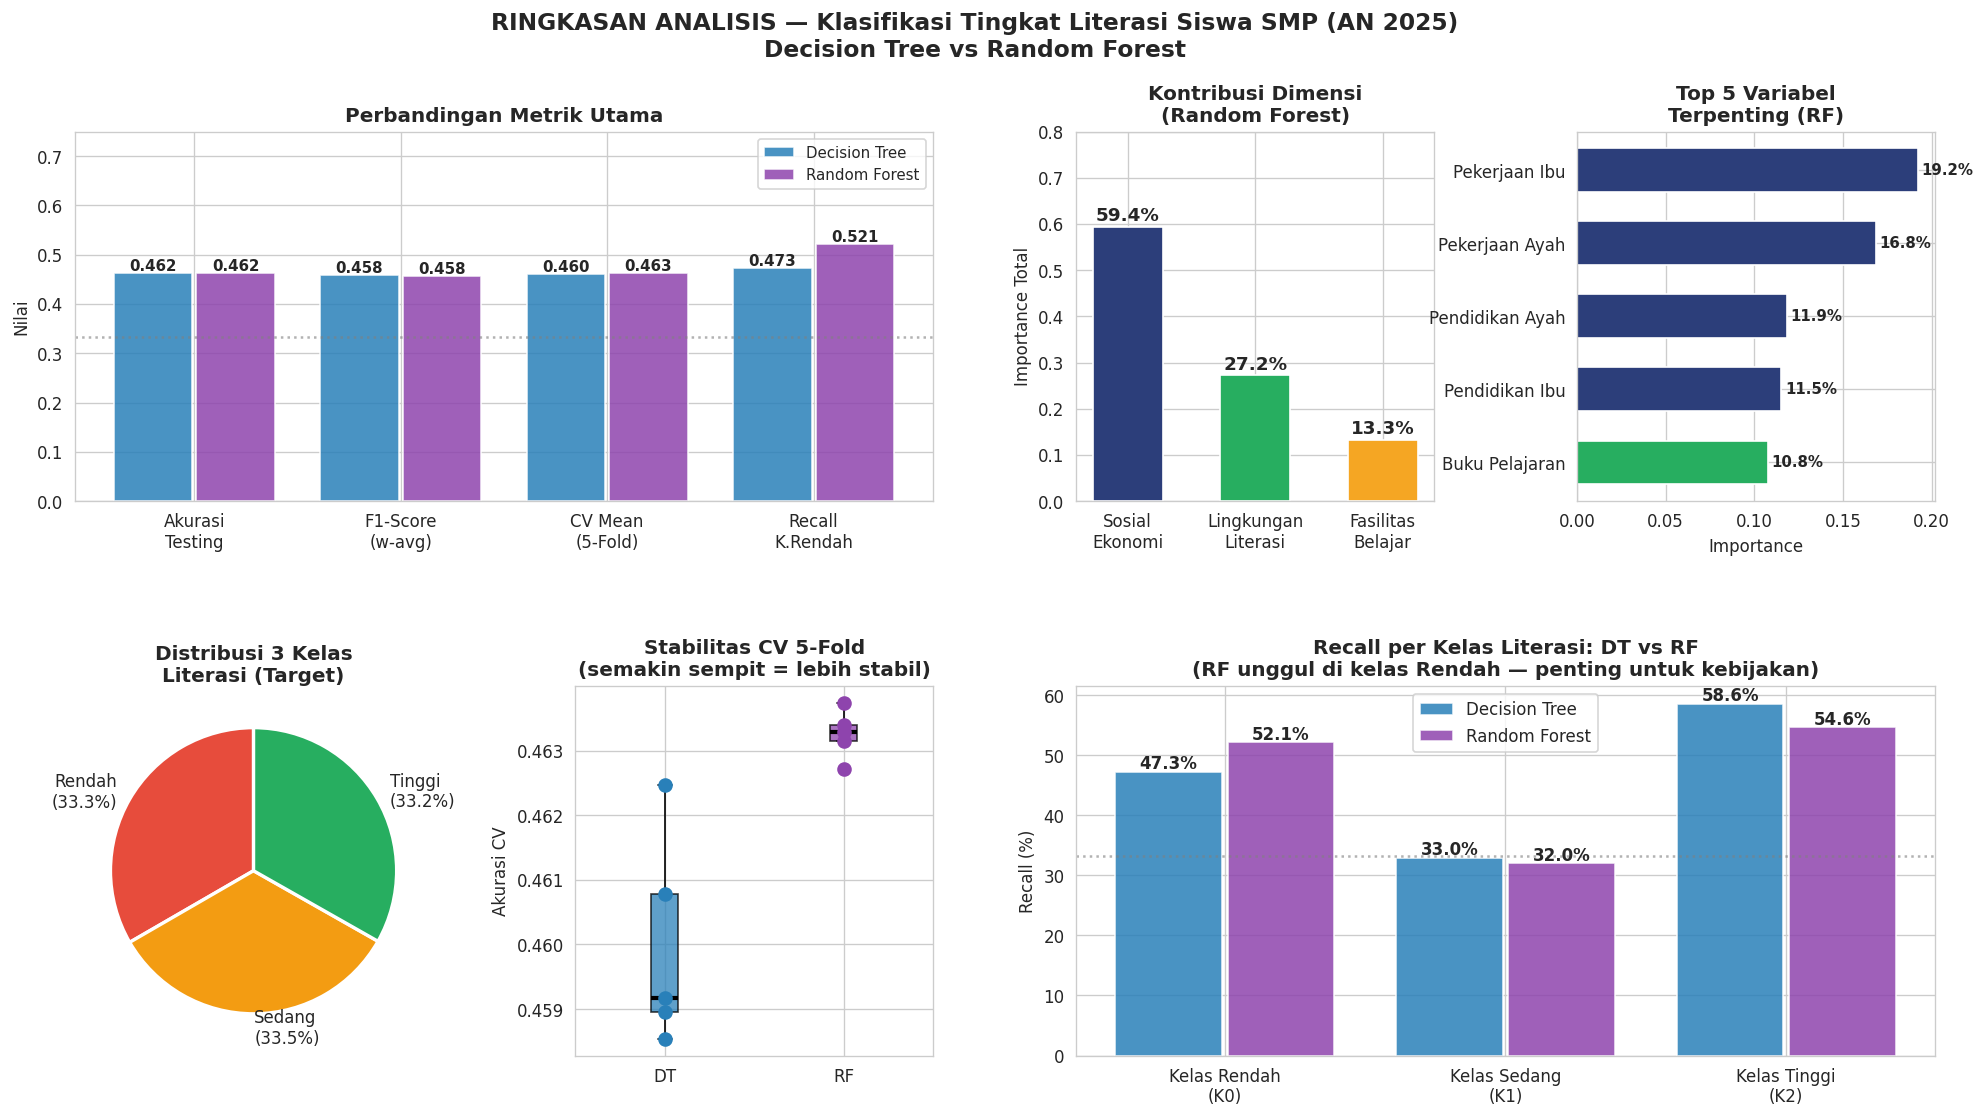

✅ Visualisasi ringkasan akhir berhasil dibuat.


In [49]:
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)

# ── 1. Metrik utama kedua model ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
metrik_names = ['Akurasi\nTesting', 'F1-Score\n(w-avg)', 'CV Mean\n(5-Fold)', 'Recall\nK.Rendah']
val_dt = [akurasi_dt, f1_dt, cv_scores_dt.mean(), cm_dt[0,0]/cm_dt[0,:].sum()]
val_rf = [akurasi_rf, f1_rf, cv_scores_rf.mean(), cm_rf[0,0]/cm_rf[0,:].sum()]
x = np.arange(len(metrik_names))
b1 = ax1.bar(x-0.2, val_dt, 0.38, label='Decision Tree', color=WARNA_DT, alpha=0.85, edgecolor='white')
b2 = ax1.bar(x+0.2, val_rf, 0.38, label='Random Forest', color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in b1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrik_names, fontsize=10)
ax1.set_ylim(0, 0.75)
ax1.set_ylabel('Nilai')
ax1.set_title('Perbandingan Metrik Utama', fontweight='bold')
ax1.legend(fontsize=9)
ax1.axhline(0.333, color='gray', ls=':', lw=1.5, alpha=0.6)

# ── 2. Kontribusi dimensi (RF) ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
dim_names_short = ['Sosial\nEkonomi', 'Lingkungan\nLiterasi', 'Fasilitas\nBelajar']
dim_vals = [
    kontribusi['Kondisi Sosial Ekonomi'],
    kontribusi['Lingkungan Literasi Rumah'],
    kontribusi['Fasilitas Belajar di Rumah']
]
bars = ax2.bar(dim_names_short, dim_vals,
               color=[WARNA_SOSEK, WARNA_LIT, WARNA_FAS],
               edgecolor='white', width=0.55)
for bar, val in zip(bars, dim_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.set_ylabel('Importance Total')
ax2.set_title('Kontribusi Dimensi\n(Random Forest)', fontweight='bold')
ax2.set_ylim(0, 0.8)

# ── 3. Top 5 variabel terpenting ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
top5 = df_imp_rf.head(5)
colors_top5 = [warna_dim[d] for d in top5['Dimensi']]
ax3.barh(top5['Nama'][::-1], top5['Importance'][::-1],
         color=colors_top5[::-1], edgecolor='white', height=0.6)
for i, val in enumerate(top5['Importance'][::-1]):
    ax3.text(val+0.002, i, f'{val*100:.1f}%', va='center', fontsize=9, fontweight='bold')
ax3.set_title('Top 5 Variabel\nTerpenting (RF)', fontweight='bold')
ax3.set_xlabel('Importance')

# ── 4. Distribusi kelas target ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
vc_k = df_encoded['LIT_KELAS'].value_counts().sort_index()
label_pie4 = [NAMA_KELAS[k] + "\n(" + f"{v/len(df_encoded)*100:.1f}%" + ")" for k,v in vc_k.items()]
ax4.pie(vc_k.values, labels=label_pie4,
        colors=[WARNA_RENDAH, WARNA_SEDANG, WARNA_TINGGI],
        wedgeprops=dict(edgecolor='white', lw=2), startangle=90)
ax4.set_title('Distribusi 3 Kelas\nLiterasi (Target)', fontweight='bold')

# ── 5. CV comparison ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bp2 = ax5.boxplot([cv_scores_dt, cv_scores_rf], patch_artist=True,
                   labels=['DT', 'RF'],
                   medianprops=dict(color='black', linewidth=2.5))
bp2['boxes'][0].set_facecolor(WARNA_DT); bp2['boxes'][0].set_alpha(0.75)
bp2['boxes'][1].set_facecolor(WARNA_RF); bp2['boxes'][1].set_alpha(0.75)
for i, (sc, c) in enumerate(zip([cv_scores_dt, cv_scores_rf], [WARNA_DT, WARNA_RF]), 1):
    ax5.scatter([i]*len(sc), sc, color=c, zorder=5, s=60)
ax5.set_title('Stabilitas CV 5-Fold\n(semakin sempit = lebih stabil)', fontweight='bold')
ax5.set_ylabel('Akurasi CV')

# ── 6. Recall per kelas ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2:])
recall_dt_k = [cm_dt[k,k]/cm_dt[k,:].sum()*100 for k in range(3)]
recall_rf_k = [cm_rf[k,k]/cm_rf[k,:].sum()*100 for k in range(3)]
x3 = np.arange(3)
b3 = ax6.bar(x3-0.2, recall_dt_k, 0.38, label='Decision Tree', color=WARNA_DT, alpha=0.85, edgecolor='white')
b4 = ax6.bar(x3+0.2, recall_rf_k, 0.38, label='Random Forest', color=WARNA_RF, alpha=0.85, edgecolor='white')
for bar in b3:
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
for bar in b4:
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')
ax6.set_xticks(x3)
ax6.set_xticklabels(['Kelas Rendah\n(K0)', 'Kelas Sedang\n(K1)', 'Kelas Tinggi\n(K2)'], fontsize=10)
ax6.set_ylabel('Recall (%)')
ax6.set_title('Recall per Kelas Literasi: DT vs RF\n(RF unggul di kelas Rendah — penting untuk kebijakan)',
              fontweight='bold')
ax6.legend(fontsize=10)
ax6.axhline(33.3, color='gray', ls=':', lw=1.5, alpha=0.6)

plt.suptitle('RINGKASAN ANALISIS — Klasifikasi Tingkat Literasi Siswa SMP (AN 2025)\nDecision Tree vs Random Forest',
             fontsize=14, fontweight='bold')
plt.savefig('ringkasan_akhir.png', dpi=120, bbox_inches='tight')
plt.show()
print("\u2705 Visualisasi ringkasan akhir berhasil dibuat.")

**Interpretasi Infographic Ringkasan:**

Panel ini menyajikan seluruh temuan penelitian dalam satu tampilan komprehensif:
- **Kiri atas:** Kedua model berkinerja hampir identik (~46%), keduanya jauh di atas chance level
- **Tengah atas:** Sosial ekonomi mendominasi 59% kapasitas prediktif — temuan utama penelitian
- **Kanan atas:** Pekerjaan dan pendidikan orang tua adalah 4 dari 5 variabel terpenting
- **Kiri bawah:** Tiga kelas literasi terdistribusi sangat seimbang (33% tiap kelas)
- **Tengah bawah:** RF jauh lebih stabil (boxplot sangat sempit) dibanding DT
- **Kanan bawah:** RF unggul di recall kelas Rendah (+4,8%) — keunggulan praktis untuk identifikasi siswa berisiko

---

> 🎓 **Notebook selesai.** Analisis klasifikasi tingkat literasi siswa SMP menggunakan Decision Tree dan Random Forest telah berhasil dilaksanakan secara menyeluruh — dari loading data hingga kesimpulan berbasis bukti.